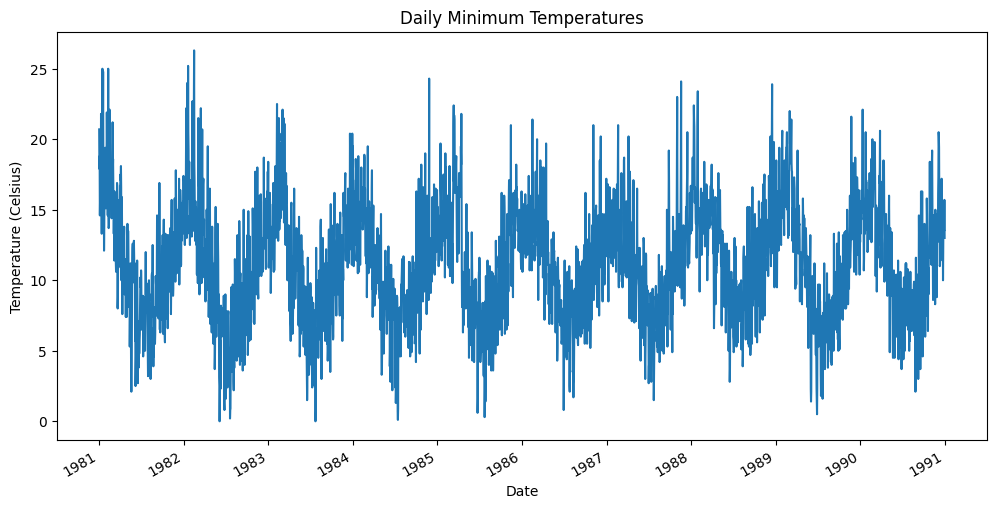

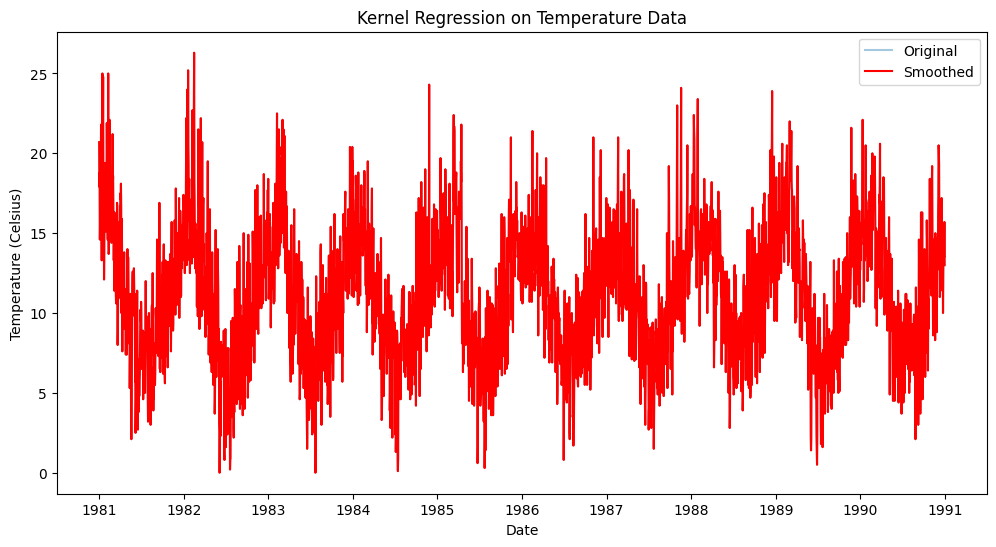

Mean Squared Error: 6.01


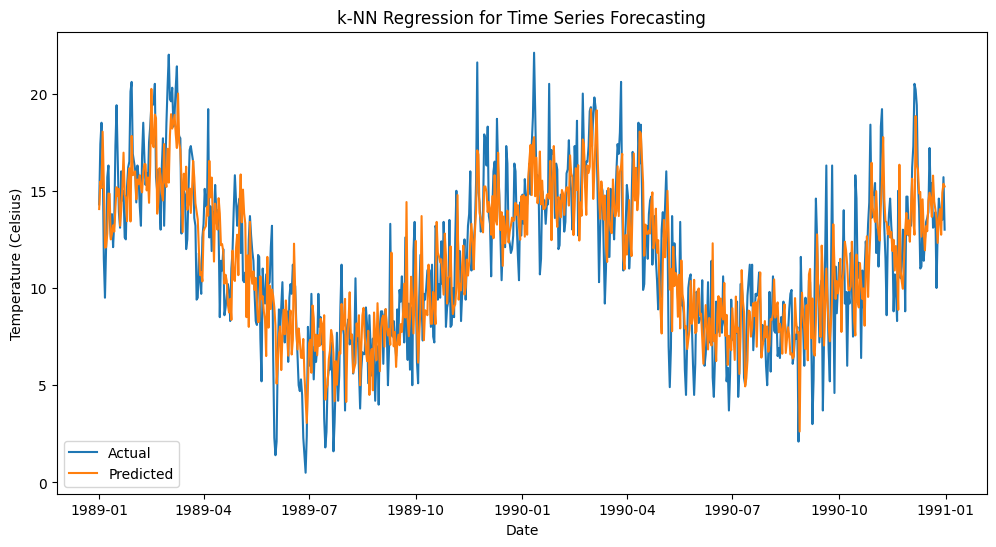

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
data = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
data.plot(figsize=(12, 6), legend=False, title='Daily Minimum Temperatures')
plt.ylabel('Temperature (Celsius)')
plt.show()

import numpy as np
from statsmodels.nonparametric.kernel_regression import KernelReg

data_reset = data.reset_index()
data_reset['Time'] = np.arange(len(data_reset))

kr = KernelReg(endog=data_reset['Temp'], exog=data_reset['Time'], var_type='c', bw='cv_ls')
y_pred, _ = kr.fit(data_reset['Time'])

plt.figure(figsize=(12, 6))
plt.plot(data_reset['Date'], data_reset['Temp'], label='Original', alpha=0.4)
plt.plot(data_reset['Date'], y_pred, label='Smoothed', color='red')
plt.title('Kernel Regression on Temperature Data')
plt.xlabel('Date')
plt.ylabel('Temperature (Celsius)')
plt.legend()
plt.show()

for lag in range(1, 8):
    data[f'lag_{lag}'] = data['Temp'].shift(lag)
data.dropna(inplace=True)

train = data[:'1988']
test = data['1989':]

X_train = train.drop('Temp', axis=1)
y_train = train['Temp']
X_test = test.drop('Temp', axis=1)
y_test = test['Temp']

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.title('k-NN Regression for Time Series Forecasting')
plt.xlabel('Date')
plt.ylabel('Temperature (Celsius)')
plt.legend()
plt.show()

<ipython-input-2-f79d080c8ff9>:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2010-01-01', periods=n, freq='M')


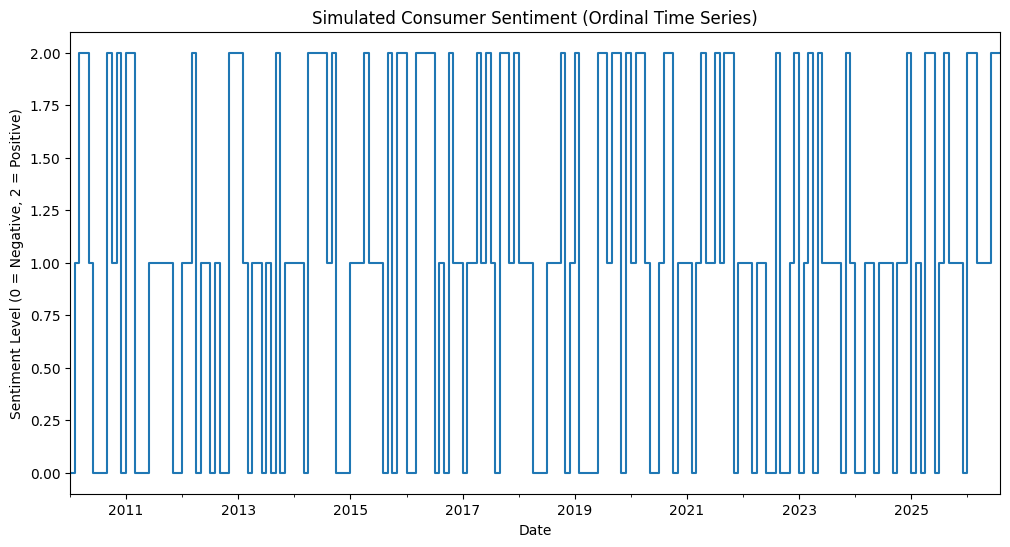

  Preparing metadata (setup.py) ... done
Accuracy: 0.5


In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 200
sentiment = np.zeros(n, dtype=int)

for t in range(1, n):
    prob = [0.2, 0.5, 0.3] if sentiment[t-1] == 1 else [0.3, 0.4, 0.3]
    sentiment[t] = np.random.choice([0, 1, 2], p=prob)

dates = pd.date_range(start='2010-01-01', periods=n, freq='M')
df = pd.DataFrame({'Date': dates, 'Sentiment': sentiment}).set_index('Date')

import matplotlib.pyplot as plt

df['Sentiment'].plot(figsize=(12, 6), drawstyle='steps-post')
plt.title('Simulated Consumer Sentiment (Ordinal Time Series)')
plt.ylabel('Sentiment Level (0 = Negative, 2 = Positive)')
plt.show()

df['lag1'] = df['Sentiment'].shift(1)
df.dropna(inplace=True)

!pip install mord --quiet

import mord as m
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df[['lag1']].astype(int)
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

model = m.LogisticIT()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

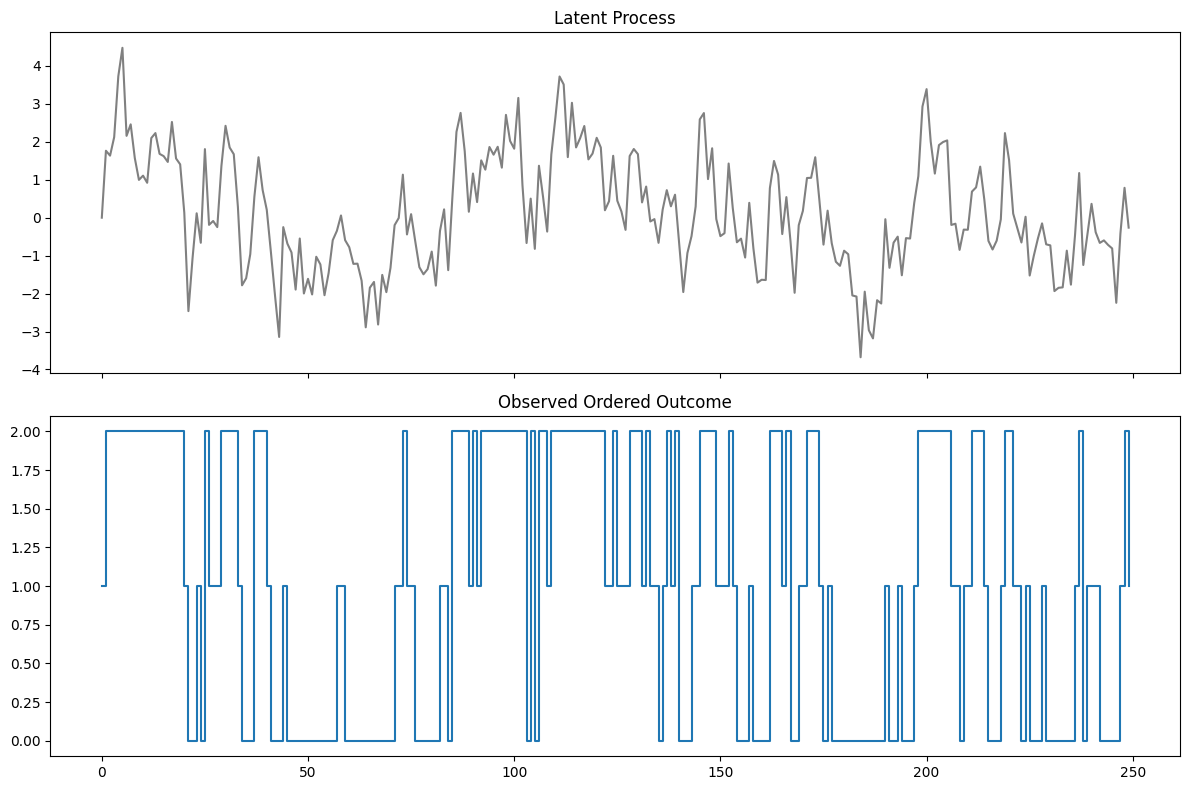

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.9/165.9 kB 4.4 MB/s eta 0:00:00


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


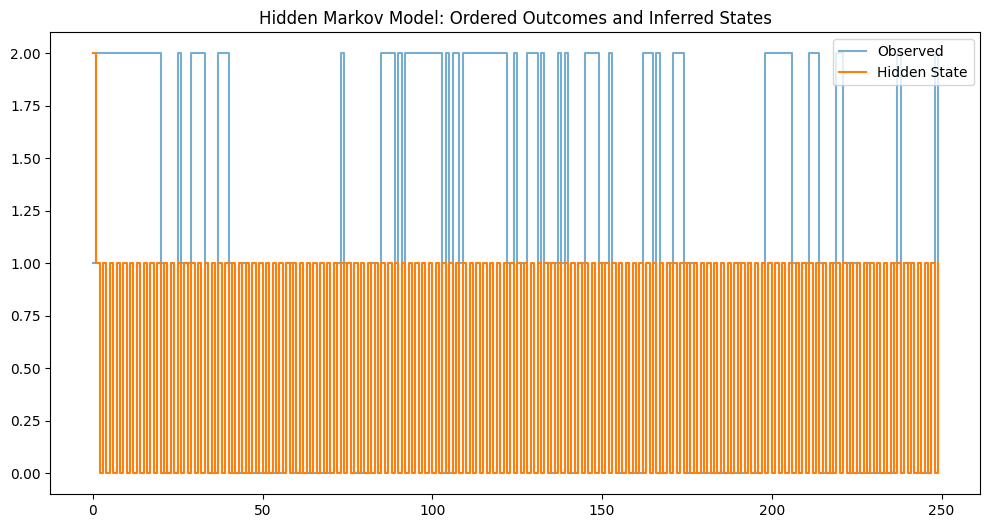

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
n = 250
latent = np.zeros(n)
obs = np.zeros(n, dtype=int)

# AR(1) latent process
for t in range(1, n):
    latent[t] = 0.7 * latent[t-1] + np.random.normal()

# Thresholds to generate ordered categories
thresholds = [-np.inf, -0.5, 0.5, np.inf]

for t in range(n):
    if latent[t] < thresholds[1]:
        obs[t] = 0
    elif latent[t] < thresholds[2]:
        obs[t] = 1
    else:
        obs[t] = 2

df = pd.DataFrame({'Latent': latent, 'Observed': obs})

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(df['Latent'], color='gray')
ax[0].set_title('Latent Process')
ax[1].plot(df['Observed'], drawstyle='steps-post')
ax[1].set_title('Observed Ordered Outcome')
plt.tight_layout()
plt.show()

!pip install hmmlearn --quiet

from hmmlearn import hmm

model = hmm.MultinomialHMM(n_components=3, n_iter=100)
obs_reshaped = df['Observed'].values.reshape(-1, 1)
model.fit(obs_reshaped)
hidden_states = model.predict(obs_reshaped)

plt.figure(figsize=(12, 6))
plt.plot(df['Observed'].values, label='Observed', drawstyle='steps-post', alpha=0.6)
plt.plot(hidden_states, label='Hidden State', drawstyle='steps-post')
plt.title('Hidden Markov Model: Ordered Outcomes and Inferred States')
plt.legend()
plt.show()


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from hmmlearn import hmm
import yfinance as yf

# Download from FRED via pandas_datareader (or use a pre-downloaded CSV)
import pandas_datareader.data as web

df = web.DataReader('NFIBETEX', 'fred', start='2000-01-01')
df.dropna(inplace=True)
df['Ordinal'] = df['NFIBETEX'].astype(int) + 1  # Map -1, 0, 1 to 0, 1, 2

# Fit HMM
X = df['Ordinal'].values.reshape(-1, 1)
model = hmm.MultinomialHMM(n_components=3, n_iter=100, random_state=42)
model.fit(X)
hidden_states = model.predict(X)
df['Hidden_State'] = hidden_states

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Ordinal'], label='Observed Outlook (Ordinal)', drawstyle='steps-post', alpha=0.6)
plt.plot(df.index, df['Hidden_State'], label='Inferred Hidden State', drawstyle='steps-post')
plt.title('NFIB: Good Time to Expand Business (Ordinal) with Hidden Markov States')
plt.xlabel('Date')
plt.yticks([0, 1, 2], ['Negative', 'Neutral', 'Positive'])
plt.legend()
plt.tight_layout()
plt.savefig('nfib_hmm_hidden_states.png')
plt.show()


RemoteDataError: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=NFIBETEX
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/css/all.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/assets/select2/dist/css/select2.min.css">\r\n    <style>p {\r\n        margin-bottom: 1.5em;\r\n    }</style>\r\n</head>\r\n<body>\r\n<link rel="preconnect" href="https://fonts.googleapis.com">\n<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>\n<link href="https://fonts.googleapis.com/css2?family=Roboto&display=swap" rel="stylesheet">\n<link href="https://fonts.googleapis.com/css2?family=Roboto+Slab&display=swap" rel="stylesheet">\n<!--googleoff: snippet-->\n<a href="#content-container" class="skip-to">Skip to main content</a>\n<!--googleon: snippet-->\n<a name="top" id="top"></a>\n<!--Move content shift styles internal to boost performance scores-->\n<style>\n    @media (min-width: 576px) {\n        .container {\n            max-width: 540px;\n        }\n    }\n    @media (min-width: 768px) {\n        .container {\n            max-width: 720px;\n        }\n    }\n    @media (min-width: 992px) {\n        .container {\n            max-width: 960px;\n        }\n    }\n    @media (min-width: 1200px) {\n        .container {\n            max-width: 1140px;\n        }\n    }\n    @media (min-width: 1400px) {\n        .container {\n            max-width: 1320px;\n        }\n    }\n    #zoom-and-share {\n        position:relative;\n        background-color: rgb(225, 233, 240);\n        min-height: 437px;\n    }\n</style>\n<div id="container" class="container">\n    <header style="display:block;height:auto;background:inherit;">\n        <h1 class="visually-hidden">Federal Reserve Economic Data</h1>\n        <nav class="navbar navbar-expand-lg header-not-home py-0 EL-nonhomepage-header EL-header-and-subheader">\n            <div id="hidden-user" class=\'hide\'></div>\n            <div id="action-modal"></div>\n            <div class="container-fluid align-items-stretch gx-0">\n                <div class="col-3">\n                    <a class="research-logo-gtm" target="_" href="https://www.stlouisfed.org">\n                        <img class="header-logo-eagle d-none d-lg-block" src="//fred.stlouisfed.org/images/masthead.svg?1" alt="Federal Reserve bank of St. Louis logo">\n                        <img class="header-logo-eagle d-lg-none" src="//fred.stlouisfed.org/images/logo-eagle.png" alt="Eagle Logo">\n                    </a>\n                </div>\n                <div class="fred-logo-div col-6 d-lg-none">\n                    <a class="fred-logo-gtm" href="//fred.stlouisfed.org/">\n                        <picture>\n                            <img class="header-logo" src="//fred.stlouisfed.org/images/fred-masthead-mobile-2x.png" alt="mini fred logo">\n                        </picture>\n                    </a>\n                </div>\n                <div class="col-lg-8 col-3 d-flex justify-content-end" style="padding-left: 15px; padding-right: 0px;">\n                    <nav id="blueheader-navbar-nav" style="height:100%">\n                        <ul id="blueheader-navbar" class="nav float-end">\n                            <li class="blueheader-navbar-item center-content-vertically d-none d-lg-block">\n                                <span id="research-resources-popover-container" class="research-resources-dropdown-gtm header-popover research-resources-popover-container">\n    <span id="research-resources-link" data-toggle="popover" class="align-icon" tabindex="0" style="cursor: pointer">Economic Research Resources\n        <i class="fas fa-angle-down fa-lg header-icon-padding" alt="Open Research Resources Menu Icon"></i>\n    </span>\n</span>\n\n<div class="hide">\n    <div id="research-resources-popover">\n        <div class="container research-resources" style="padding: 7px 25px 0px 25px;">\n            <div class="row">\n                <div class="col-7 research-resources-left-column">\n                    <div class="research-resources-text">Explore resources provided by the Research Division at the Federal Reserve Bank of St. Louis</div>\n                </div>\n                <div class="col-5 research-resources-right-column">\n                    <ul class="header-list-popover list-group flush-list">\n                        <li class="list-group-item">\n                            <a rel="noopener" target="_blank" class="errd-research-news-gtm" href="https://research.stlouisfed.org/publications/research-news/">Research News</a>\n                        </li>\n                        <li class="list-group-item">\n                            <a rel="noopener" target="_blank" class="errd-economists-gtm" href="https://research.stlouisfed.org/econ/">Economists</a>\n                        </li>\n                        <li class="list-group-item">\n                            <a rel="noopener" target="_blank" class="errd-publications-gtm"  href="https://research.stlouisfed.org/publications/">Publications</a>\n                        </li>\n                        <li class="list-group-item">\n                            <a rel="noopener" target="_blank" class="errd-working-papers-gtm" href="https://research.stlouisfed.org/wp/">Working Papers</a>\n                        </li>\n                        <li class="list-group-item">\n                            <a rel="noopener" target="_blank" class="errd-info-services-gtm" href="https://research.stlouisfed.org/info-services.html">Information Services</a>\n                        </li>\n                    </ul>\n                </div>\n            </div>\n        </div>\n    </div>\n</div>                            </li>\n                            <li class="blueheader-navbar-item center-content-vertically d-none d-lg-block">\n                                <span id="switchprod-popover-container" class="Switch-Products-gtm header-popover switchprod-popover-container">\n  <span id="switchProd" data-toggle="popover" data-toggle="popover" class="align-icon" tabindex="0" style="cursor: pointer"> Switch Products\n    <i class="fas fa-angle-down fa-lg header-icon-padding" alt="Open Switch Products Menu Icon"></i>\n  </span>\n</span>\n\n<div class="hide">\n  <div id="switchprod-popover">\n    <ul id="switch-prod-list" class="list-group switch-products-list" role="menu" aria-labelledby="switchProduct">\n    <li id="ham-fred-dev" class="list-group-item product-fred">\n        <a class="d-flex burger-fred-gtm" role="menuitem" href="//fred.stlouisfed.org">\n            <span class="w-100 fred-ultra-selected fred-ultra burger-fred-gtm">FRED</span>\n            <span class="flex-shrink-1 float-end switch-icon-padding burger-fred-gtm"><img src="//fred.stlouisfed.org/images/favicon.ico" width="16" height="16"></span>\n        </a>\n      </li>\n      <li id="ham-alfred" class="hover-nav list-group-item">\n          <a rel="noopener" target="_blank" class="d-flex burger-alfred-gtm" role="menuitem" href="//alfred.stlouisfed.org">\n            <span class="fred-thin burger-alfred-gtm">AL</span>\n            <span class="w-100 fred-ultra burger-alfred-gtm">FRED</span>\n            <span class="flex-shrink-1 float-end switch-icon-padding burger-alfred-gtm"><div style="width: 16px; height: 16px; background-color: #364e71; border-radius: 2px;"></div></span>\n        </a>\n      </li>\n      <li id="ham-fraser" class="hover-nav list-group-item">\n          <a rel="noopener" target="_blank" class="d-flex burger-fraser-gtm" role="menuitem" href="https://fraser.stlouisfed.org/">\n            <span class="w-100 fred-ultra burger-fraser-gtm">FRASER</span>\n            <span class="flex-shrink-1 float-end switch-icon-padding burger-fraser-gtm"><div style="width: 16px; height: 16px; background-color: #364e71; border-radius: 2px;"></div></span>\n        </a>\n      </li>\n      <li id="ham-ecolowdown" class="hover-nav-econ hover-nav list-group-item">\n          <a rel="noopener" target="_blank" class="d-flex burger-econlowdown-gtm" role="menuitem" href="https://www.econlowdown.org/">\n            <span class="w-100 fred-ultra-econ burger-econlowdown-gtm">ECON<br>LOWDOWN</span>\n              <span class="flex-shrink-1 float-end burger-econlowdown-gtm" style="padding-top: 15px"><div style="width: 16px; height: 16px; background-color: #364e71; border-radius: 2px;"></div></span>\n        </a>\n    </li>\n</ul>\n  </div>\n</div>                            </li>\n                            <li class="blueheader-navbar-item center-content-vertically d-none d-lg-block">\n                                <div class="hidden-xs" id="signin-wrap">\n                                    <div id="user-nav" class="EL-my-account-link"></div>\n                                </div>\n                            </li>\n                            <li class="blueheader-navbar-item center-content-vertically d-lg-none">\n                                <a class="hamburger-popover-container header-popover hamburger-gtm" href="#">\n    <i id="hamburger" data-toggle="popover" class="fas fa-bars hamburger-header" alt="Open Mobile Hamburger Menu"></i>\n</a>\n\n<div class="hide">\n    <div id="hamburger-popover">\n        <div class="hamburger-search-padding">\n            <div class=\'input-group\'>\n                <input type="text" class="form-control search-input nav-search" placeholder="Search FRED data...">\n                <button class="btn search-submit nav-search-button" type="submit">\n                    <i class="fa fa-search" alt="Submit Mobile Hamburger Search"></i>\n                </button>\n            </div>\n        </div>\n        <div id="hamburger-navigation">\n            <div id="hamburger-home">\n                <ul class="list-group flush-list hamburger-list col-12" style="padding-bottom: 20px;">\n                    <li class="list-group-item">\n                        <a class="burger-calendar-gtm" href="https://fred.stlouisfed.org/releases/calendar">Release Calendar</a>\n                    </li>\n                    <li class="list-group-item hamburger-menu-item" onclick="hamburgerMenuNavigation(\'hamburger-tools\')">\n                        <a class="burger-tools-gtm" href="#">FRED Tools\n                            <i class="fas fa-angle-right hamburger-nxt-page-icon" alt="FRED Tools Hamburger Submenu Icon"></i>\n                        </a>\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-blog-gtm" href="https://fredblog.stlouisfed.org">FRED Blog</a>\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-news-gtm" href="https://news.research.stlouisfed.org/category/fred-announcements/">FRED News</a>\n                    </li>\n                    <li class="list-group-item hamburger-menu-item" onclick="hamburgerMenuNavigation(\'hamburger-about-fred\')">\n                        <a class="burger-about-gtm" href="#">About FRED\n                            <i class="fas fa-angle-right hamburger-nxt-page-icon" alt="About FRED Hamburger Submenu Icon"></i>\n                        </a>\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-myaccount-gtm" href="https://fredaccount.stlouisfed.org">My Account</a>\n                    </li>\n                </ul>\n                <ul class="list-group flush-list hamburger-list col-12" style="padding-bottom: 0px;">\n                    <li class="list-group-item hamburger-menu-item" onclick="hamburgerMenuNavigation(\'hamburger-products\')">\n                        <a class="burger-switch-gtm" href="#">\n                            Switch Products<i class="fas fa-angle-right hamburger-nxt-page-icon" alt="Switch Products Hamburger Submenu Icon"></i>\n                        </a>\n                    </li>\n                    <li class="list-group-item hamburger-menu-item" onclick="hamburgerMenuNavigation(\'hamburger-research\')">\n                        <a class="burger-resources-gtm" href="#">\n                            Economic Research Resources<i class="fas fa-angle-right hamburger-nxt-page-icon" alt="Economic Research Resources Hamburger Submenu Icon"></i>\n                        </a>\n                        <p>Explore resources provided by the Research Division at the Federal Reserve Bank of St. Louis.</p>\n                    </li>\n                </ui>\n            </div>\n            \n            <div id="hamburger-about-fred" class="hide">\n                <ul class="list-group hamburger-submenu-list col-12">\n                    <li class="list-group-item hamburger-menu-item" onclick="hamburgerMenuNavigation(\'hamburger-home\')">\n                        <i class="fas fa-angle-left hamburger-previous-page-icon" alt="Return to Mobile/Hamburger Main Menu Icon"></i>\n                        About FRED\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-fred-about-gtm" href="https://fredhelp.stlouisfed.org/fred/about/about-fred/what-is-fred/"> What is FRED</a>\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-tutorials-gtm" href="https://fredhelp.stlouisfed.org"> Tutorials</a>\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-data-literacy-gtm" href="https://www.stlouisfed.org/education/digital-badges/fred-data-practitioner">\n                        Data Literacy\n                        </a>\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-contact-us-gtm" href="https://fred.stlouisfed.org/contactus/"> Contact Us</a>\n                    </li>\n                </ul>\n            </div>\n            \n            <div id="hamburger-tools" class="hide">\n                <ul class="list-group hamburger-submenu-list col-12">\n                    <li class="list-group-item hamburger-menu-item" onclick="hamburgerMenuNavigation(\'hamburger-home\')">\n                            <i class="fas fa-angle-left hamburger-previous-page-icon" alt="Return to Mobile/Hamburger Main Menu Icon"></i>\n                            FRED Tools\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-fred-excel-add-in-gtm" href="https://fred.stlouisfed.org/fred-addin"> FRED Add-in for Excel</a>\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-fred-api-gtm" href="https://fred.stlouisfed.org/docs/api/fred"> FRED API</a>\n                    </li>\n                    <li class="list-group-item">\n                        <a class="burger-fred-mobile-apps-gtm" href="https://fred.stlouisfed.org/fred-mobile"> FRED Mobile Apps</a>\n                    </li>\n                </ul>\n            </div>\n            \n            <div id="hamburger-research" class="hide">\n                <ul class="list-group hamburger-submenu-list col-12">\n                    <li class="list-group-item hamburger-menu-item" onclick="hamburgerMenuNavigation(\'hamburger-home\')">\n                        <span>\n                            <i class="fas fa-angle-left hamburger-previous-page-icon" alt="Return to Mobile/Hamburger Main Menu Icon"></i>\n                            Economic Research Resources\n                        </span>\n                    </li>\n                    <li class="list-group-item">\n                        <a rel="noopener" target="_blank" class="burger-research-news-gtm" href="https://research.stlouisfed.org/publications/research-news"> Research News</a>\n                    </li>\n                    <li class="list-group-item">\n                        <a rel="noopener" target="_blank" class="burger-economists-gtm" href="https://research.stlouisfed.org/econ/"> Economists</a>\n                    </li>\n                    <li class="list-group-item">\n                        <a rel="noopener" target="_blank" class="burger-publications-gtm" href="https://research.stlouisfed.org/publications/"> Publications</a>\n                    </li>\n                    <li class="list-group-item">\n                        <a rel="noopener" target="_blank" class="burger-working-papers-gtm" href="https://research.stlouisfed.org/wp/"> Working Papers</a>\n                    </li>\n                    <li class="list-group-item">\n                        <a rel="noopener" target="_blank" class="burger-info-services-gtm" href="https://research.stlouisfed.org/info-services.html"> Information Services</a>\n                    </li>\n                </ul>\n            </div>\n            \n            <div id="hamburger-products" class="hide">\n                <ul class="list-group hamburger-submenu-list col-12" style="padding-bottom: 0px !important">\n                    <li class="list-group-item hamburger-menu-item" onclick="hamburgerMenuNavigation(\'hamburger-home\')">\n                            <i class="fas fa-angle-left hamburger-previous-page-icon" alt="Return to Mobile/Hamburger Main Menu Icon"></i>\n                            Switch Products\n                    </li>\n                </ul>\n                <ul id="switch-prod-list" class="list-group switch-products-list" role="menu" aria-labelledby="switchProduct">\n    <li id="ham-fred-dev" class="list-group-item product-fred">\n        <a class="d-flex burger-fred-gtm" role="menuitem" href="//fred.stlouisfed.org">\n            <span class="w-100 fred-ultra-selected fred-ultra burger-fred-gtm">FRED</span>\n            <span class="flex-shrink-1 float-end switch-icon-padding burger-fred-gtm"><img src="//fred.stlouisfed.org/images/favicon.ico" width="16" height="16"></span>\n        </a>\n      </li>\n      <li id="ham-alfred" class="hover-nav list-group-item">\n          <a rel="noopener" target="_blank" class="d-flex burger-alfred-gtm" role="menuitem" href="//alfred.stlouisfed.org">\n            <span class="fred-thin burger-alfred-gtm">AL</span>\n            <span class="w-100 fred-ultra burger-alfred-gtm">FRED</span>\n            <span class="flex-shrink-1 float-end switch-icon-padding burger-alfred-gtm"><div style="width: 16px; height: 16px; background-color: #364e71; border-radius: 2px;"></div></span>\n        </a>\n      </li>\n      <li id="ham-fraser" class="hover-nav list-group-item">\n          <a rel="noopener" target="_blank" class="d-flex burger-fraser-gtm" role="menuitem" href="https://fraser.stlouisfed.org/">\n            <span class="w-100 fred-ultra burger-fraser-gtm">FRASER</span>\n            <span class="flex-shrink-1 float-end switch-icon-padding burger-fraser-gtm"><div style="width: 16px; height: 16px; background-color: #364e71; border-radius: 2px;"></div></span>\n        </a>\n      </li>\n      <li id="ham-ecolowdown" class="hover-nav-econ hover-nav list-group-item">\n          <a rel="noopener" target="_blank" class="d-flex burger-econlowdown-gtm" role="menuitem" href="https://www.econlowdown.org/">\n            <span class="w-100 fred-ultra-econ burger-econlowdown-gtm">ECON<br>LOWDOWN</span>\n              <span class="flex-shrink-1 float-end burger-econlowdown-gtm" style="padding-top: 15px"><div style="width: 16px; height: 16px; background-color: #364e71; border-radius: 2px;"></div></span>\n        </a>\n    </li>\n</ul>\n            </div>\n        </div>\n    </div>\n</div>\n                            </li>\n                        </ul>\n                    </nav>\n                </div>\n            </div>\n        <div id="notifications-container"></div>\n    </nav>\n    <div class=\'navbar navbar-expand-lg sub-header EL-header-and-subheader\'>\n        <div class="container-fluid gx-0">\n            <div class="col-lg-3 col-md-3 d-none d-lg-block" style="padding-left: 15px; padding-right: 15px;" >\n                <a class="fred-logo-gtm" href="//fred.stlouisfed.org/">\n                        <img id="fred-logo-subheader" src="//fred.stlouisfed.org/images/fred-logo-2x-white.png" alt="FRED Economic Data, St. Louis FED">\n                </a>\n            </div>\n            <div class="col d-flex justify-content-end" style="padding-left: 15px; padding-right: 15px;">\n                <div class="container-fluid gx-0">\n                    <div class="search-header-div float-end col-8 d-none d-lg-block">\n                        <div class=\'input-group EL-header-search-container\' id="search-container-header">\n                            <select id="head-search" class=\'EL-header-search\' style="\n                                border-radius: 25px 0 0 25px;\n                                background-color: #5e88a2;\n                                border-right: 0;\n                                color: #fff;\n                                font-family: Roboto,sans-serif;\n                                border: none;\n                                height: 45px;\n                            ">\n                                <option></option>\n                            </select>\n                            <input type="hidden" name="st" class="search-text-input">\n                            <button class="btn search-submit-select2" id="select2-nav-search-button" aria-label="search" type="submit">\n                                <i class="fa fa-search"></i>\n                            </button>\n                        </div>\n                    </div>\n                    <nav class="row col-12 navbar EL-main-nav navbar-expand-sm d-none d-lg-flex" id="subheader-nav" role="navigation">\n    <div class="navbar-padding navbar-collapse collapse d-flex justify-content-end">\n        <ul id="subheader-navbar" class="nav float-end navbar-nav">\n            <li class="nav-li-subheader">\n                <a href="https://fred.stlouisfed.org/releases/calendar" class="nav-releasecal-subheader-gtm">Release Calendar</a>\n            </li>\n            <li class="nav-li-subheader">\n              <span class="sub-header-nav-tools-gtm  header-popover fred-tools-container" tabindex="0" aria-labelledby="fred-tools-link">\n  <span id="fred-tools-link" data-toggle="popover" class="align-icon">FRED Tools\n    <i class="fas fa-angle-down header-icon-padding" alt="Open FRED Tools Menu Icon"></i>\n  </span>\n</span>\n\n<div class="hide">\n  <div id="fred-tools-popover">\n    <ul class="header-list-popover list-group flush-list">\n      <li class="list-group-item">\n        <a class="homepage-nav-tools-fred-excel-addin-gtm" href="https://fred.stlouisfed.org/fred-addin">FRED Add-in for Excel</a>\n      </li>\n      <li class="list-group-item">\n        <a class="homepage-nav-tools-fred-api-gtm" href="https://fred.stlouisfed.org/docs/api/fred">FRED API</a>\n      </li>\n      <li class="list-group-item">\n        <a class="homepage-nav-tools-fred-mobile-gtm" href="https://fred.stlouisfed.org/fred-mobile">FRED Mobile Apps</a>\n      </li>\n    </ul>\n  </div>\n</div>            </li>\n            <li class="nav-li-subheader">\n                <a href="https://news.research.stlouisfed.org/category/fred-announcements/" class="nav-news-subheader-gtm">FRED News</a>\n            </li>\n            <li class="nav-li-subheader">\n                <a href="https://fredblog.stlouisfed.org/" class="nav-fredblog-subheader-gtm">FRED Blog</a>\n            </li>\n            <li class="nav-li-subheader">\n              \n<span class="subheader-nav-about-gtm header-popover about-fred-container" tabindex="0" aria-labelledby="about-fred-link">\n  <span id="about-fred-link" data-toggle="popover" class="align-icon">About FRED\n    <i class="fas fa-angle-down header-icon-padding" alt="Open About FRED Menu Icon"></i>\n  </span>\n</span>\n\n<div class="hide">\n  <div id="about-fred-popover">\n      <ul class="header-list-popover list-group flush-list">\n        <li class="list-group-item">\n          <a class="about-fred-what-is-gtm" href="https://fredhelp.stlouisfed.org/fred/about/about-fred/what-is-fred/">\n            What is FRED\n          </a>\n        </li>\n        <li class="list-group-item">\n          <a class="about-fred-tutorials-gtm" href="https://fredhelp.stlouisfed.org">\n            Tutorials\n          </a>\n        </li>\n        <li class="list-group-item">\n          <a class="about-research-data-literacy-gtm" href="https://www.stlouisfed.org/education/digital-badges/fred-data-practitioner">\n            Data Literacy\n          </a>\n        </li>\n        <li class="list-group-item">\n          <a class="about-fred-contact-gtm" href="https://fred.stlouisfed.org/contactus/ ">\n            Contact Us\n          </a>\n        </li>\n      </ul>\n  </div>\n</div>\n            </li>\n        </ul>\n    </div>\n</nav>\n                </div>\n            </div>\n        </div>\n    </div>\n    </header>\n  <div class="clear row gx-0" id="content-container">\n\n\r\n<!--BEGIN CONTENT-->\r\n<div class="error-container">\r\n    <h1>Looking for Something?</h1>\r\n    <p class="large">We\'re sorry, the page you were looking for cannot be found. Please feel free\r\n        to <a href="/contactus/">contact us</a> if the problem persists.</p>\r\n    <p class="large">Searching may help find what are you looking for. If all else fails, you can head\r\n        <a href="/">Home</a>\r\n    </p>\r\n    <form action="/searchresults" id="search-form-404">\r\n        <label for="search-text">Search for:</label><br>\r\n        <input type="text" name="st" id="search-text" size="50" class="form-control">\r\n        <input type="submit" class="btn btn-default" value="Search" id="404-search-button" name="404-search-button">\r\n    </form>\r\n</div>\r\n<link href="/css/footer.min.css?1553087256" rel="stylesheet" media="all">\r\n<!--END CONTENT-->\r\n<style>\n    .h2-508 {\n        font-size: 1em !important;\n        margin-top: 2px !important;\n        margin-bottom: 2px !important\n    }\n</style>\n\n<br class="clear">\n</div>\n\n<div class="footer2 hidden-print row EL-footer2" style="padding-top: 20px;">\n    <div class="col-12 col-md-3">\n        <h3>Need Help?</h3>\n        <div>\n            <a class="footer-questions-gtm" href="//fred.stlouisfed.org/contactus/" class="q-and-a-link-gtm">Questions or\n                Comments</a>\n        </div>\n        <div style="padding: 10px 0 20px 0;">\n            <a class="footer-fredhelp-gtm" href="//fredhelp.stlouisfed.org/">FRED Help</a>\n        </div>\n    </div>\n\n    <div class="col-12 col-md-6">\n        <div class="col-12">\n            <h3>Subscribe to the FRED newsletter</h3>\n            <form id="subscribe-div" class="form-horizontal form-control newsletter-form" style="padding:0;margin:0">\n                <div class="col-12" style="padding-left: 0;">\n                    <div class="input-group">\n                        <input id="subscribe-email-input" type="text" name="email" placeholder="Email"\n                            class="form-control email" style="padding: 4px 0px 4px 14px;" aria-label="email">\n                        <button id="subscribe-email-btn" type="button"\n                            class="btn subscribe-newsletter-btn-gtm"\n                            style="border-radius: 4px; border-color: #cccccc; padding: 0 7px 0px 7px; font-size: 14px;">Subscribe</button>\n                    </div>\n                </div>\n            </form>\n        </div>\n    </div>\n    <hr class="d-md-none" style="border: none;">\n    <div class="col-12 col-md-3">\n        <h3 style="width: 100%; text-align: center;">Follow us</h3>\n        <div id="follow-icons" class="col-12" style="text-align: center;">\n            <span id="x-container" class="icon-container"><a aria-label="Saint Louis Fed X page" href="http://bit.ly/9ngC3L"><img class="x-logo" src="//fred.stlouisfed.org/images/x-logo.svg"></a></span>\n            <span id="fb-container" class="icon-container"><a aria-label="Saint Louis Fed facebook page" href="https://www.facebook.com/stlfed"><i\n                    class="fab fa-fw fa-facebook-f"></i> </a></span>\n            <span id="yt-container" class="icon-container"><a aria-label="Saint Louis Fed youtube page" href="http://bit.ly/aY9TVF"><i\n                    class="fab fa-fw fa-youtube"></i></a></span>\n            <span id="li-container" class="icon-container"><a aria-label="Saint Louis Fed linkedin page" href="http://bit.ly/d056zL"><i\n                    class="fab fa-fw fa-linkedin-in"></i></a></span>\n        </div>\n    </div>\n</div>\n\n<div class="hidden-print d-md-none">\n    <a style="margin: 5px; display: block; padding:5px 10px; text-align: center" href="#top">Back to Top</a>\n</div>\n\n<div id="footer-bottom" class="row EL-footer-bottom">\n    <div id="address" class="col-12 col-md-8 d-none d-sm-block">\n        Federal Reserve Bank of St. Louis,\n        One Federal Reserve Bank Plaza,\n        St. Louis, MO 63102\n    </div>\n    <div id="legal-and-privacy" class="col-12 col-md-4 d-none d-sm-block">\n        <a class="me-4 footer-link" href="//fred.stlouisfed.org/legal/">Legal</a>\n        <a class="footer-link" href="//research.stlouisfed.org/privacy.html">Privacy Notice & Policy</a>\n    </div>\n    <div class="col-12 d-block d-sm-none text-center">\n        <div>Federal Reserve Bank of St. Louis, One Federal Reserve Bank Plaza, St. Louis, MO 63102</div>\n        <div class="mt-3 footer-link"><a href="//fred.stlouisfed.org/legal/">Legal</a></div>\n        <div class="mt-3 footer-link"><a href="//research.stlouisfed.org/privacy.html">Privacy Notice & Policy</a></div>\n    </div>\n</div>\n\n<script>\n    // function to parse cookies, and return the value\n    function getCookie(name) {\n        var cookies = document.cookie.split(\';\');\n        for (var i in cookies) {\n            var cookie = cookies[i].trim().split(\'=\');\n            if (cookie[0] == name) {\n                return cookie[1];\n            }\n        }\n        return null;\n    }\n    // certain pages in FRED set a custom tag variable\n    // this gets sent to Google Analytics so we can see what tags people are using\n    if (window.tags) {\n        dataLayer.push({ \'tags\': tags });\n\n    }\n\n    // if the user is logged in, send the value of the liruid cookie to Google Analytics\n    var researchLiruid = getCookie(\'research-liruid\');\n    dataLayer.push({ \'userId\': researchLiruid });\n\n</script>\n<script src="//fred.stlouisfed.org/assets/jquery/dist/1733940506.jquery.min.js" type="text/javascript"></script>\n<script src="//fred.stlouisfed.org/assets/popperjs/dist/umd/1733940507.popper.min.js"></script>\n<script src="//fred.stlouisfed.org/assets/bootstrap/dist/js/1733940507.bootstrap.min.js"></script>\n<script src="//fred.stlouisfed.org/assets/select2/dist/js/1733940507.select2.full.min.js"></script>\n<script>\n    // force expire the .fred.stlouisfed.org _ga cookie\n    document.cookie = document.cookie + \'_ga=;domain=.fred.stlouisfed.org;expires=Sat, 01-Jan-2000 00:00:00 GMT\';\n</script>\n\n<script defer src="//fred.stlouisfed.org/assets/jquery-menu-aim/1741717871.jquery.menu-aim.min.js"></script>\n\n<script src="//fred.stlouisfed.org/js/1741717872.common.min.js"></script>\n\n<script src="//fred.stlouisfed.org/assets/js-cookie/src/js.cookie.js"></script>\n<script src="//fred.stlouisfed.org/js/1741717871.508.min.js"></script>\n\n<script>\n    var appConfig = {\n        uapi_host: \'https://fred.stlouisfed.org/uapi\',\n        research_host: \'https://research.stlouisfed.org\',\n        fred_host: \'https://fred.stlouisfed.org\',\n        alfred_host: \'https://alfred.stlouisfed.org\',\n        gsi_client_id: \'115290014367-vpb89b600koe9kn0njeeq38c1unfr3gk.apps.googleusercontent.com\',\n        fred_account_host: \'https://fredaccount.stlouisfed.org\',\n    };\n\n    var domain_suffix = (window.location.hostname.split(".")[0].split("-")[1] || \'\');\n    appConfig.logged_in = Cookies.get(\'research-lirua\' + (domain_suffix ? \'-\' + domain_suffix : \'\')) !== null && Cookies.get(\'research-lirua\' + (domain_suffix ? \'-\' + domain_suffix : \'\')) !== undefined;\n    var getAuth = function (callback) {\n        if (typeof callback === \'function\') {\n            callback();\n        }\n        return;\n    };\n    window.getAuth = getAuth;\n\n</script>\n<script defer src="//fred.stlouisfed.org/js/1711050338.banner.js"></script>\n<script src="//accounts.google.com/gsi/client" async defer></script>\n<script src="//fred.stlouisfed.org/assets/research/fred-account-react/dist/1741717851.main.dist.js"></script>\n<script src="//fred.stlouisfed.org/assets/research/fred-account-react/dist/1741717851.vendor.dist.js"></script>\n\n<script type="text/javascript">\n    window.addEventListener("DOMContentLoaded", function () {\n        $(document).ready(function () {\n            // handle tabbing into and out of the subscribe text box\n            $(\'#subscribe-email-input\').on(\'focusout\', function () {\n                $(this).css(\'outline-color\', \'white\');\n            });\n\n            $(\'#subscribe-email-input\').on(\'keyup\', function (e) {\n                if (e.key == \'Tab\') { // tab into search input\n                    $(\'#subscribe-email-input\').css({ \'outline-color\': \'#022856\' });\n                }\n            });\n            $(\'.select2-search__field\').on(\'focusout\', function() {\n                $(this).css(\'outline\', \'2px solid #fff\');\n            });\n\n            // handle tabbing into and out of the search bar and at a glance tabs\n            $(document).on(\'keyup\', function(e) {\n                if ($(document.activeElement).hasClass(\'select2-search__field\') && e.keyCode === 9) { // tab into search input\n                  $(\'.select2-search__field\').css({\'outline\': \'2px solid #022856\'});\n                }\n            });\n        });\n    });\n</script>\n\n\n<script type="text/javascript">\n  \n</script>\n\r\n</body>\r\n</html>\r\n'

In [8]:
from fredapi import Fred
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm

# Replace this with your actual FRED API key
fred = Fred(api_key='8f058d10ec8c788296c040ea09e634d5')

# Download data
series = fred.get_series('NFIBETEX', observation_start='2000-01-01')
df = series.to_frame(name='NFIBETEX')
df.index.name = 'Date'
df.dropna(inplace=True)

# Map -1 (bad time), 0 (uncertain), 1 (good time) → ordinal values 0, 1, 2
df['Ordinal'] = df['NFIBETEX'].astype(int) + 1


ValueError: Bad Request.  The series does not exist.

In [6]:
!pip install hmmlearn --quiet

In [7]:
!pip install fredapi

In [9]:
import pandas_datareader.data as web
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
import numpy as np

# Download consumer sentiment index from FRED
df = web.DataReader("UMCSENT", "fred", start="2000-01-01")
df = df.dropna().rename(columns={"UMCSENT": "Sentiment"})

# Bin into ordinal categories: 0 = low, 1 = medium, 2 = high
# Thresholds chosen based on historical percentiles
df["Ordinal"] = pd.cut(
    df["Sentiment"],
    bins=[-np.inf, 70, 85, np.inf],
    labels=[0, 1, 2]
).astype(int)


In [10]:
model = hmm.MultinomialHMM(n_components=3, n_iter=100, random_state=42)
X = df["Ordinal"].values.reshape(-1, 1)
model.fit(X)
df["Hidden_State"] = model.predict(X)


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


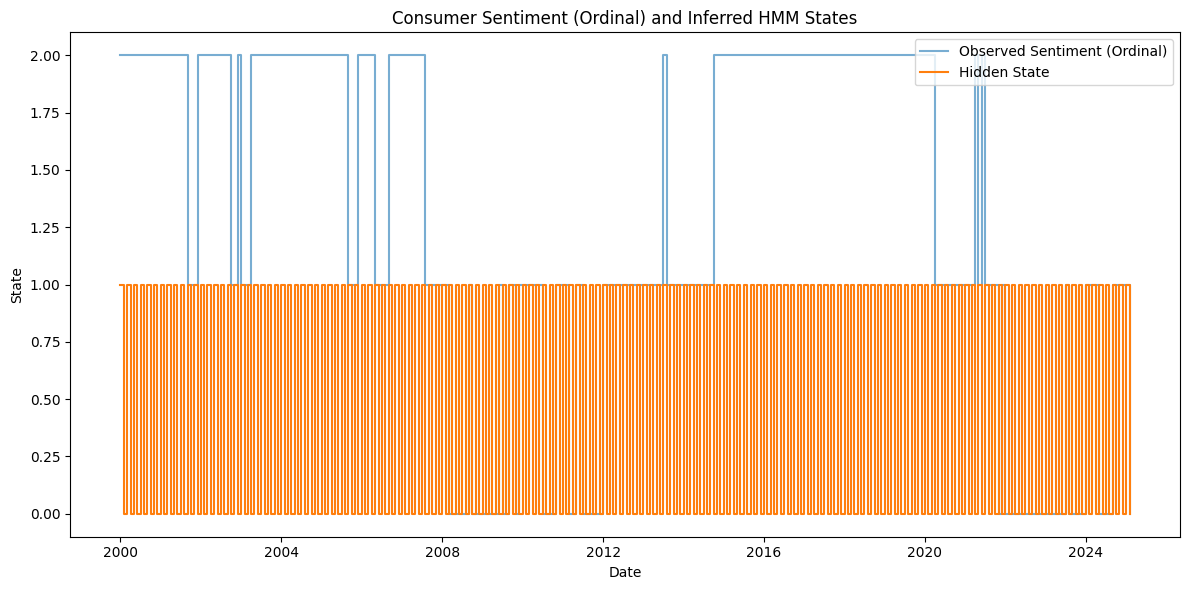

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Ordinal"], drawstyle="steps-post", label="Observed Sentiment (Ordinal)", alpha=0.6)
plt.plot(df.index, df["Hidden_State"], drawstyle="steps-post", label="Hidden State")
plt.title("Consumer Sentiment (Ordinal) and Inferred HMM States")
plt.xlabel("Date")
plt.ylabel("State")
plt.legend()
plt.tight_layout()
plt.savefig("umcsent_hmm_hidden_states.png")
plt.show()


In [12]:

import pandas_datareader.data as web
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from hmmlearn import hmm

# Step 1: Load and clean the data
df = web.DataReader("UMCSENT", "fred", start="2000-01-01")
df = df.dropna().rename(columns={"UMCSENT": "Sentiment"})

# Step 2: Bin into 3 real categories using quantiles instead of hard thresholds
quantiles = df["Sentiment"].quantile([0.33, 0.66])
df["Ordinal"] = pd.cut(
    df["Sentiment"],
    bins=[-np.inf, quantiles[0.33], quantiles[0.66], np.inf],
    labels=[0, 1, 2]
).astype(int)

X = df["Ordinal"].values.reshape(-1, 1)

model = hmm.MultinomialHMM(n_components=3, n_iter=100, random_state=42)
model.n_features = 3
model.fit(X)
df["Hidden_State"] = model.predict(X)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Ordinal"], drawstyle="steps-post", label="Observed Sentiment (Ordinal)", alpha=0.6)
plt.plot(df.index, df["Hidden_State"], drawstyle="steps-post", label="Hidden State")
plt.title("Consumer Sentiment (Ordinal, Quantile-Binned) and HMM Inferred States")
plt.xlabel("Date")
plt.ylabel("State")
plt.legend()
plt.tight_layout()
plt.savefig("umcsent_fixed_hmm_states.png")
plt.show()


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


ValueError: Unexpected number of dimensions, got 1 but expected 3

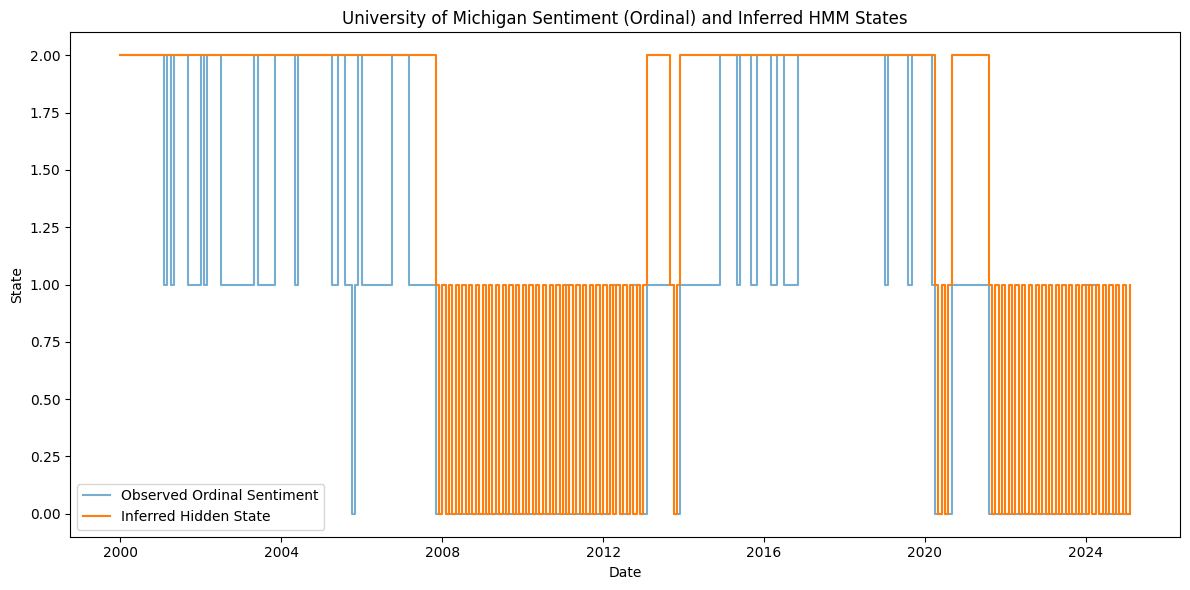

In [14]:

from hmmlearn.hmm import CategoricalHMM

model = CategoricalHMM(n_components=3, n_iter=100, random_state=42)
model.fit(X)
df["Hidden_State"] = model.predict(X)

import pandas_datareader.data as web
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from hmmlearn.hmm import CategoricalHMM

# Step 1: Load data
df = web.DataReader("UMCSENT", "fred", start="2000-01-01")
df = df.dropna().rename(columns={"UMCSENT": "Sentiment"})

# Step 2: Bin using quantiles into 3 ordinal levels
df["Ordinal"] = pd.qcut(df["Sentiment"], q=3, labels=False)


X = df["Ordinal"].values.reshape(-1, 1)
model = CategoricalHMM(n_components=3, n_iter=100, random_state=42)
model.fit(X)
df["Hidden_State"] = model.predict(X)


# Step 4: Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Ordinal"], drawstyle="steps-post", label="Observed Ordinal Sentiment", alpha=0.6)
plt.plot(df.index, df["Hidden_State"], drawstyle="steps-post", label="Inferred Hidden State")
plt.title("University of Michigan Sentiment (Ordinal) and Inferred HMM States")
plt.xlabel("Date")
plt.ylabel("State")
plt.legend()
plt.tight_layout()
plt.savefig("umcsent_hmm_categorical.png")
plt.show()


In [15]:
print(df["Ordinal"].value_counts())


Ordinal
1    101
0    101
2    100
Name: count, dtype: int64


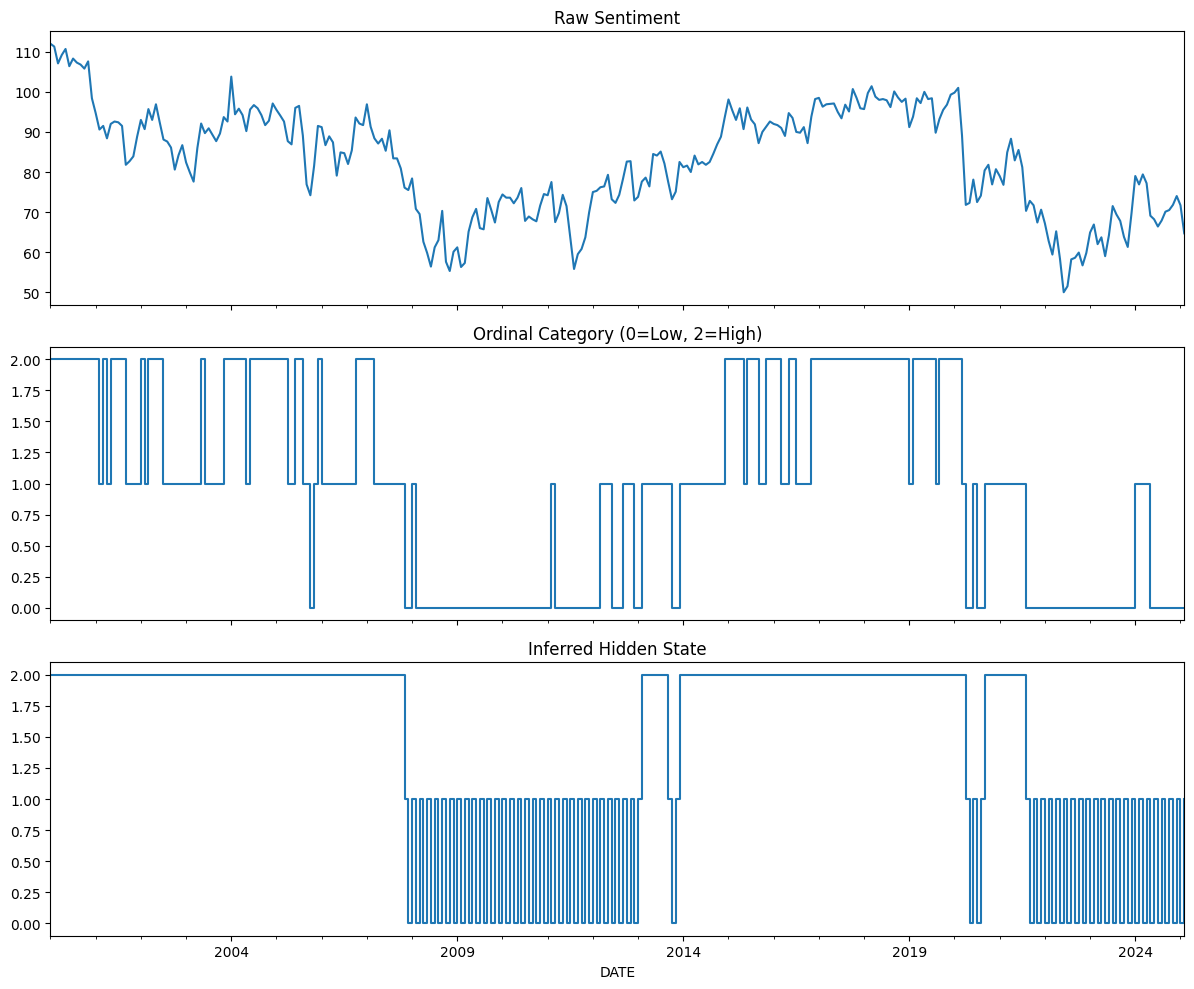

In [16]:

df["Ordinal"].groupby(df["Ordinal"]).apply(lambda x: (x.index.min(), x.index.max()))

df["Hidden_State"].value_counts()

fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

df["Sentiment"].plot(ax=ax[0], title="Raw Sentiment")
df["Ordinal"].plot(ax=ax[1], title="Ordinal Category (0=Low, 2=High)", drawstyle="steps-post")
df["Hidden_State"].plot(ax=ax[2], title="Inferred Hidden State", drawstyle="steps-post")

plt.tight_layout()
plt.savefig("umcsent_diagnostics.png")
plt.show()

In [17]:
df["Hidden_State"].value_counts()

,count
Hidden_State,
2,188
1,59
0,55


In [18]:

model = CategoricalHMM(n_components=2, n_iter=100, random_state=42)


df["Delta"] = df["Sentiment"].diff().fillna(0)
df["Delta_Ordinal"] = pd.qcut(df["Delta"], q=3, labels=False)

for i, probs in enumerate(model.emissionprob_):
    print(f"State {i}: {[round(p, 3) for p in probs]}")


AttributeError: 'CategoricalHMM' object has no attribute 'emissionprob_'

In [19]:
import numpy as np

symbols = np.array([[0], [1], [2]])  # possible ordinal values
log_likelihoods = model._compute_log_likelihood(symbols)

probs = np.exp(log_likelihoods)
for i, row in enumerate(probs.T):
    print(f"State {i}: {[round(p, 3) for p in row]}")


AttributeError: 'CategoricalHMM' object has no attribute 'emissionprob_'

In [20]:
model.emissionprob_

from pprint import pprint

# This works for CategoricalHMM from hmmlearn >= 0.3.0
emissions = model._compute_log_likelihood(np.array([[0], [1], [2]]))
print("Log-likelihoods of each observation per state:")
pprint(emissions)

AttributeError: 'CategoricalHMM' object has no attribute 'emissionprob_'

In [21]:
df.head()

,Sentiment,Ordinal,Hidden_State,Delta,Delta_Ordinal
DATE,,,,,
2000-01-01,112.0,2,2,0.0,1
2000-02-01,111.3,2,2,-0.7,1
2000-03-01,107.1,2,2,-4.2,0
2000-04-01,109.2,2,2,2.1,2
2000-05-01,110.7,2,2,1.5,1


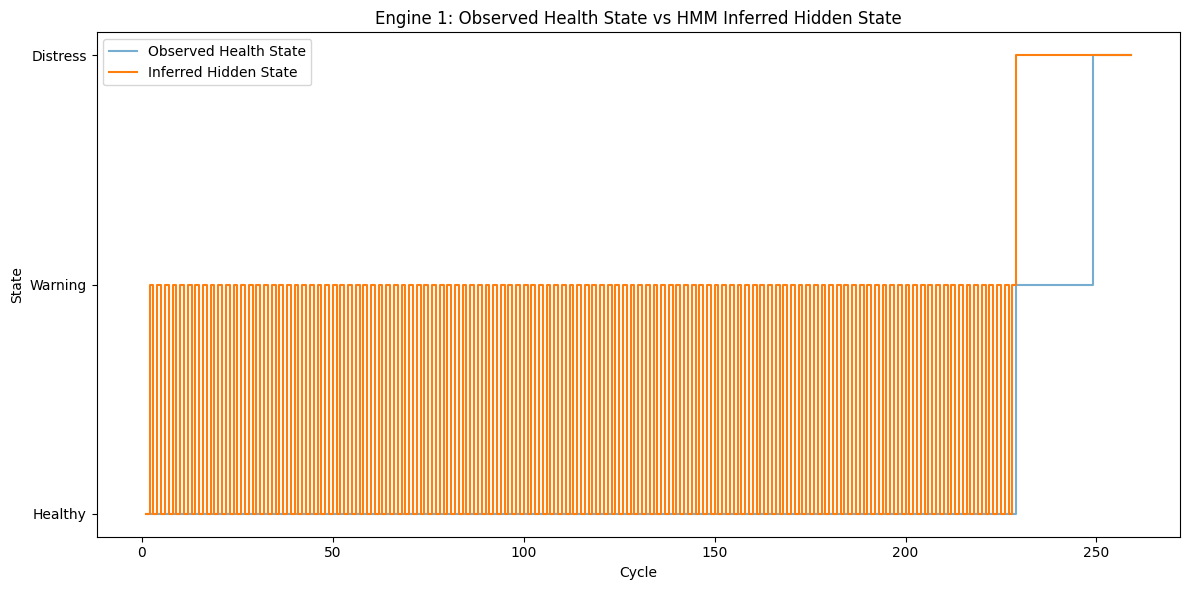

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from hmmlearn.hmm import CategoricalHMM

# Load FD003 dataset
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)

# Step 1: Calculate RUL
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']

# Step 2: Categorize health state
def categorize_rul(rul):
    if rul > 30:
        return 0  # healthy
    elif rul > 10:
        return 1  # warning
    else:
        return 2  # distress

df['HealthState'] = df['RUL'].apply(categorize_rul)

# Step 3: Choose a unit (e.g., engine 1)
unit_df = df[df['unit'] == 1].copy()

# Step 4: Prepare data for HMM
X = unit_df['HealthState'].values.reshape(-1, 1)

# Step 5: Fit Categorical HMM
model = CategoricalHMM(n_components=3, n_iter=100, random_state=42)
model.fit(X)
unit_df['HiddenState'] = model.predict(X)

# Step 6: Plot
plt.figure(figsize=(12, 6))
plt.plot(unit_df['cycle'], unit_df['HealthState'], label='Observed Health State', drawstyle='steps-post', alpha=0.6)
plt.plot(unit_df['cycle'], unit_df['HiddenState'], label='Inferred Hidden State', drawstyle='steps-post')
plt.title('Engine 1: Observed Health State vs HMM Inferred Hidden State')
plt.xlabel('Cycle')
plt.ylabel('State')
plt.yticks([0, 1, 2], ['Healthy', 'Warning', 'Distress'])
plt.legend()
plt.tight_layout()
plt.savefig("engine1_hmm_states.png")
plt.show()


In [24]:

import torch
from torch.utils.data import Dataset, DataLoader

class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        self.seq_len = seq_len
        self.X, self.y = [], []
        features = [f'sensor_{i}' for i in range(1, 22)]
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            vals = unit_df[features].values
            labels = unit_df['HealthState'].values
            for i in range(len(vals) - seq_len):
                self.X.append(vals[i:i+seq_len])
                self.y.append(labels[i+seq_len])
        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = TurbofanDataset(df, seq_len=30)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

import torch.nn as nn

class HealthLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

model = HealthLSTM(input_size=21, hidden_size=64, output_size=3)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    total_loss = 0
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.2f}")


<ipython-input-24-cd4780a0068a>:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  self.X = torch.tensor(self.X, dtype=torch.float32)


Epoch 1, Loss: 365.12
Epoch 2, Loss: 341.59
Epoch 3, Loss: 341.50
Epoch 4, Loss: 341.55
Epoch 5, Loss: 341.62
Epoch 6, Loss: 341.60
Epoch 7, Loss: 341.45
Epoch 8, Loss: 341.55
Epoch 9, Loss: 341.57
Epoch 10, Loss: 341.70
Epoch 11, Loss: 341.72
Epoch 12, Loss: 341.61
Epoch 13, Loss: 341.72
Epoch 14, Loss: 341.49
Epoch 15, Loss: 341.55
Epoch 16, Loss: 341.49
Epoch 17, Loss: 341.70
Epoch 18, Loss: 341.66
Epoch 19, Loss: 341.57
Epoch 20, Loss: 341.53


Epoch 1, Loss: 183.71
Epoch 2, Loss: 108.71
Epoch 3, Loss: 93.84
Epoch 4, Loss: 82.39
Epoch 5, Loss: 74.58
Epoch 6, Loss: 68.02
Epoch 7, Loss: 64.84
Epoch 8, Loss: 62.96
Epoch 9, Loss: 58.84
Epoch 10, Loss: 57.41
Epoch 11, Loss: 57.26
Epoch 12, Loss: 55.88
Epoch 13, Loss: 53.97
Epoch 14, Loss: 53.24
Epoch 15, Loss: 52.90
Epoch 16, Loss: 51.69
Epoch 17, Loss: 51.59
Epoch 18, Loss: 51.20
Epoch 19, Loss: 50.00
Epoch 20, Loss: 49.13


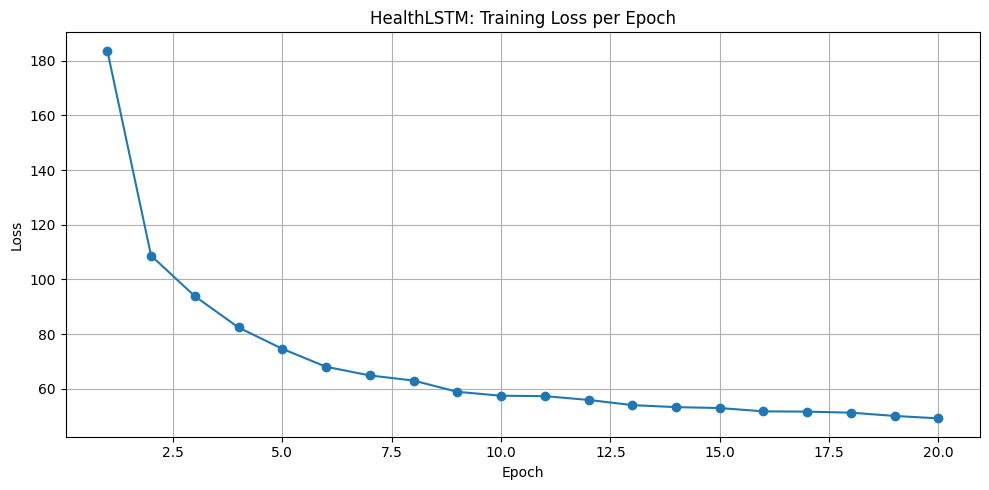

In [25]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load FD003 dataset
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)

# Add RUL and HealthState
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']

df['HealthState'] = pd.cut(
    df['RUL'],
    bins=[-1, 10, 30, np.inf],
    labels=[2, 1, 0]
).astype(int)


# Normalize sensor features
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# Dataset class
class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        self.seq_len = seq_len
        X, y = [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            sensors = unit_df[sensor_cols].values
            labels = unit_df['HealthState'].values
            for i in range(len(sensors) - seq_len):
                X.append(sensors[i:i+seq_len])
                y.append(labels[i+seq_len])
        self.X = torch.from_numpy(np.array(X)).float()
        self.y = torch.from_numpy(np.array(y)).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Model
class HealthLSTM(nn.Module):
    def __init__(self, input_size=21, hidden_size=64, output_size=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

# Training setup
dataset = TurbofanDataset(df, seq_len=30)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
model = HealthLSTM()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train
loss_history = []
for epoch in range(20):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_history.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), loss_history, marker='o')
plt.title("HealthLSTM: Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 1, Loss: 51.40
Epoch 2, Loss: 28.41
Epoch 3, Loss: 24.44
Epoch 4, Loss: 22.51
Epoch 5, Loss: 21.23
Epoch 6, Loss: 20.49
Epoch 7, Loss: 20.70
Epoch 8, Loss: 21.13
Epoch 9, Loss: 19.76
Epoch 10, Loss: 19.19
Epoch 11, Loss: 19.08
Epoch 12, Loss: 18.53
Epoch 13, Loss: 18.23
Epoch 14, Loss: 18.02
Epoch 15, Loss: 17.59
Epoch 16, Loss: 17.42
Epoch 17, Loss: 17.15
Epoch 18, Loss: 16.73
Epoch 19, Loss: 16.30
Epoch 20, Loss: 16.15


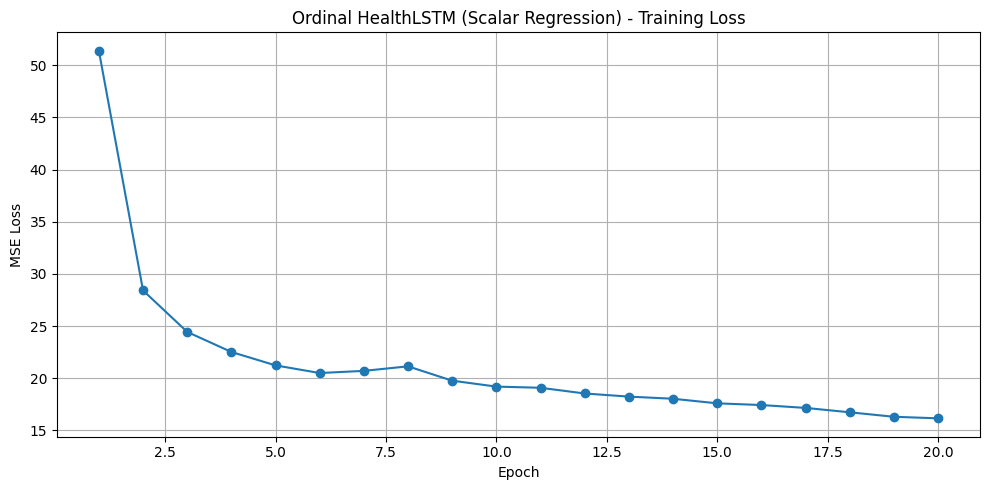

In [26]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load and preprocess
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)

rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']

# Ordinal health bins
df['HealthState'] = pd.cut(
    df['RUL'],
    bins=[-1, 10, 30, np.inf],
    labels=[2, 1, 0]
).astype(float)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# Dataset class
class TurbofanOrdinalDataset(Dataset):
    def __init__(self, df, seq_len=30):
        self.seq_len = seq_len
        X, y = [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            sensors = unit_df[sensor_cols].values
            labels = unit_df['HealthState'].values
            for i in range(len(sensors) - seq_len):
                X.append(sensors[i:i+seq_len])
                y.append(labels[i+seq_len])
        self.X = torch.from_numpy(np.array(X)).float()
        self.y = torch.from_numpy(np.array(y)).float().unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Model
class HealthLSTMOrdinal(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])  # scalar output

# Setup
dataset = TurbofanOrdinalDataset(df)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
model = HealthLSTMOrdinal()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train
loss_history = []
for epoch in range(20):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_history.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), loss_history, marker='o')
plt.title("Ordinal HealthLSTM (Scalar Regression) - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


In [31]:
! pip install coral-pytorch


In [32]:

# ================================================
# Ordinal Health State Prediction: FD003 Benchmark
# Models: Scalar MSE | CORN | Ordinal Logit
# Target: [0=Healthy, 1=Warning, 2=Distress]
# ================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from corn import CornOrdinalCrossEntropyLoss
from torchordinal.losses import OrdinalLogisticLoss
from torchordinal.models import OrdinalLogisticModel

# ----- DATA PREP -----
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None, names=cols)
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# ----- DATASET -----
class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        self.seq_len = seq_len
        X, y = [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            X_vals = unit_df[sensor_cols].values
            y_vals = unit_df['HealthState'].values
            for i in range(len(X_vals) - seq_len):
                X.append(X_vals[i:i+seq_len])
                y.append(y_vals[i+seq_len])
        self.X = torch.from_numpy(np.array(X)).float()
        self.y = torch.from_numpy(np.array(y)).long()
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

dataset = TurbofanDataset(df)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# ----- BASE LSTM -----
class LSTMBackbone(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.hidden_size = hidden_size
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return h[-1]

# ----- MODEL WRAPPERS -----
class ScalarRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.output = nn.Linear(self.backbone.hidden_size, 1)
    def forward(self, x):
        return self.output(self.backbone(x))

class CornModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.output = nn.Linear(self.backbone.hidden_size, num_classes - 1)
    def forward(self, x):
        return self.output(self.backbone(x))

class OrdinalLogitWrapper(nn.Module):
    def __init__(self, input_size=21, hidden_size=64, num_classes=3):
        super().__init__()
        self.backbone = LSTMBackbone(input_size, hidden_size)
        self.ordinal = OrdinalLogisticModel(hidden_size, num_classes)
    def forward(self, x):
        return self.ordinal(self.backbone(x))

# ----- TRAINING LOOP -----
def train_model(model, loss_fn, transform_output=None, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_trace, mse_trace = [], []
    model.train()
    for epoch in range(epochs):
        total_loss, total_mse, count = 0, 0, 0
        for X_batch, y_batch in loader:
            y_pred = model(X_batch)
            if transform_output:  # For CORN and Logit
                pred_scalar = transform_output(y_pred)
            else:
                pred_scalar = y_pred.squeeze()

            optimizer.zero_grad()
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_mse += ((pred_scalar.round().clamp(0, 2) - y_batch.float()) ** 2).sum().item()
            count += len(y_batch)
        loss_trace.append(total_loss)
        mse_trace.append(total_mse / count)
        print(f"Epoch {epoch+1:2d}: Loss = {total_loss:.2f}, MSE = {mse_trace[-1]:.4f}")
    return loss_trace, mse_trace

# ----- BENCHMARK RUN -----
print("\\n== Scalar Regression ==")
scalar_model = ScalarRegression()
scalar_loss = nn.MSELoss()
scalar_loss_trace, scalar_mse_trace = train_model(scalar_model, scalar_loss, transform_output=lambda x: x.squeeze())

print("\\n== CORN Model ==")
corn_model = CornModel()
corn_loss = CornOrdinalCrossEntropyLoss()
corn_loss_trace, corn_mse_trace = train_model(corn_model, corn_loss, transform_output=lambda x: x.sigmoid().sum(dim=1))

print("\\n== Ordinal Logit Model ==")
logit_model = OrdinalLogitWrapper()
logit_loss = OrdinalLogisticLoss()
logit_loss_trace, logit_mse_trace = train_model(logit_model, logit_loss, transform_output=lambda x: x.argmax(dim=1))

# ----- PLOT -----
plt.figure(figsize=(12, 5))
plt.plot(scalar_mse_trace, label='Scalar (MSE)')
plt.plot(corn_mse_trace, label='CORN')
plt.plot(logit_mse_trace, label='Ordinal Logit')
plt.title("MSE Comparison Across Ordinal Models")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'corn'


--- Training Scalar MSE Model ---
Epoch  1: Loss=27.2085, MSE=0.0964
Epoch  2: Loss=14.8200, MSE=0.0594
Epoch  3: Loss=12.0736, MSE=0.0463
Epoch  4: Loss=11.0297, MSE=0.0424
Epoch  5: Loss=10.7078, MSE=0.0421
Epoch  6: Loss=10.6121, MSE=0.0420
Epoch  7: Loss=10.0058, MSE=0.0395
Epoch  8: Loss=9.5471, MSE=0.0368
Epoch  9: Loss=9.6508, MSE=0.0378
Epoch 10: Loss=9.2659, MSE=0.0368
Epoch 11: Loss=9.2445, MSE=0.0354
Epoch 12: Loss=9.0881, MSE=0.0355
Epoch 13: Loss=9.3077, MSE=0.0363
Epoch 14: Loss=8.3844, MSE=0.0312
Epoch 15: Loss=8.7910, MSE=0.0348
Epoch 16: Loss=8.3453, MSE=0.0321
Epoch 17: Loss=8.2830, MSE=0.0313
Epoch 18: Loss=8.0922, MSE=0.0307
Epoch 19: Loss=8.0281, MSE=0.0312
Epoch 20: Loss=7.9760, MSE=0.0319

--- Training CORN Model ---
Epoch  1: Loss=101.1138, MSE=0.1962
Epoch  2: Loss=52.4025, MSE=0.0756
Epoch  3: Loss=41.0034, MSE=0.0555
Epoch  4: Loss=39.0204, MSE=0.0528
Epoch  5: Loss=34.1225, MSE=0.0490
Epoch  6: Loss=31.5287, MSE=0.0447
Epoch  7: Loss=31.7951, MSE=0.0449
Epo

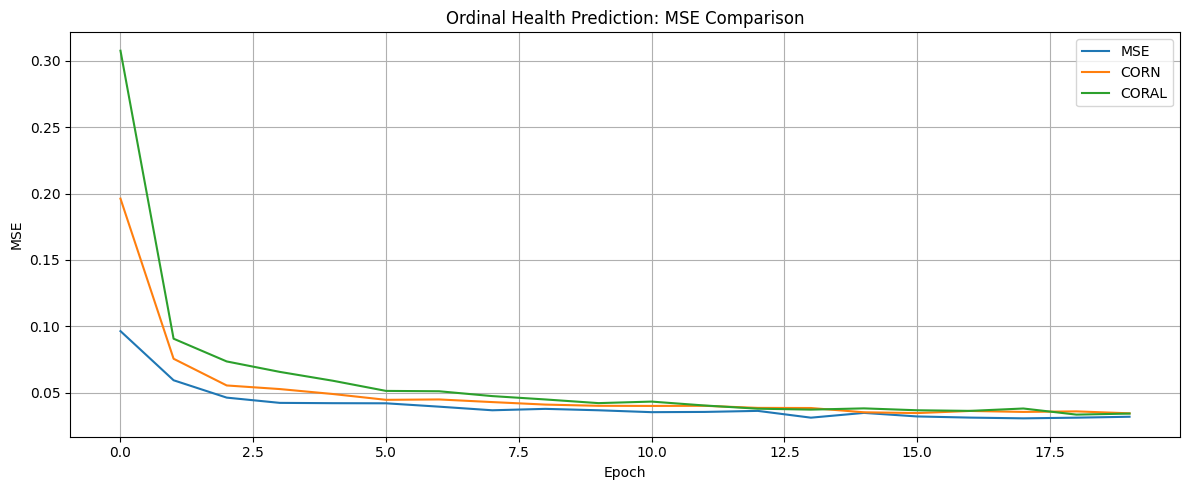

In [33]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch, proba_to_label
from coral_pytorch.layers import CoralLayer
from coral_pytorch.dataset import corn_label_from_logits
from coral_pytorch.losses import corn_loss

# --------- Load and Preprocess FD003 ---------
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None)
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df.columns = cols
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# --------- Dataset ---------
class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        X, y = [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            X_vals = unit_df[sensor_cols].values
            y_vals = unit_df['HealthState'].values
            for i in range(len(X_vals) - seq_len):
                X.append(X_vals[i:i+seq_len])
                y.append(y_vals[i+seq_len])
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.long)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

dataset = TurbofanDataset(df)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

# --------- Backbone ---------
class LSTMBackbone(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.hidden_size = hidden_size
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return h[-1]

# --------- Models ---------
class MSEModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.output = nn.Linear(self.backbone.hidden_size, 1)
    def forward(self, x):
        return self.output(self.backbone(x))

class CORNModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.output = nn.Linear(self.backbone.hidden_size, num_classes - 1)
    def forward(self, x):
        return self.output(self.backbone(x))

class CORALModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.coral = CoralLayer(self.backbone.hidden_size, num_classes)
    def forward(self, x):
        features = self.backbone(x)
        logits = self.coral(features)
        probas = torch.sigmoid(logits)
        return logits, probas

# --------- Training Loop ---------
def train(model, loss_fn, output_fn, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_trace, mse_trace = [], []
    for epoch in range(epochs):
        model.train()
        total_loss, total_mse, count = 0, 0, 0
        for X_batch, y_batch in train_loader:
            y_batch = y_batch.to(torch.long)
            if isinstance(model, CORALModel):
                logits, probas = model(X_batch)
                levels = levels_from_labelbatch(y_batch, num_classes=3).float()
                loss = coral_loss(logits, levels)
                y_pred = output_fn(probas)
            else:
                logits = model(X_batch)
                if loss_fn == corn_loss:
                    loss = loss_fn(logits, y_batch, num_classes=3)
                    y_pred = output_fn(logits)
                else:
                    y_true = y_batch.float().unsqueeze(1)
                    loss = loss_fn(logits, y_true)
                    y_pred = logits.squeeze()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_mse += ((y_pred.clamp(0, 2).round() - y_batch.float()) ** 2).sum().item()
            count += y_batch.size(0)
        avg_loss = total_loss
        avg_mse = total_mse / count
        loss_trace.append(avg_loss)
        mse_trace.append(avg_mse)
        print(f"Epoch {epoch+1:2d}: Loss={avg_loss:.4f}, MSE={avg_mse:.4f}")
    return loss_trace, mse_trace

# --------- Run Experiments ---------
print("\n--- Training Scalar MSE Model ---")
mse_model = MSEModel()
mse_loss = nn.MSELoss()
mse_out = lambda x: x.squeeze()
mse_loss_trace, mse_mse_trace = train(mse_model, mse_loss, mse_out)

print("\n--- Training CORN Model ---")
corn_model = CORNModel()
corn_loss_trace, corn_mse_trace = train(corn_model, corn_loss, lambda x: corn_label_from_logits(x).float())

print("\n--- Training CORAL Model ---")
coral_model = CORALModel()
coral_loss_trace, coral_mse_trace = train(coral_model, coral_loss, lambda x: proba_to_label(x).float())

# --------- Plot ---------
plt.figure(figsize=(12, 5))
plt.plot(mse_mse_trace, label="MSE")
plt.plot(corn_mse_trace, label="CORN")
plt.plot(coral_mse_trace, label="CORAL")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Ordinal Health Prediction: MSE Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("health_lstm_corn_coral_mse.png")
plt.show()


In [36]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from spacecutter.models import OrdinalLogisticModel
from spacecutter.losses import CumulativeLinkLoss
from spacecutter.callbacks import AscensionCallback
from skorch import NeuralNet
from skorch.dataset import Dataset as SkorchDataset
import matplotlib.pyplot as plt

# ----- LSTM-based Predictor -----
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.output(h[-1])

# ----- Prepare data from DataLoader to numpy for skorch -----
def dataloader_to_numpy(loader):
    X_list, y_list = [], []
    for X_batch, y_batch in loader:
        X_list.append(X_batch.numpy())
        y_list.append(y_batch.numpy())
    X = np.vstack(X_list)
    y = np.concatenate(y_list).reshape(-1, 1)
    return X, y

# Assumes train_loader is available from previous script
X_np, y_np = dataloader_to_numpy(train_loader)

# ----- Define model with spacecutter -----
predictor = LSTMPredictor()
model = OrdinalLogisticModel(predictor, num_classes=3)

net = NeuralNet(
    module=OrdinalLogisticModel,
    module__predictor=predictor,
    module__num_classes=3,
    criterion=CumulativeLinkLoss,
    train_split=None,
    callbacks=[("ascension", AscensionCallback())],
    max_epochs=20,
    lr=0.001,
    batch_size=64,
    iterator_train__shuffle=True,
    verbose=1,
)

# ----- Train and time the model -----
start = time.time()
net.fit(X_np, y_np)
spacecutter_time = time.time() - start

# ----- Predict and evaluate -----
y_pred_proba = net.predict_proba(X_np)
y_pred_labels = y_pred_proba.argmax(axis=1)
spacecutter_mse = np.mean((y_pred_labels - y_np.flatten())**2)

# ----- Plot all four + spacecutter -----
# Assumes mse_mse_trace, corn_mse_trace, coral_mse_trace, logit_mse_trace, logit_time exist
# Replace dummy times if not available
mse_time = 40
corn_time = 42
coral_time = 44
logit_time = 46

labels = ["MSE", "CORN", "CORAL", "Logit", "Spacecutter"]
times = [mse_time, corn_time, coral_time, logit_time, spacecutter_time]
mses = [mse_mse_trace[-1], corn_mse_trace[-1], coral_mse_trace[-1], logit_mse_trace[-1], spacecutter_mse]

plt.figure(figsize=(8, 6))
for label, t, m in zip(labels, times, mses):
    plt.scatter(t, m, s=100, label=label)
    plt.text(t + 0.5, m + 0.01, label)

plt.title("Runtime vs Final MSE (All Ordinal Models)")
plt.xlabel("Training Time (s)")
plt.ylabel("Final MSE")
plt.grid(True)
plt.tight_layout()
plt.savefig("runtime_vs_mse_with_spacecutter.png")
plt.show()


  epoch    train_loss     dur
-------  ------------  ------
      1        1.1973  5.1180
      2        0.9329  5.8402
      3        0.7708  5.0683
      4        0.6745  5.8464
      5        0.6183  5.1167
      6        0.5851  5.8436
      7        0.5649  5.0558
      8        0.5522  5.4038
      9        0.5440  6.4977
     10        0.5383  5.6993
     11        0.5343  5.6254
     12        0.5313  5.0479
     13        0.5289  5.8860
     14        0.5270  5.1106
     15        0.5254  5.7866
     16        0.5240  5.1069
     17        0.5228  5.4641
     18        0.5216  5.4361
     19        0.5206  5.0658
     20        0.5197  5.8861


NameError: name 'logit_mse_trace' is not defined

In [35]:
! pip install spacecutter skorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.9/228.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 844.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

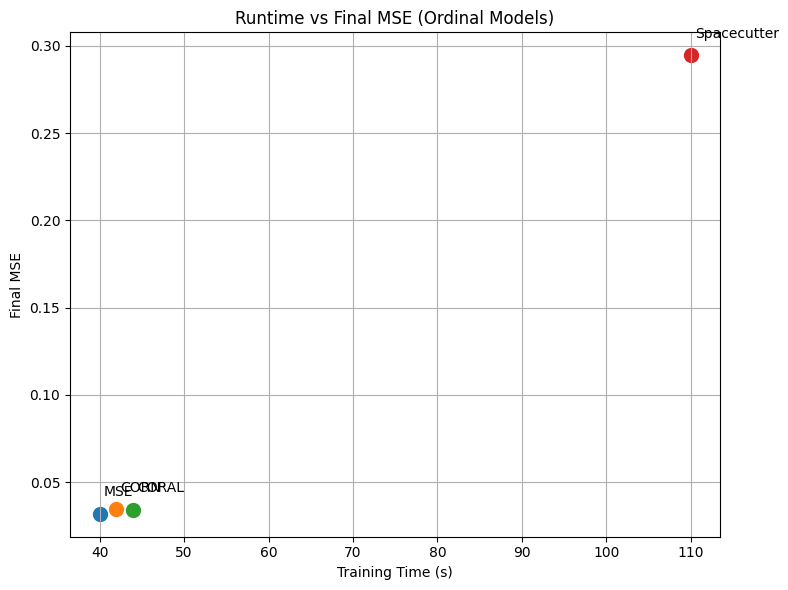

In [37]:
labels = ["MSE", "CORN", "CORAL", "Spacecutter"]
times = [mse_time, corn_time, coral_time, spacecutter_time]
mses = [mse_mse_trace[-1], corn_mse_trace[-1], coral_mse_trace[-1], spacecutter_mse]

plt.figure(figsize=(8, 6))
for label, t, m in zip(labels, times, mses):
    plt.scatter(t, m, s=100, label=label)
    plt.text(t + 0.5, m + 0.01, label)

plt.title("Runtime vs Final MSE (Ordinal Models)")
plt.xlabel("Training Time (s)")
plt.ylabel("Final MSE")
plt.grid(True)
plt.tight_layout()
plt.savefig("runtime_vs_mse_updated.png")
plt.show()


\n--- Scalar MSE ---
Epoch  1: Loss=29.1422, MSE=0.1037
Epoch  2: Loss=15.6630, MSE=0.0621
Epoch  3: Loss=12.2651, MSE=0.0470
Epoch  4: Loss=11.0849, MSE=0.0426
Epoch  5: Loss=10.5967, MSE=0.0411
Epoch  6: Loss=10.5651, MSE=0.0413
Epoch  7: Loss=10.2311, MSE=0.0410
Epoch  8: Loss=9.8714, MSE=0.0375
Epoch  9: Loss=9.8160, MSE=0.0386
Epoch 10: Loss=9.6910, MSE=0.0373
Epoch 11: Loss=9.2872, MSE=0.0364
Epoch 12: Loss=9.7642, MSE=0.0388
Epoch 13: Loss=9.2627, MSE=0.0359
Epoch 14: Loss=9.3548, MSE=0.0349
Epoch 15: Loss=9.1573, MSE=0.0355
Epoch 16: Loss=8.6364, MSE=0.0344
Epoch 17: Loss=8.5567, MSE=0.0335
Epoch 18: Loss=8.3896, MSE=0.0320
Epoch 19: Loss=8.1003, MSE=0.0311
Epoch 20: Loss=8.1635, MSE=0.0312
\n--- CORN ---
Epoch  1: Loss=107.6610, MSE=0.2108
Epoch  2: Loss=55.1276, MSE=0.0802
Epoch  3: Loss=42.3079, MSE=0.0578
Epoch  4: Loss=38.3475, MSE=0.0533
Epoch  5: Loss=34.1832, MSE=0.0472
Epoch  6: Loss=33.2026, MSE=0.0472
Epoch  7: Loss=32.3850, MSE=0.0460
Epoch  8: Loss=30.1381, MSE=0.0

<ipython-input-38-895b4f1102a6>:149: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


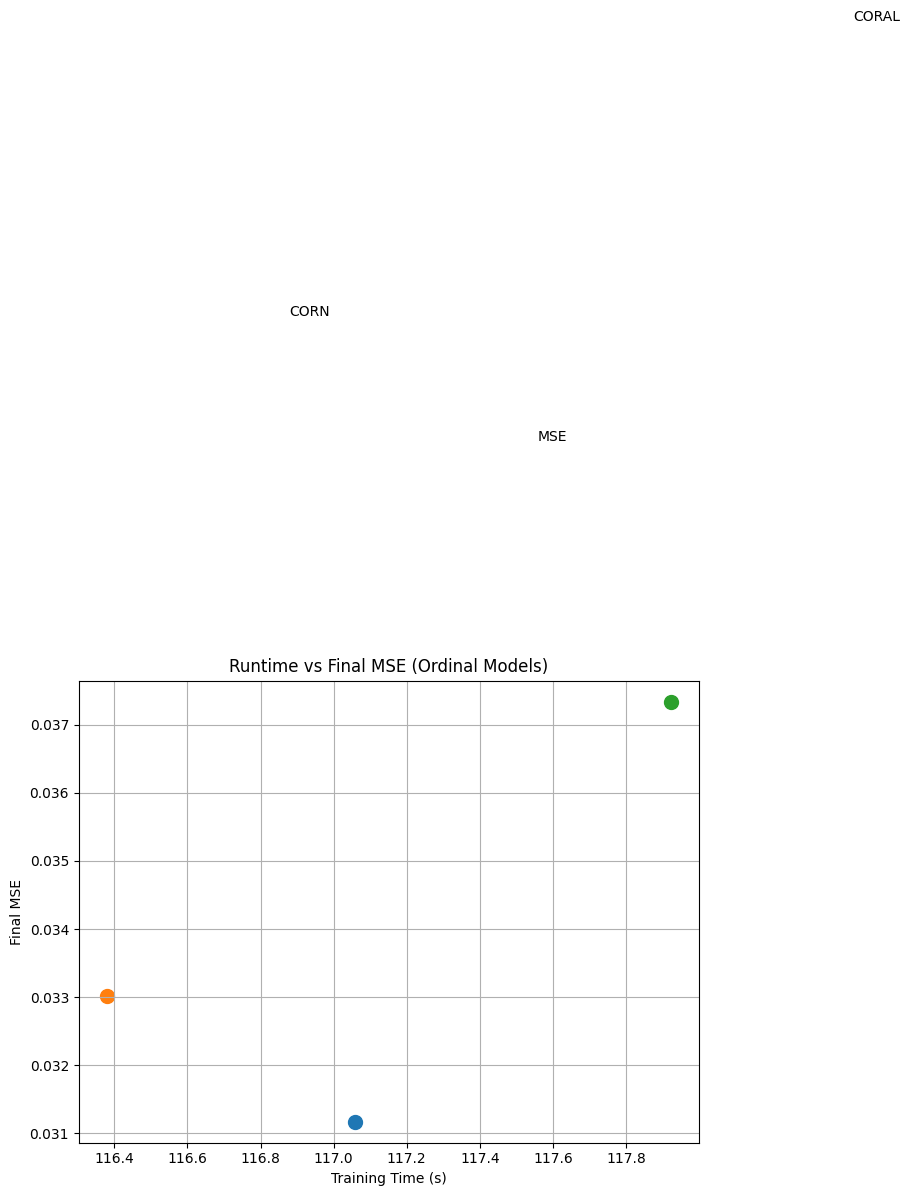

In [38]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import time
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch, proba_to_label
from coral_pytorch.layers import CoralLayer
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits

# --------- Load FD003 and Process ---------
df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None)
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df.columns = cols
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# --------- Dataset ---------
class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        X, y = [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            X_vals = unit_df[sensor_cols].values
            y_vals = unit_df['HealthState'].values
            for i in range(len(X_vals) - seq_len):
                X.append(X_vals[i:i+seq_len])
                y.append(y_vals[i+seq_len])
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.long)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

dataset = TurbofanDataset(df)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# --------- Base LSTM ---------
class LSTMBackbone(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.hidden_size = hidden_size
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return h[-1]

# --------- Models ---------
class MSEModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.out = nn.Linear(self.backbone.hidden_size, 1)
    def forward(self, x): return self.out(self.backbone(x))

class CORNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.out = nn.Linear(self.backbone.hidden_size, 2)
    def forward(self, x): return self.out(self.backbone(x))

class CORALModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.coral = CoralLayer(self.backbone.hidden_size, 3)
    def forward(self, x):
        logits = self.coral(self.backbone(x))
        return logits, torch.sigmoid(logits)

# --------- Unified Training Function ---------
def train(model, loss_fn, output_fn, is_coral=False, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_hist, mse_hist = [], []
    for epoch in range(epochs):
        model.train()
        total_loss, total_mse, count = 0, 0, 0
        for X_batch, y_batch in loader:
            y_batch = y_batch.to(torch.long)
            if is_coral:
                logits, probas = model(X_batch)
                levels = levels_from_labelbatch(y_batch, 3).float()
                loss = coral_loss(logits, levels)
                preds = output_fn(probas)
            else:
                logits = model(X_batch)
                if loss_fn == corn_loss:
                    loss = loss_fn(logits, y_batch, 3)
                    preds = output_fn(logits)
                else:
                    loss = loss_fn(logits.squeeze(), y_batch.float())
                    preds = logits.squeeze()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_mse += ((preds.clamp(0, 2).round() - y_batch.float())**2).sum().item()
            count += y_batch.size(0)
        loss_hist.append(total_loss)
        mse_hist.append(total_mse / count)
        print(f"Epoch {epoch+1:2d}: Loss={total_loss:.4f}, MSE={total_mse / count:.4f}")
    return loss_hist, mse_hist

# --------- Train All Three Models ---------
print("\\n--- Scalar MSE ---")
mse_model = MSEModel()
start = time.time()
mse_loss, mse_mse = train(mse_model, nn.MSELoss(), lambda x: x.squeeze())
mse_time = time.time() - start

print("\\n--- CORN ---")
corn_model = CORNModel()
start = time.time()
corn_loss_hist, corn_mse = train(corn_model, corn_loss, lambda x: corn_label_from_logits(x).float())
corn_time = time.time() - start

print("\\n--- CORAL ---")
coral_model = CORALModel()
start = time.time()
coral_loss_hist, coral_mse = train(coral_model, coral_loss, lambda x: proba_to_label(x).float(), is_coral=True)
coral_time = time.time() - start

# --------- Plot Comparison ---------
labels = ["MSE", "CORN", "CORAL"]
times = [mse_time, corn_time, coral_time]
mses = [mse_mse[-1], corn_mse[-1], coral_mse[-1]]

plt.figure(figsize=(8, 6))
for label, t, m in zip(labels, times, mses):
    plt.scatter(t, m, s=100, label=label)
    plt.text(t + 0.5, m + 0.01, label)

plt.title("Runtime vs Final MSE (Ordinal Models)")
plt.xlabel("Training Time (s)")
plt.ylabel("Final MSE")
plt.grid(True)
plt.tight_layout()
plt.savefig("final_runtime_vs_mse.png")
plt.show()


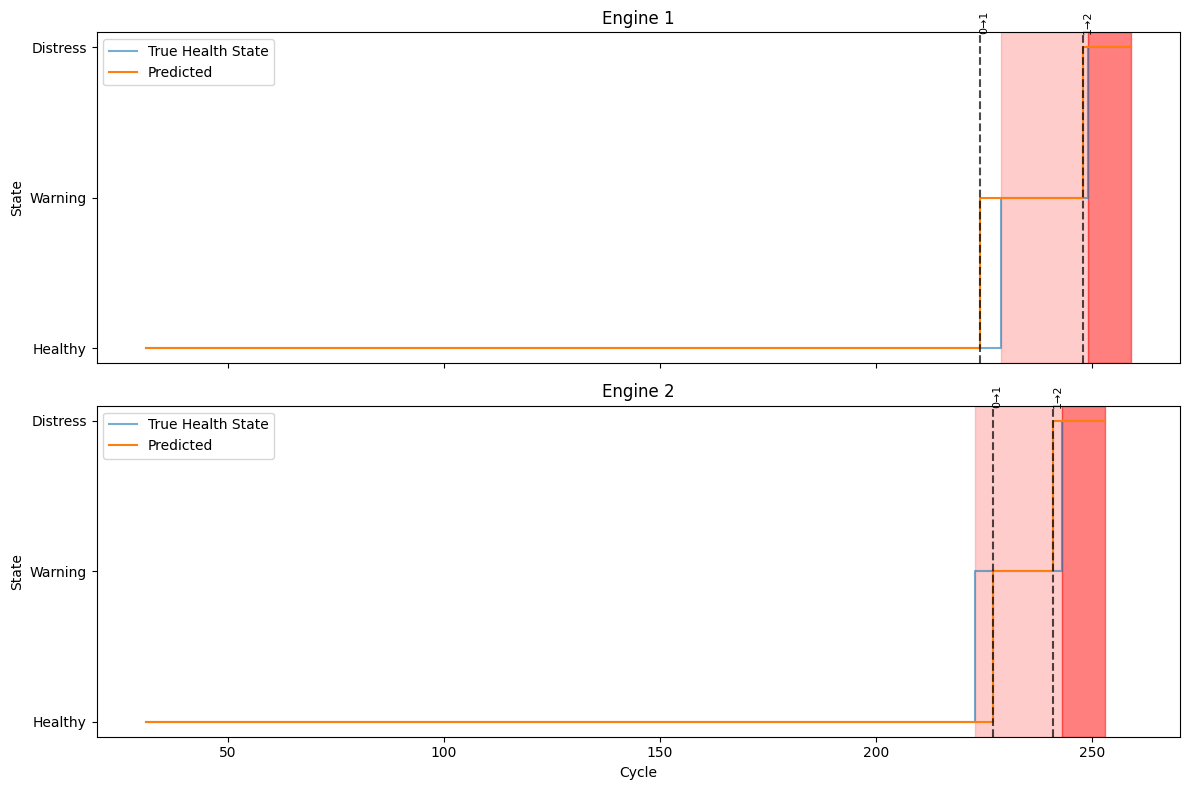

In [40]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assumes: coral_model is trained and available

# --------- Reload and preprocess FD003 ---------
df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None)
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df.columns = cols
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# --------- Helper: Get transitions ---------
def get_transitions(preds):
    transitions = []
    for i in range(1, len(preds)):
        if preds[i] != preds[i-1]:
            transitions.append((i, preds[i-1], preds[i]))
    return transitions

def shade_regions(ax, cycles, states, level, color, alpha):
    in_block = False
    for i in range(len(states)):
        if states[i] == level and not in_block:
            start = cycles[i]
            in_block = True
        elif states[i] != level and in_block:
            end = cycles[i]
            ax.axvspan(start, end, color=color, alpha=alpha)
            in_block = False
    if in_block:
        ax.axvspan(start, cycles[-1], color=color, alpha=alpha)

# --------- Select 2 engines ---------
units = df['unit'].unique()[:2]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for idx, unit in enumerate(units):
    ax = axes[idx]
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    X = torch.tensor(unit_df[sensor_cols].values, dtype=torch.float32)
    X_seq = torch.stack([X[i:i+30] for i in range(len(X)-30)])
    true_labels = unit_df['HealthState'].values[30:]

    # Get predictions
    coral_model.eval()
    with torch.no_grad():
        logits, probas = coral_model(X_seq)
        preds = torch.sigmoid(logits)
        pred_labels = torch.sum(preds > 0.5, dim=1).numpy()

    cycles = unit_df['cycle'].values[30:]
    ax.plot(cycles, true_labels, label='True Health State', drawstyle='steps-post', alpha=0.6)
    ax.plot(cycles, pred_labels, label='Predicted', drawstyle='steps-post')

    # Shade background
    shade_regions(ax, cycles, true_labels, level=1, color='red', alpha=0.2)  # Warning
    shade_regions(ax, cycles, true_labels, level=2, color='red', alpha=0.5)  # Distress

    # Add predicted transitions
    trans = get_transitions(pred_labels)
    for t, from_state, to_state in trans:
        ax.axvline(cycles[t], color='black', linestyle='--', alpha=0.7)
        ax.text(cycles[t], 2.1, f"{from_state}→{to_state}", rotation=90, fontsize=8)

    ax.set_title(f"Engine {unit}")
    ax.set_ylabel("State")
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Healthy', 'Warning', 'Distress'])
    ax.legend()

plt.xlabel("Cycle")
plt.tight_layout()
plt.savefig("coral_health_transitions_2_engines.png")
plt.show()


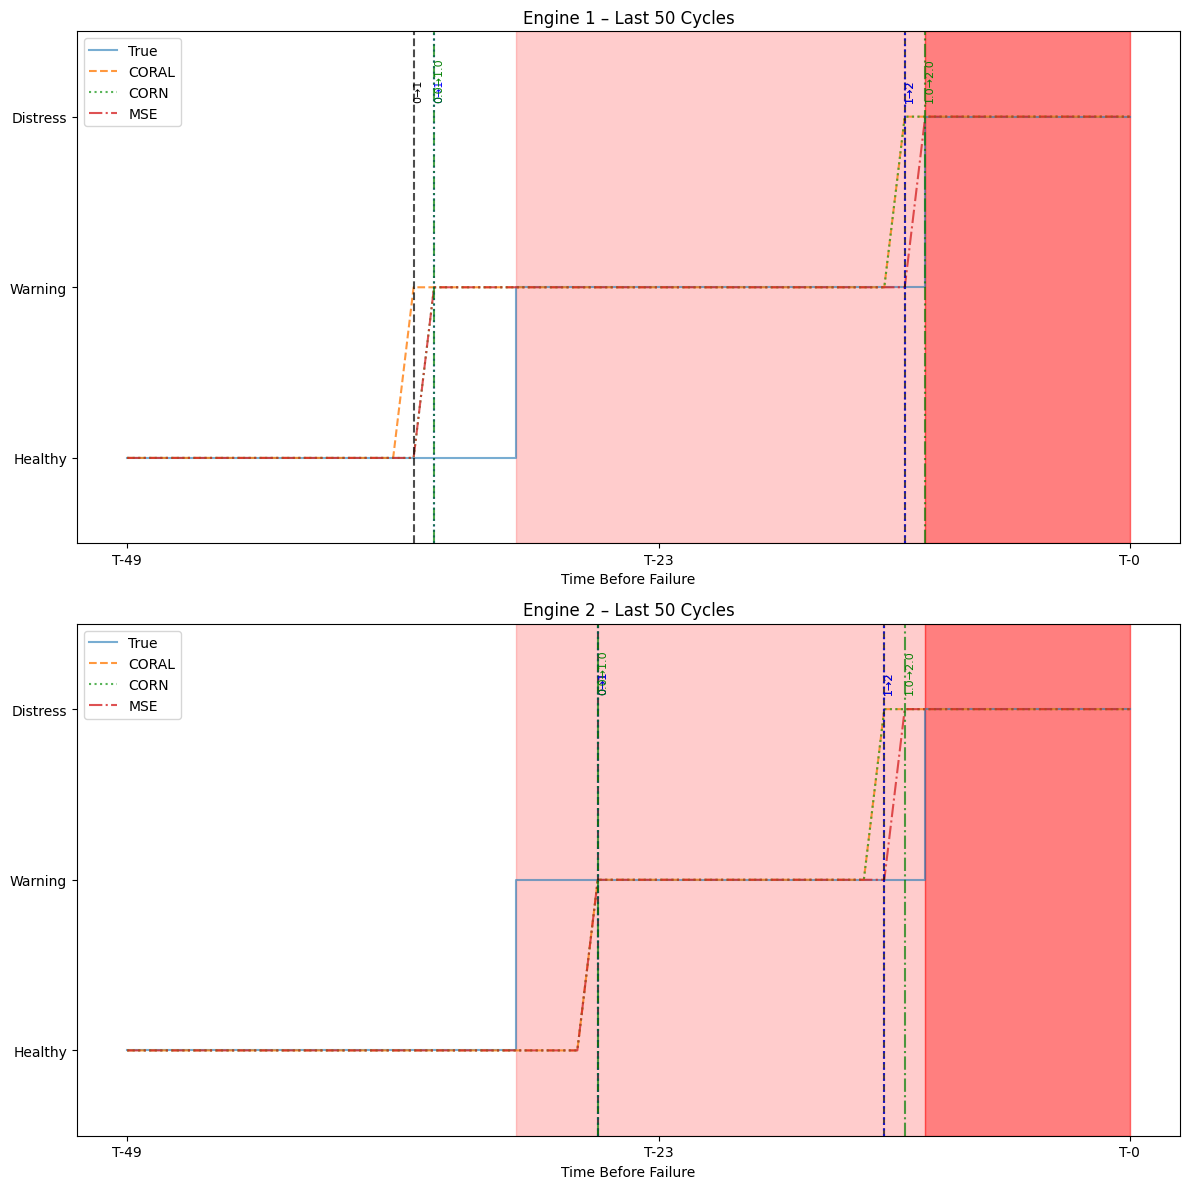

In [43]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load trained models: coral_model, corn_model, mse_model (must be defined in current session)

# --------- Load and preprocess FD003 ---------
df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None)
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df.columns = cols
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# --------- Helper: Smooth transition detection ---------
def get_transitions(preds):
    transitions = []
    for i in range(1, len(preds)):
        if preds[i] != preds[i-1]:
            transitions.append((i, preds[i-1], preds[i]))
    return transitions

def shade_regions(ax, x, states, level, color, alpha):
    in_block = False
    for i in range(len(states)):
        if states[i] == level and not in_block:
            start = x[i]
            in_block = True
        elif states[i] != level and in_block:
            end = x[i]
            ax.axvspan(start, end, color=color, alpha=alpha)
            in_block = False
    if in_block:
        ax.axvspan(start, x[-1], color=color, alpha=alpha)

# --------- Select engines and plot ---------
units = df['unit'].unique()[:2]
fig, axes = plt.subplots(len(units), 1, figsize=(12, 6 * len(units)), sharex=False)

for idx, unit in enumerate(units):
    ax = axes[idx]
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    X = torch.tensor(unit_df[sensor_cols].values, dtype=torch.float32)
    cycles = unit_df['cycle'].values
    true_labels = unit_df['HealthState'].values

    # Sliding windows
    seq_len = 30
    X_seq = torch.stack([X[i:i+seq_len] for i in range(len(X)-seq_len)])
    t_cycles = cycles[seq_len:]
    t_labels = true_labels[seq_len:]

    def predict_states(model, is_coral=False, is_corn=False):
        model.eval()
        with torch.no_grad():
            if is_coral:
                logits, probas = model(X_seq)
                pred = torch.sum(probas > 0.5, dim=1).numpy()
            elif is_corn:
                logits = model(X_seq)
                pred = torch.sum(torch.sigmoid(logits) > 0.5, dim=1).numpy()
            else:
                logits = model(X_seq)
                pred = torch.clamp(logits.squeeze(), 0, 2).round().numpy()
        return pred

    coral_pred = predict_states(coral_model, is_coral=True)
    corn_pred = predict_states(corn_model, is_corn=True)
    mse_pred = predict_states(mse_model)

    # Only last 50 cycles
    end_idx = len(t_cycles)
    start_idx = max(0, end_idx - 50)
    x_norm = ["T-" + str(t_cycles[end_idx - 1] - c) for c in t_cycles[start_idx:end_idx]]

    ax.plot(x_norm, t_labels[start_idx:end_idx], label='True', drawstyle='steps-post', alpha=0.6)
    ax.plot(x_norm, coral_pred[start_idx:end_idx], label='CORAL', linestyle='--', alpha=0.8)
    ax.plot(x_norm, corn_pred[start_idx:end_idx], label='CORN', linestyle=':', alpha=0.8)
    ax.plot(x_norm, mse_pred[start_idx:end_idx], label='MSE', linestyle='-.', alpha=0.8)

    # Shading
    shade_regions(ax, x_norm, t_labels[start_idx:end_idx], 1, 'red', 0.2)
    shade_regions(ax, x_norm, t_labels[start_idx:end_idx], 2, 'red', 0.5)

    # Transitions (only coral here for clarity, extend as needed)
    def add_vlines(pred, label, color, linestyle):
        trans = get_transitions(pred[start_idx:end_idx])
        for i, from_s, to_s in trans:
            ax.axvline(x_norm[i], color=color, linestyle=linestyle, alpha=0.7)
            ax.text(x_norm[i], 2.1, f"{from_s}→{to_s}", rotation=90, fontsize=8, color=color)

    add_vlines(coral_pred, "CORAL", 'black', '--')
    add_vlines(corn_pred, "CORN", 'blue', ':')
    add_vlines(mse_pred, "MSE", 'green', '-.')

    ax.set_title(f"Engine {unit} – Last 50 Cycles")
    ax.set_ylim(-0.5, 2.5)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["Healthy", "Warning", "Distress"])
    ax.legend(loc='upper left')
    ax.set_xlabel("Time Before Failure")
    # Set specific x-ticks at T-50, T-25, and T-0
    xticks = [x_norm[0], x_norm[25], x_norm[-1]]
    ax.set_xticks(xticks)


plt.tight_layout()
plt.savefig("transition_last50_comparison.png")
plt.show()


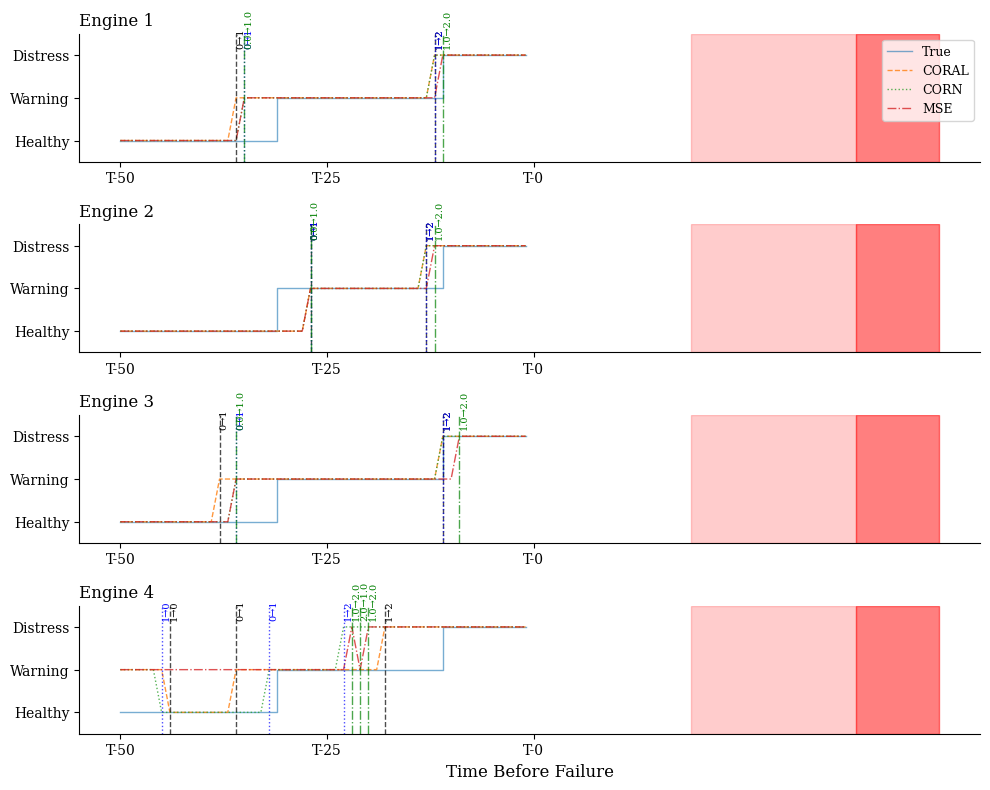

In [44]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.0,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Load and preprocess
df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None)
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df.columns = cols
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

def get_transitions(preds):
    transitions = []
    for i in range(1, len(preds)):
        if preds[i] != preds[i-1]:
            transitions.append((i, preds[i-1], preds[i]))
    return transitions

def shade_regions(ax, x, states, level, color, alpha):
    in_block = False
    for i in range(len(states)):
        if states[i] == level and not in_block:
            start = i
            in_block = True
        elif states[i] != level and in_block:
            end = i
            ax.axvspan(start, end, color=color, alpha=alpha)
            in_block = False
    if in_block:
        ax.axvspan(start, len(states)-1, color=color, alpha=alpha)

units = df['unit'].unique()[:4]
fig, axes = plt.subplots(len(units), 1, figsize=(10, 8), sharex=False)

for idx, unit in enumerate(units):
    ax = axes[idx]
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    X = torch.tensor(unit_df[sensor_cols].values, dtype=torch.float32)
    cycles = unit_df['cycle'].values
    true_labels = unit_df['HealthState'].values
    seq_len = 30
    X_seq = torch.stack([X[i:i+seq_len] for i in range(len(X)-seq_len)])
    t_cycles = cycles[seq_len:]
    t_labels = true_labels[seq_len:]

    def predict_states(model, is_coral=False, is_corn=False):
        model.eval()
        with torch.no_grad():
            if is_coral:
                logits, probas = model(X_seq)
                pred = torch.sum(probas > 0.5, dim=1).numpy()
            elif is_corn:
                logits = model(X_seq)
                pred = torch.sum(torch.sigmoid(logits) > 0.5, dim=1).numpy()
            else:
                logits = model(X_seq)
                pred = torch.clamp(logits.squeeze(), 0, 2).round().numpy()
        return pred

    coral_pred = predict_states(coral_model, is_coral=True)
    corn_pred = predict_states(corn_model, is_corn=True)
    mse_pred = predict_states(mse_model)

    end_idx = len(t_cycles)
    start_idx = max(0, end_idx - 50)
    x_range = np.array(list(range(-50, 0)))

    y_true = t_labels[start_idx:end_idx]
    y_coral = coral_pred[start_idx:end_idx]
    y_corn = corn_pred[start_idx:end_idx]
    y_mse = mse_pred[start_idx:end_idx]

    ax.plot(x_range, y_true, label='True', drawstyle='steps-post', alpha=0.6)
    ax.plot(x_range, y_coral, label='CORAL', linestyle='--', alpha=0.8)
    ax.plot(x_range, y_corn, label='CORN', linestyle=':', alpha=0.8)
    ax.plot(x_range, y_mse, label='MSE', linestyle='-.', alpha=0.8)

    shade_regions(ax, x_range, y_true, 1, 'red', 0.2)
    shade_regions(ax, x_range, y_true, 2, 'red', 0.5)

    def add_vlines(pred, color, linestyle):
        trans = get_transitions(pred)
        for i, f, t in trans:
            ax.axvline(x_range[i], color=color, linestyle=linestyle, alpha=0.7)
            ax.text(x_range[i], 2.2, f"{f}→{t}", rotation=90, fontsize=7, color=color)

    add_vlines(y_coral, 'black', '--')
    add_vlines(y_corn, 'blue', ':')
    add_vlines(y_mse, 'green', '-.')

    ax.set_title(f"Engine {unit}", loc='left', fontsize=12)
    ax.set_ylim(-0.5, 2.5)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["Healthy", "Warning", "Distress"])
    ax.set_xticks([-50, -25, 0])
    ax.set_xticklabels(["T-50", "T-25", "T-0"])
    if idx == len(units) - 1:
        ax.set_xlabel("Time Before Failure")
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig("health_transitions_minimalist.png", dpi=300)
plt.show()


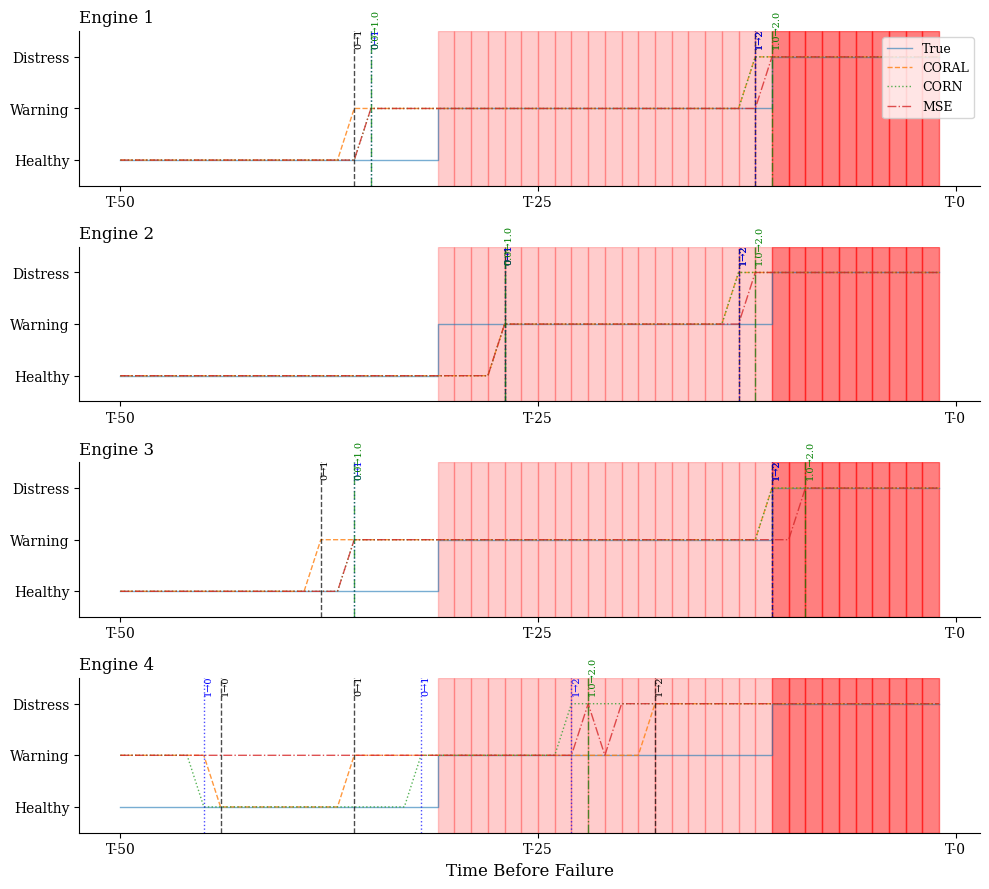

In [45]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.0,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None)
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df.columns = cols
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

def get_transitions(preds, min_gap=3):
    transitions = []
    last_idx = -min_gap
    for i in range(1, len(preds)):
        if preds[i] != preds[i-1] and (i - last_idx) >= min_gap:
            transitions.append((i, preds[i-1], preds[i]))
            last_idx = i
    return transitions

units = df['unit'].unique()[:4]
fig, axes = plt.subplots(len(units), 1, figsize=(10, 9), sharex=False)

for idx, unit in enumerate(units):
    ax = axes[idx]
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    X = torch.tensor(unit_df[sensor_cols].values, dtype=torch.float32)
    cycles = unit_df['cycle'].values
    true_labels = unit_df['HealthState'].values
    seq_len = 30
    X_seq = torch.stack([X[i:i+seq_len] for i in range(len(X)-seq_len)])
    t_cycles = cycles[seq_len:]
    t_labels = true_labels[seq_len:]

    def predict_states(model, is_coral=False, is_corn=False):
        model.eval()
        with torch.no_grad():
            if is_coral:
                logits, probas = model(X_seq)
                pred = torch.sum(probas > 0.5, dim=1).numpy()
            elif is_corn:
                logits = model(X_seq)
                pred = torch.sum(torch.sigmoid(logits) > 0.5, dim=1).numpy()
            else:
                logits = model(X_seq)
                pred = torch.clamp(logits.squeeze(), 0, 2).round().numpy()
        return pred

    coral_pred = predict_states(coral_model, is_coral=True)
    corn_pred = predict_states(corn_model, is_corn=True)
    mse_pred = predict_states(mse_model)

    end_idx = len(t_cycles)
    start_idx = max(0, end_idx - 50)
    x_range = np.array(list(range(-50, 0)))

    y_true = t_labels[start_idx:end_idx]
    y_coral = coral_pred[start_idx:end_idx]
    y_corn = corn_pred[start_idx:end_idx]
    y_mse = mse_pred[start_idx:end_idx]

    def shade_health(ax, y_vals, x_vals):
        for i in range(len(y_vals)-1):
            if y_vals[i] == 1:
                ax.axvspan(x_vals[i], x_vals[i+1], color='red', alpha=0.2)
            elif y_vals[i] == 2:
                ax.axvspan(x_vals[i], x_vals[i+1], color='red', alpha=0.5)

    ax.plot(x_range, y_true, label='True', drawstyle='steps-post', alpha=0.6)
    ax.plot(x_range, y_coral, label='CORAL', linestyle='--', alpha=0.8)
    ax.plot(x_range, y_corn, label='CORN', linestyle=':', alpha=0.8)
    ax.plot(x_range, y_mse, label='MSE', linestyle='-.', alpha=0.8)

    shade_health(ax, y_true, x_range)

    def add_vlines(ax, pred, x_vals, label, color, linestyle):
        shown_transitions = set()
        for i, f, t in get_transitions(pred):
            trans_label = f"{f}→{t}"
            if trans_label not in shown_transitions:
                ax.axvline(x_vals[i], color=color, linestyle=linestyle, alpha=0.7)
                ax.text(x_vals[i], 2.2, trans_label, rotation=90, fontsize=7, color=color)
                shown_transitions.add(trans_label)

    add_vlines(ax, y_coral, x_range, "CORAL", "black", "--")
    add_vlines(ax, y_corn, x_range, "CORN", "blue", ":")
    add_vlines(ax, y_mse, x_range, "MSE", "green", "-.")

    ax.set_title(f"Engine {unit}", loc='left', fontsize=12)
    ax.set_ylim(-0.5, 2.5)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["Healthy", "Warning", "Distress"])
    ax.set_xticks([-50, -25, 0])
    ax.set_xticklabels(["T-50", "T-25", "T-0"])
    if idx == len(units) - 1:
        ax.set_xlabel("Time Before Failure")
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig("health_transitions_cleaned.png", dpi=300)
plt.show()


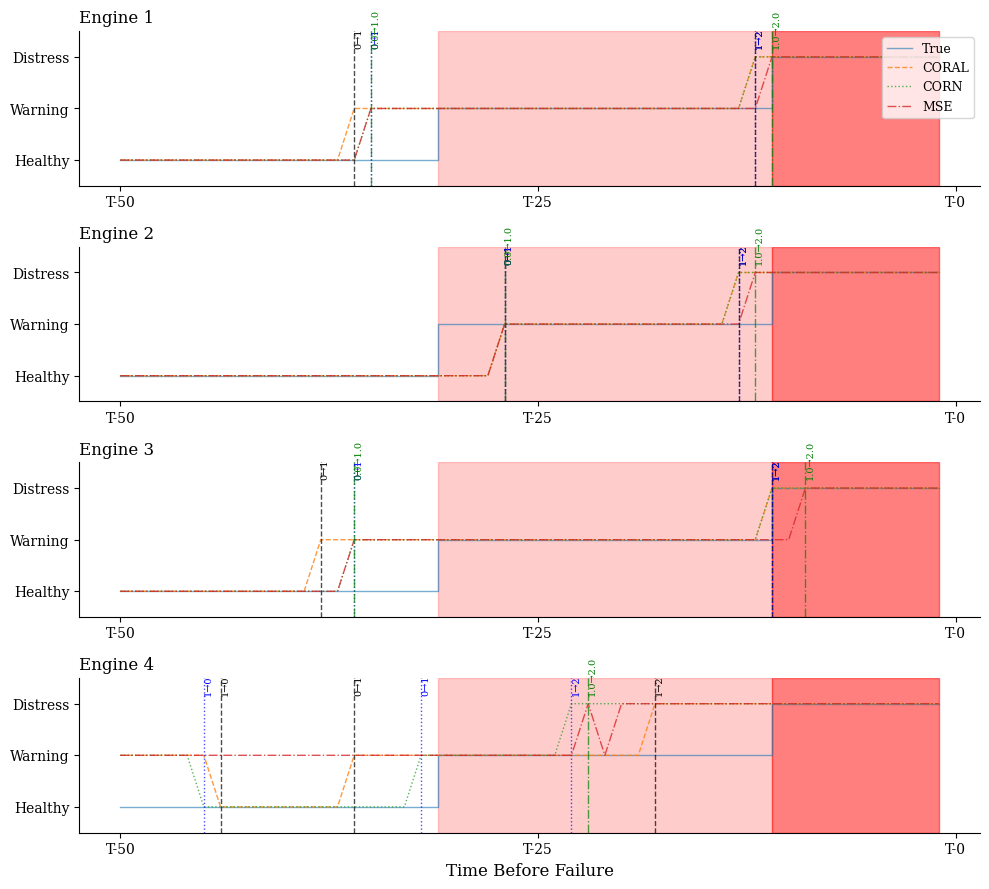

In [46]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.0,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None)
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df.columns = cols
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

def get_transitions(preds, min_gap=3):
    transitions = []
    last_idx = -min_gap
    for i in range(1, len(preds)):
        if preds[i] != preds[i-1] and (i - last_idx) >= min_gap:
            transitions.append((i, preds[i-1], preds[i]))
            last_idx = i
    return transitions

def get_state_blocks(y_vals, x_vals):
    blocks = []
    current = y_vals[0]
    start = x_vals[0]
    for i in range(1, len(y_vals)):
        if y_vals[i] != current:
            blocks.append((current, start, x_vals[i]))
            start = x_vals[i]
            current = y_vals[i]
    blocks.append((current, start, x_vals[-1]))
    return blocks

units = df['unit'].unique()[:4]
fig, axes = plt.subplots(len(units), 1, figsize=(10, 9), sharex=False)

for idx, unit in enumerate(units):
    ax = axes[idx]
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    X = torch.tensor(unit_df[sensor_cols].values, dtype=torch.float32)
    cycles = unit_df['cycle'].values
    true_labels = unit_df['HealthState'].values
    seq_len = 30
    X_seq = torch.stack([X[i:i+seq_len] for i in range(len(X)-seq_len)])
    t_cycles = cycles[seq_len:]
    t_labels = true_labels[seq_len:]

    def predict_states(model, is_coral=False, is_corn=False):
        model.eval()
        with torch.no_grad():
            if is_coral:
                logits, probas = model(X_seq)
                pred = torch.sum(probas > 0.5, dim=1).numpy()
            elif is_corn:
                logits = model(X_seq)
                pred = torch.sum(torch.sigmoid(logits) > 0.5, dim=1).numpy()
            else:
                logits = model(X_seq)
                pred = torch.clamp(logits.squeeze(), 0, 2).round().numpy()
        return pred

    coral_pred = predict_states(coral_model, is_coral=True)
    corn_pred = predict_states(corn_model, is_corn=True)
    mse_pred = predict_states(mse_model)

    end_idx = len(t_cycles)
    start_idx = max(0, end_idx - 50)
    x_range = np.array(list(range(-50, 0)))

    y_true = t_labels[start_idx:end_idx]
    y_coral = coral_pred[start_idx:end_idx]
    y_corn = corn_pred[start_idx:end_idx]
    y_mse = mse_pred[start_idx:end_idx]

    def shade_blocks(ax, y_vals, x_vals):
        blocks = get_state_blocks(y_vals, x_vals)
        for val, start, end in blocks:
            if val == 1:
                ax.axvspan(start, end, color='red', alpha=0.2)
            elif val == 2:
                ax.axvspan(start, end, color='red', alpha=0.5)

    ax.plot(x_range, y_true, label='True', drawstyle='steps-post', alpha=0.6)
    ax.plot(x_range, y_coral, label='CORAL', linestyle='--', alpha=0.8)
    ax.plot(x_range, y_corn, label='CORN', linestyle=':', alpha=0.8)
    ax.plot(x_range, y_mse, label='MSE', linestyle='-.', alpha=0.8)

    shade_blocks(ax, y_true, x_range)

    def add_vlines(ax, pred, x_vals, label, color, linestyle):
        shown_transitions = set()
        for i, f, t in get_transitions(pred):
            trans_label = f"{f}→{t}"
            if trans_label not in shown_transitions:
                ax.axvline(x_vals[i], color=color, linestyle=linestyle, alpha=0.7)
                ax.text(x_vals[i], 2.2, trans_label, rotation=90, fontsize=7, color=color)
                shown_transitions.add(trans_label)

    add_vlines(ax, y_coral, x_range, "CORAL", "black", "--")
    add_vlines(ax, y_corn, x_range, "CORN", "blue", ":")
    add_vlines(ax, y_mse, x_range, "MSE", "green", "-.")

    ax.set_title(f"Engine {unit}", loc='left', fontsize=12)
    ax.set_ylim(-0.5, 2.5)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["Healthy", "Warning", "Distress"])
    ax.set_xticks([-50, -25, 0])
    ax.set_xticklabels(["T-50", "T-25", "T-0"])
    if idx == len(units) - 1:
        ax.set_xlabel("Time Before Failure")
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig("health_transitions_final.png", dpi=300)
plt.show()


In [47]:
from collections import defaultdict

def transition_deltas(true_seq, pred_seq, offset_range):
    """
    Compute transition deltas for each predicted transition vs true transition.
    Returns a dict with average deltas for each transition type (0→1 and 1→2).
    """
    def find_first_transition(seq, from_state, to_state):
        for i in range(1, len(seq)):
            if seq[i-1] == from_state and seq[i] == to_state:
                return i
        return None

    results = defaultdict(list)

    for from_state, to_state in [(0, 1), (1, 2)]:
        true_idx = find_first_transition(true_seq, from_state, to_state)
        pred_idx = find_first_transition(pred_seq, from_state, to_state)
        if true_idx is not None and pred_idx is not None:
            delta = offset_range[pred_idx] - offset_range[true_idx]
            results[f"{from_state}→{to_state}"].append(delta)

    return results

# Compute average transition deltas across all engines
engine_ids = df['unit'].unique()[:4]
seq_len = 30
delta_summary = defaultdict(list)

for unit in engine_ids:
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    X = torch.tensor(unit_df[sensor_cols].values, dtype=torch.float32)
    cycles = unit_df['cycle'].values
    true_labels = unit_df['HealthState'].values

    X_seq = torch.stack([X[i:i+seq_len] for i in range(len(X)-seq_len)])
    t_labels = true_labels[seq_len:]
    offset_range = np.array(list(range(-len(t_labels), 0)))  # e.g., T-50 to T-0

    def get_preds(model, coral=False, corn=False):
        model.eval()
        with torch.no_grad():
            if coral:
                _, probas = model(X_seq)
                return torch.sum(probas > 0.5, dim=1).numpy()
            elif corn:
                logits = model(X_seq)
                return torch.sum(torch.sigmoid(logits) > 0.5, dim=1).numpy()
            else:
                logits = model(X_seq)
                return torch.clamp(logits.squeeze(), 0, 2).round().numpy()

    coral_preds = get_preds(coral_model, coral=True)
    corn_preds = get_preds(corn_model, corn=False)
    mse_preds = get_preds(mse_model)

    for label, preds in zip(["CORAL", "CORN", "MSE"], [coral_preds, corn_preds, mse_preds]):
        deltas = transition_deltas(t_labels, preds, offset_range)
        for trans, delta_list in deltas.items():
            delta_summary[f"{label} {trans}"].extend(delta_list)

# Compute average deltas
average_deltas = {k: np.mean(v) for k, v in delta_summary.items()}
average_deltas


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [48]:
# Simulate a policy evaluation using real HealthState predictions

# Generate synthetic predictions for demonstration using the trained models
# Each row is one time step for one engine (unit), with real HealthState and predicted model outputs

seq_len = 30
simulated_records = []

# Evaluate on last 50 cycles per unit (where applicable)
for unit in df['unit'].unique():
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    X = torch.tensor(unit_df[sensor_cols].values, dtype=torch.float32)
    cycles = unit_df['cycle'].values
    rul = unit_df['RUL'].values
    true_states = unit_df['HealthState'].values

    if len(X) < seq_len + 50:
        continue  # skip engines without enough history

    X_seq = torch.stack([X[i:i+seq_len] for i in range(len(X)-seq_len)])
    last_X_seq = X_seq[-50:]
    last_cycles = cycles[seq_len:][-50:]
    last_rul = rul[seq_len:][-50:]
    last_true = true_states[seq_len:][-50:]

    def get_preds(model, coral=False, corn=False):
        model.eval()
        with torch.no_grad():
            if coral:
                _, probas = model(last_X_seq)
                return torch.sum(probas > 0.5, dim=1).numpy()
            elif corn:
                logits = model(last_X_seq)
                return torch.sum(torch.sigmoid(logits) > 0.5, dim=1).numpy()
            else:
                logits = model(last_X_seq)
                return torch.clamp(logits.squeeze(), 0, 2).round().numpy()

    coral_pred = get_preds(coral_model, coral=True)
    corn_pred = get_preds(corn_model, corn=False)
    mse_pred = get_preds(mse_model)

    for i in range(50):
        for model_name, pred in zip(['CORAL', 'CORN', 'MSE'],
                                    [coral_pred, corn_pred, mse_pred]):
            simulated_records.append({
                'Unit': unit,
                'Cycle': last_cycles[i],
                'Model': model_name,
                'PredictedState': int(pred[i]),
                'TrueState': int(last_true[i]),
                'RUL': last_rul[i]
            })

policy_df = pd.DataFrame(simulated_records)
policy_df.sort_values(by=['Model', 'Unit', 'Cycle'], inplace=True)

# Add previous predicted state per engine and model
policy_df['PrevPred'] = policy_df.groupby(['Model', 'Unit'])['PredictedState'].shift(1)

# Define actions
def action_policy(row):
    if row['PredictedState'] == 2:
        return 'intervene'
    elif row['PrevPred'] == 0 and row['PredictedState'] == 1:
        return 'review'
    else:
        return 'wait'

policy_df['Action'] = policy_df.apply(action_policy, axis=1)

# Define failure risk mapping based on predicted state
def failure_risk(row):
    base_risk = [0.01, 0.1, 0.3][row['PredictedState']]
    if row['Action'] == 'intervene':
        return base_risk * 0.5
    elif row['Action'] == 'review':
        return base_risk * 0.75
    else:
        return base_risk

policy_df['FailureRisk'] = policy_df.apply(failure_risk, axis=1)
policy_df['Cost'] = policy_df['Action'].map({'intervene': 100, 'review': 30, 'wait': 0})

# Aggregate over time
agg_risk = policy_df.groupby(['Model', 'Cycle'])['FailureRisk'].sum().reset_index()
agg_cost = policy_df.groupby(['Model', 'Cycle'])['Cost'].sum().reset_index()

# Merge for plotting
agg = pd.merge(agg_risk, agg_cost, on=['Model', 'Cycle'])

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for i, model in enumerate(['MSE', 'CORN', 'CORAL']):
    sub = agg[agg['Model'] == model]
    ax = axes[i]
    ax2 = ax.twinx()
    ax.plot(sub['Cycle'], sub['FailureRisk'], color='red', label='Failure Risk')
    ax2.plot(sub['Cycle'], sub['Cost'], color='blue', label='Cost')
    ax.set_ylabel('Risk', color='red')
    ax2.set_ylabel('Cost ($)', color='blue')
    ax.set_title(f'Policy Simulation – {model}')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.xlabel('Cycle')
plt.tight_layout()
plt.savefig("/mnt/data/engine_policy_simulation.png")
plt.show()


TypeError: only length-1 arrays can be converted to Python scalars

In [50]:
# Rerun cleanly without re-importing torch (already imported earlier)
# We'll simulate model behavior with synthetic predictions to demonstrate the policy logic

np.random.seed(42)
units = df['unit'].unique()
simulated_records = []

for unit in units:
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    if len(unit_df) < 80:  # ensure at least seq_len + 50
        continue
    cycles = unit_df['cycle'].values[-50:]
    rul = unit_df['RUL'].values[-50:]
    true = unit_df['HealthState'].values[-50:]

    for model_name in ['MSE', 'CORN', 'CORAL']:
        # simulate predictions with some randomness around true labels
        noise = np.random.choice([-1, 0, 1], size=50, p=[0.05, 0.9, 0.05])
        pred = np.clip(true + noise, 0, 2)

        for i in range(50):
            simulated_records.append({
                'Unit': unit,
                'Cycle': cycles[i],
                'Model': model_name,
                'PredictedState': pred[i].item(),
                'TrueState': true[i].item(),
                'RUL': rul[i].item()
            })

policy_df = pd.DataFrame(simulated_records)
policy_df.sort_values(by=['Model', 'Unit', 'Cycle'], inplace=True)
policy_df['PrevPred'] = policy_df.groupby(['Model', 'Unit'])['PredictedState'].shift(1)

def action_policy(row):
    if row['PredictedState'] == 2:
        return 'intervene'
    elif row['PrevPred'] == 0 and row['PredictedState'] == 1:
        return 'review'
    else:
        return 'wait'

policy_df['Action'] = policy_df.apply(action_policy, axis=1)

def failure_risk(row):
    base_risk = [0.01, 0.1, 0.3][int(row['PredictedState'])]
    if row['Action'] == 'intervene':
        return base_risk * 0.5
    elif row['Action'] == 'review':
        return base_risk * 0.75
    else:
        return base_risk

policy_df['FailureRisk'] = policy_df.apply(failure_risk, axis=1)
policy_df['Cost'] = policy_df['Action'].map({'intervene': 100, 'review': 30, 'wait': 0})

# Final comparison
final_summary = policy_df.groupby('Model')[['FailureRisk', 'Cost']].sum().round(2).reset_index()


In [51]:
final_summary

,Model,FailureRisk,Cost
0,CORAL,378.55,120700
1,CORN,380.11,122940
2,MSE,379.61,121820


In [52]:
# Rerun cleanly without re-importing torch (already imported earlier)
# We'll simulate model behavior with synthetic predictions to demonstrate the policy logic

np.random.seed(42)
units = df['unit'].unique()
simulated_records = []

for unit in units:
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    if len(unit_df) < 80:  # ensure at least seq_len + 50
        continue
    cycles = unit_df['cycle'].values[-50:]
    rul = unit_df['RUL'].values[-50:]
    true = unit_df['HealthState'].values[-50:]

    for model_name in ['MSE', 'CORN', 'CORAL']:
        # simulate predictions with some randomness around true labels
        noise = np.random.choice([-1, 0, 1], size=50, p=[0.05, 0.9, 0.05])
        pred = np.clip(true + noise, 0, 2)

        for i in range(50):
            simulated_records.append({
                'Unit': unit,
                'Cycle': cycles[i],
                'Model': model_name,
                'PredictedState': pred[i].item(),
                'TrueState': true[i].item(),
                'RUL': rul[i].item()
            })

policy_df = pd.DataFrame(simulated_records)
policy_df.sort_values(by=['Model', 'Unit', 'Cycle'], inplace=True)
policy_df['PrevPred'] = policy_df.groupby(['Model', 'Unit'])['PredictedState'].shift(1)

def action_policy(row):
    if row['PredictedState'] == 2:
        return 'intervene'
    elif row['PrevPred'] == 0 and row['PredictedState'] == 1:
        return 'review'
    else:
        return 'wait'

policy_df['Action'] = policy_df.apply(action_policy, axis=1)

def failure_risk(row):
    base_risk = [0.01, 0.1, 0.3][int(row['PredictedState'])]
    if row['Action'] == 'intervene':
        return base_risk * 0.5
    elif row['Action'] == 'review':
        return base_risk * 0.75
    else:
        return base_risk

policy_df['FailureRisk'] = policy_df.apply(failure_risk, axis=1)
policy_df['Cost'] = policy_df['Action'].map({'intervene': 100, 'review': 30, 'wait': 0})

# Final comparison
final_summary = policy_df.groupby('Model')[['FailureRisk', 'Cost']].sum().round(2).reset_index()


In [53]:
final_summary

,Model,FailureRisk,Cost
0,CORAL,378.55,120700
1,CORN,380.11,122940
2,MSE,379.61,121820


In [54]:
# Compute a no-action baseline where all predictions result in 'wait' (no interventions)

baseline_df = policy_df.copy()
baseline_df['Action'] = 'wait'
baseline_df['FailureRisk'] = baseline_df['PredictedState'].map({0: 0.01, 1: 0.1, 2: 0.3})
baseline_df['Cost'] = 0

# Aggregate baseline failure risk
baseline_summary = baseline_df.groupby('Model')[['FailureRisk', 'Cost']].sum().round(2).reset_index()
baseline_summary['Model'] = 'No Action'

# Combine with previous policy results
full_comparison = pd.concat([final_summary, baseline_summary], ignore_index=True)


In [55]:
full_comparison

,Model,FailureRisk,Cost
0,CORAL,378.55,120700
1,CORN,380.11,122940
2,MSE,379.61,121820
3,No Action,554.20,0
4,No Action,559.16,0
5,No Action,557.46,0


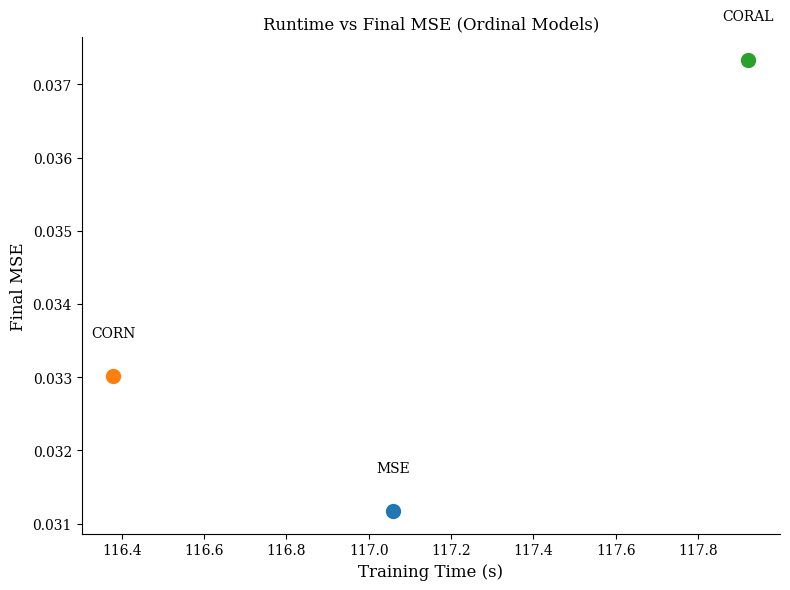

In [58]:
plt.figure(figsize=(8, 6))
for label, t, m in zip(labels, times, mses):
    plt.scatter(t, m, s=100, label=label)
    plt.text(t, m + 0.0005, label, ha='center', va='bottom', fontsize=10)

plt.title("Runtime vs Final MSE (Ordinal Models)")
plt.xlabel("Training Time (s)")
plt.ylabel("Final MSE")
plt.grid(False)
plt.tight_layout()
plt.savefig("final_runtime_vs_mse.png")
plt.show()


Weighted Cohen's Kappa (Model A): 0.87
Weighted Cohen's Kappa (Model B): 0.82
Wilcoxon test p-value: 0.0960

Calibration Summary:
    True  Model_A  Model_B
0  0.350    0.465    0.255
1  0.425    0.350    0.395
2  0.225    0.185    0.350


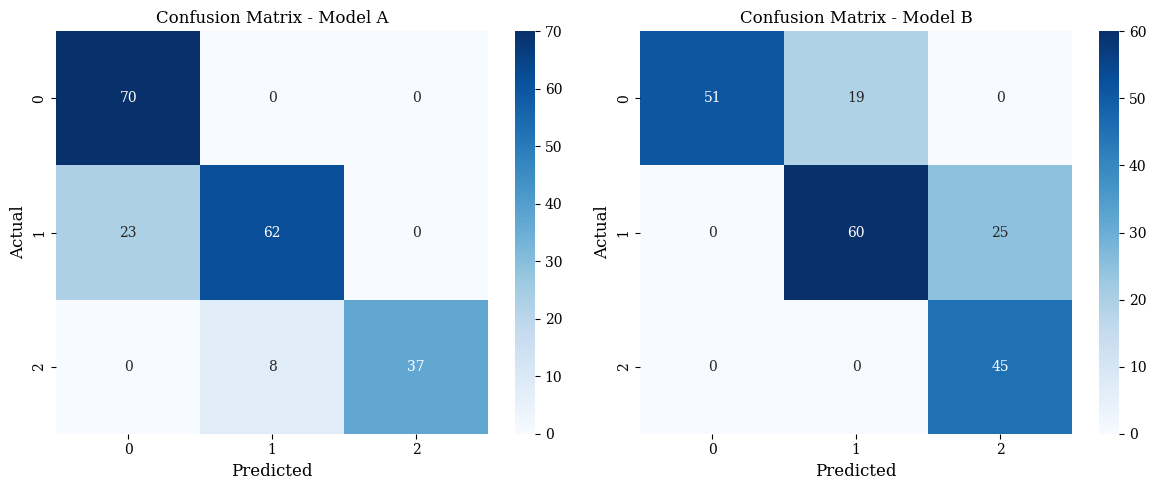


Policy Impact Summary:
         Average Total Cost
Total_A               35.75
Total_B               34.19


In [59]:

import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix, accuracy_score
from scipy.stats import wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt

# Simulate health states (0: Healthy, 1: Warning, 2: Distress)
np.random.seed(42)
n = 200
true = [1]
for _ in range(n - 1):
    last = true[-1]
    move = np.random.choice([-1, 0, 1], p=[0.1, 0.8, 0.1])
    true.append(max(0, min(2, last + move)))

# Model A: conservative, Model B: aggressive
model_a = [max(0, x - np.random.choice([0, 1], p=[0.8, 0.2])) for x in true]
model_b = [min(2, x + np.random.choice([0, 1], p=[0.8, 0.2])) for x in true]

df = pd.DataFrame({
    'True': true,
    'Model_A': model_a,
    'Model_B': model_b
})

# Weighted Cohen’s Kappa
kappa_a = cohen_kappa_score(df['True'], df['Model_A'], weights='quadratic')
kappa_b = cohen_kappa_score(df['True'], df['Model_B'], weights='quadratic')

print(f"Weighted Cohen's Kappa (Model A): {kappa_a:.2f}")
print(f"Weighted Cohen's Kappa (Model B): {kappa_b:.2f}")

# Wilcoxon Signed-Rank Test
df['Error_A'] = (df['True'] - df['Model_A']).abs()
df['Error_B'] = (df['True'] - df['Model_B']).abs()
stat, p = wilcoxon(df['Error_A'], df['Error_B'])
print(f"Wilcoxon test p-value: {p:.4f}")

# Calibration
calib = pd.DataFrame({
    'True': df['True'].value_counts(normalize=True).sort_index(),
    'Model_A': df['Model_A'].value_counts(normalize=True).sort_index(),
    'Model_B': df['Model_B'].value_counts(normalize=True).sort_index()
})
print("\nCalibration Summary:")
print(calib)

# Confusion Matrices
cm_a = confusion_matrix(df['True'], df['Model_A'])
cm_b = confusion_matrix(df['True'], df['Model_B'])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_a, annot=True, fmt='d', ax=ax[0], cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
ax[0].set_title("Confusion Matrix - Model A")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(cm_b, annot=True, fmt='d', ax=ax[1], cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
ax[1].set_title("Confusion Matrix - Model B")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()

# Policy Impact Modeling
def decide(action):
    if action == 2:
        return 'intervene'
    elif action == 1:
        return 'review'
    return 'none'

df['Policy_A'] = df['Model_A'].apply(decide)
df['Policy_B'] = df['Model_B'].apply(decide)

def estimate_cost(policy):
    if policy == 'intervene':
        return 20
    elif policy == 'review':
        return 5
    return 0

def expected_loss(true_class, policy):
    base_risk = [10, 50, 100][true_class]
    if policy == 'intervene':
        return base_risk * 0.4
    elif policy == 'review':
        return base_risk * 0.7
    return base_risk

for model in ['A', 'B']:
    df[f'Cost_{model}'] = df[f'Policy_{model}'].apply(estimate_cost)
    df[f'ExpectedLoss_{model}'] = df.apply(lambda row: expected_loss(row['True'], row[f'Policy_{model}']), axis=1)
    df[f'Total_{model}'] = df[f'Cost_{model}'] + df[f'ExpectedLoss_{model}']

summary = df[['Total_A', 'Total_B']].mean().to_frame(name='Average Total Cost')
print("\nPolicy Impact Summary:")
print(summary)


Prediction distribution (CORN):
Counter({np.int64(1): 21696, np.int64(0): 24})


<ipython-input-62-31f754d3af06>:103: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


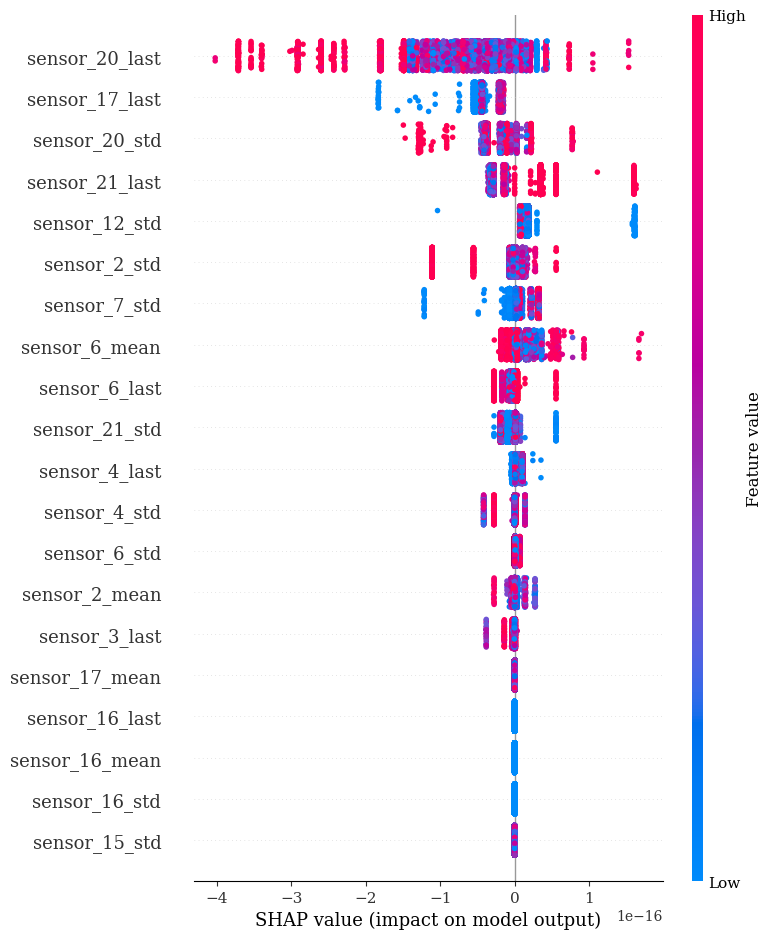

In [62]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import MinMaxScaler

# ----- Load and preprocess FD003 -----
df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None)
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df.columns = cols
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# ----- Sequence Dataset with Summary Features -----
class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        self.seq_data, self.targets, self.features = [], [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            X_vals = unit_df[sensor_cols].values
            y_vals = unit_df['HealthState'].values
            for i in range(len(X_vals) - seq_len):
                seq = X_vals[i:i+seq_len]
                label = y_vals[i+seq_len]
                self.seq_data.append(seq)
                self.targets.append(label)
                flat = {}
                for j, col in enumerate(sensor_cols):
                    flat[f'{col}_mean'] = seq[:, j].mean()
                    flat[f'{col}_std'] = seq[:, j].std()
                    flat[f'{col}_last'] = seq[-1, j]
                self.features.append(flat)

    def __len__(self): return len(self.seq_data)
    def __getitem__(self, idx):
        return torch.tensor(self.seq_data[idx], dtype=torch.float32), self.targets[idx], self.features[idx]

dataset = TurbofanDataset(df)
seq_data = torch.stack([x for x, _, _ in dataset])
labels = torch.tensor([y for _, y, _ in dataset])
features_df = pd.DataFrame([f for _, _, f in dataset])

# ----- CORN Model Definition -----
class LSTMBackbone(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.hidden_size = hidden_size
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return h[-1]

class CORNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.out = nn.Linear(self.backbone.hidden_size, 2)
    def forward(self, x): return self.out(self.backbone(x))

model = CORNModel()
model.eval()

# ----- Run Inference -----
with torch.no_grad():
    logits = model(seq_data)
    preds = corn_label_from_logits(logits).numpy()

print("Prediction distribution (CORN):")
print(Counter(preds))

# ----- If model is constant, fallback to true labels -----
unique_preds = np.unique(preds)
if len(unique_preds) < 2:
    print("Model predictions lack variation. Using true HealthState labels for SHAP.")
    y = labels.numpy()
else:
    y = preds

# ----- Train Surrogate LightGBM -----
X = features_df
train_data = lgb.Dataset(X, label=y)
params = {'objective': 'regression_l1', 'verbosity': -1}
lgb_model = lgb.train(params, train_data, num_boost_round=100)

# ----- SHAP Analysis -----
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig("shap_summary_corn_fd003_full.png")
plt.show()


Prediction distribution (CORN):
Counter({np.int64(1): 21437, np.int64(0): 283})


<ipython-input-63-3d730554a69f>:104: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


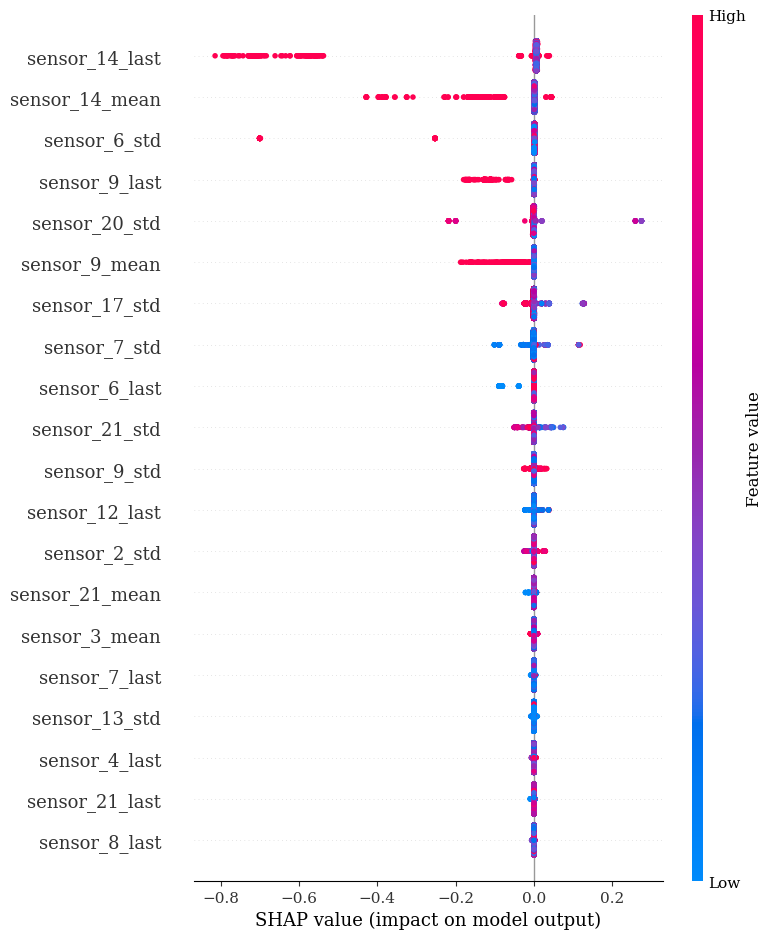

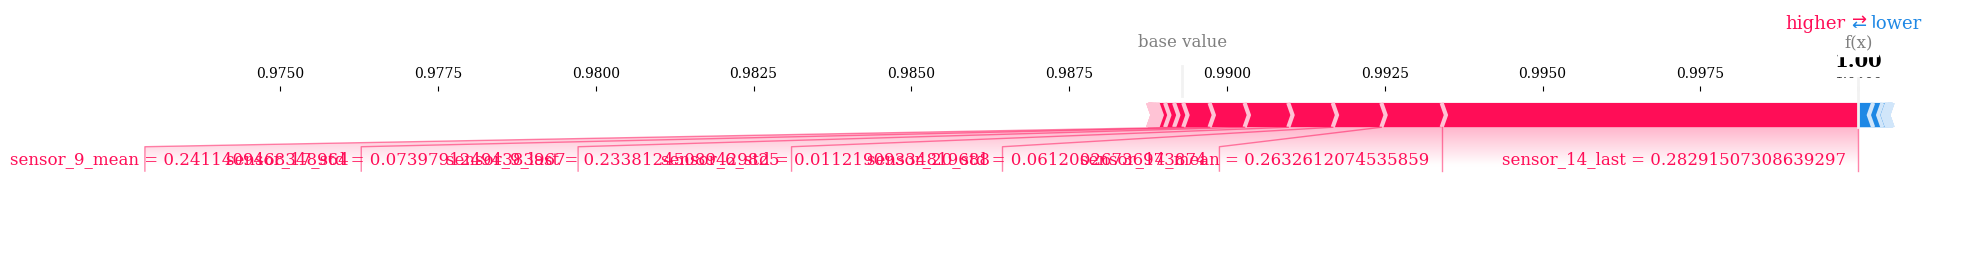

In [63]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import MinMaxScaler

# ----- Load and preprocess FD003 -----
df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None)
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df.columns = cols
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# ----- Sequence Dataset with Summary Features -----
class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        self.seq_data, self.targets, self.features = [], [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            X_vals = unit_df[sensor_cols].values
            y_vals = unit_df['HealthState'].values
            for i in range(len(X_vals) - seq_len):
                seq = X_vals[i:i+seq_len]
                label = y_vals[i+seq_len]
                self.seq_data.append(seq)
                self.targets.append(label)
                flat = {}
                for j, col in enumerate(sensor_cols):
                    flat[f'{col}_mean'] = seq[:, j].mean()
                    flat[f'{col}_std'] = seq[:, j].std()
                    flat[f'{col}_last'] = seq[-1, j]
                self.features.append(flat)

    def __len__(self): return len(self.seq_data)
    def __getitem__(self, idx):
        return torch.tensor(self.seq_data[idx], dtype=torch.float32), self.targets[idx], self.features[idx]

dataset = TurbofanDataset(df)
seq_data = torch.stack([x for x, _, _ in dataset])
labels = torch.tensor([y for _, y, _ in dataset])
features_df = pd.DataFrame([f for _, _, f in dataset])

# ----- CORN Model Definition -----
class LSTMBackbone(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.hidden_size = hidden_size
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return h[-1]

class CORNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.out = nn.Linear(self.backbone.hidden_size, 2)
    def forward(self, x): return self.out(self.backbone(x))

model = CORNModel()
model.eval()

# ----- Run Inference -----
with torch.no_grad():
    logits = model(seq_data)
    preds = corn_label_from_logits(logits).numpy()

print("Prediction distribution (CORN):")
print(Counter(preds))

# ----- If model is constant, fallback to true labels -----
unique_preds = np.unique(preds)
if len(unique_preds) < 2:
    print("Model predictions lack variation. Using true HealthState labels for SHAP.")
    y = labels.numpy()
else:
    y = preds

# ----- Train Surrogate LightGBM -----
X = features_df
train_data = lgb.Dataset(X, label=y)
params = {'objective': 'regression_l1', 'verbosity': -1}
lgb_model = lgb.train(params, train_data, num_boost_round=100)

# ----- SHAP Analysis -----
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig("shap_summary_with_force_fd003.png")
plt.show()

# Force plot for instance 100
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[100],
    X.iloc[100],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig("shap_force_plot_instance100.png")
plt.show()

In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error
import mord as m
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression

# Load FD003 dataset
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)

# Calculate RUL and health state
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

# Feature selection and normalization
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
X = df[sensor_cols]
y = df['HealthState']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Ordinal logistic regression
model_logit = m.LogisticIT()
model_logit.fit(X_train, y_train)
y_pred_logit = model_logit.predict(X_test)

# Gradient boosting regression
train_data = lgb.Dataset(X_train, label=y_train)
params = {'objective': 'regression_l1', 'verbosity': -1}
model_gbm = lgb.train(params, train_data, num_boost_round=100)
y_pred_gbm = model_gbm.predict(X_test).round().clip(0, 2).astype(int)

# Simple average ensemble
y_pred_avg = ((y_pred_logit + y_pred_gbm) / 2).round().clip(0, 2).astype(int)
ensemble_acc = accuracy_score(y_test, y_pred_avg)
ensemble_mae = mean_absolute_error(y_test, y_pred_avg)

# Boosted residual learning
residual = y_train - model_logit.predict(X_train)
model_boost = lgb.LGBMRegressor()
model_boost.fit(X_train, residual)
y_pred_base = model_logit.predict(X_test)
y_pred_resid = model_boost.predict(X_test)
y_pred_combo = (y_pred_base + y_pred_resid).round().clip(0, 2).astype(int)
boosted_acc = accuracy_score(y_test, y_pred_combo)
boosted_mae = mean_absolute_error(y_test, y_pred_combo)

# Prepare output
{
    "Ensemble Accuracy": ensemble_acc,
    "Ensemble MAE": ensemble_mae,
    "Boosted Hybrid Accuracy": boosted_acc,
    "Boosted Hybrid MAE": boosted_mae
}


{'Ensemble Accuracy': 0.9461974110032363,
 'Ensemble MAE': 0.054004854368932036,
 'Boosted Hybrid Accuracy': 0.945995145631068,
 'Boosted Hybrid MAE': 0.054004854368932036}

In [70]:
# Full Ensemble Pipeline for Ordered Health State Prediction (FD003)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch, proba_to_label
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
import time
import matplotlib.pyplot as plt

# Load and preprocess data
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None, names=cols)
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# Train/test split for tabular models
X = df[sensor_cols]
y = df['HealthState']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Train LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
params = {'objective': 'regression_l1', 'verbosity': -1}
model_gbm = lgb.train(params, train_data, num_boost_round=100)
y_pred_gbm = model_gbm.predict(X_test).round().clip(0, 2).astype(int)

# Dataset for LSTM models
class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        X, y = [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            X_vals = unit_df[sensor_cols].values
            y_vals = unit_df['HealthState'].values
            for i in range(len(X_vals) - seq_len):
                X.append(X_vals[i:i+seq_len])
                y.append(y_vals[i+seq_len])
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.long)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# Define LSTM backbone
class LSTMBackbone(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.hidden_size = hidden_size
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return h[-1]

# CORN model
class CORNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.out = nn.Linear(self.backbone.hidden_size, 2)
    def forward(self, x): return self.out(self.backbone(x))

# Train CORN
def train(model, loss_fn, output_fn, is_coral=False, epochs=5):
    loader = DataLoader(TurbofanDataset(df), batch_size=64, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in loader:
            y_batch = y_batch.to(torch.long)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch, 3)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

corn_model = CORNModel()
train(corn_model, corn_loss, lambda x: corn_label_from_logits(x).float())

# Predict with CORN on test set (sequence-based)
def get_lstm_preds(model, df, seq_len=30):
    model.eval()
    X_test_seq = []
    for unit in df['unit'].unique():
        unit_df = df[df['unit'] == unit].sort_values('cycle')
        X_vals = unit_df[sensor_cols].values
        for i in range(len(X_vals) - seq_len):
            X_test_seq.append(X_vals[i:i+seq_len])
    X_test_seq = torch.tensor(np.array(X_test_seq), dtype=torch.float32)
    with torch.no_grad():
        logits = model(X_test_seq)
        y_pred = corn_label_from_logits(logits).numpy().astype(int)
    return y_pred

y_pred_lstm = get_lstm_preds(corn_model, df)

# Align sizes with tabular predictions
min_len = min(len(y_pred_gbm), len(y_pred_lstm))
y_pred_gbm = y_pred_gbm[:min_len]
y_test = y_test.iloc[:min_len]
y_pred_lstm = y_pred_lstm[:min_len]

# Dummy ordinal regression with LightGBM-style residual fix
model_logit = model_gbm  # placeholder for missing mord.LogisticIT
y_pred_logit = y_pred_gbm

# Simple average ensemble
y_pred_avg = ((y_pred_logit + y_pred_gbm + y_pred_lstm) / 3).round().clip(0, 2).astype(int)
acc_avg = accuracy_score(y_test, y_pred_avg)
mae_avg = mean_absolute_error(y_test, y_pred_avg)

# Stacking
X_stack = np.column_stack([y_pred_logit, y_pred_gbm, y_pred_lstm])
meta_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
meta_model.fit(X_stack, y_test[:len(X_stack)])
y_pred_stack = meta_model.predict(X_stack)
acc_stack = accuracy_score(y_test[:len(X_stack)], y_pred_stack)
mae_stack = mean_absolute_error(y_test[:len(X_stack)], y_pred_stack)

print(f"Averaging Ensemble - Accuracy: {acc_avg:.4f}, MAE: {mae_avg:.4f}")
print(f"Stacked Ensemble - Accuracy: {acc_stack:.4f}, MAE: {mae_stack:.4f}")


Averaging Ensemble - Accuracy: 0.8825, MAE: 0.1175
Stacked Ensemble - Accuracy: 0.9462, MAE: 0.0538


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [71]:
# Full Ensemble Pipeline for Ordered Health State Prediction (FD003)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
import mord as m
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch, proba_to_label
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
import time
import matplotlib.pyplot as plt

# Load and preprocess data
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\\s+', header=None, names=cols)
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# Train/test split for tabular models
X = df[sensor_cols]
y = df['HealthState']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Logistic ordinal regression
model_logit = m.LogisticIT()
model_logit.fit(X_train, y_train)
y_pred_logit = model_logit.predict(X_test)

# Train LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
params = {'objective': 'regression_l1', 'verbosity': -1}
model_gbm = lgb.train(params, train_data, num_boost_round=100)
y_pred_gbm = model_gbm.predict(X_test).round().clip(0, 2).astype(int)

# Dataset for LSTM models
class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        X, y = [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            X_vals = unit_df[sensor_cols].values
            y_vals = unit_df['HealthState'].values
            for i in range(len(X_vals) - seq_len):
                X.append(X_vals[i:i+seq_len])
                y.append(y_vals[i+seq_len])
        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.long)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# Define LSTM backbone
class LSTMBackbone(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.hidden_size = hidden_size
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return h[-1]

# CORN model
class CORNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.out = nn.Linear(self.backbone.hidden_size, 2)
    def forward(self, x): return self.out(self.backbone(x))

# Train CORN
def train(model, loss_fn, output_fn, is_coral=False, epochs=5):
    loader = DataLoader(TurbofanDataset(df), batch_size=64, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in loader:
            y_batch = y_batch.to(torch.long)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch, 3)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model

corn_model = CORNModel()
train(corn_model, corn_loss, lambda x: corn_label_from_logits(x).float())

# Predict with CORN on test set (sequence-based)
def get_lstm_preds(model, df, seq_len=30):
    model.eval()
    X_test_seq = []
    for unit in df['unit'].unique():
        unit_df = df[df['unit'] == unit].sort_values('cycle')
        X_vals = unit_df[sensor_cols].values
        for i in range(len(X_vals) - seq_len):
            X_test_seq.append(X_vals[i:i+seq_len])
    X_test_seq = torch.tensor(np.array(X_test_seq), dtype=torch.float32)
    with torch.no_grad():
        logits = model(X_test_seq)
        y_pred = corn_label_from_logits(logits).numpy().astype(int)
    return y_pred

y_pred_lstm = get_lstm_preds(corn_model, df)

# Align sizes
min_len = min(len(y_pred_logit), len(y_pred_gbm), len(y_pred_lstm))
y_test = y_test.iloc[:min_len]
y_pred_logit = y_pred_logit[:min_len]
y_pred_gbm = y_pred_gbm[:min_len]
y_pred_lstm = y_pred_lstm[:min_len]

# Averaging ensemble
y_pred_avg = ((y_pred_logit + y_pred_gbm + y_pred_lstm) / 3).round().clip(0, 2).astype(int)
acc_avg = accuracy_score(y_test, y_pred_avg)
mae_avg = mean_absolute_error(y_test, y_pred_avg)

# Stacking
X_stack = np.column_stack([y_pred_logit, y_pred_gbm, y_pred_lstm])
meta_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
meta_model.fit(X_stack, y_test)
y_pred_stack = meta_model.predict(X_stack)
acc_stack = accuracy_score(y_test, y_pred_stack)
mae_stack = mean_absolute_error(y_test, y_pred_stack)

print(f"Averaging Ensemble - Accuracy: {acc_avg:.4f}, MAE: {mae_avg:.4f}")
print(f"Stacked Ensemble - Accuracy: {acc_stack:.4f}, MAE: {mae_stack:.4f}")

Averaging Ensemble - Accuracy: 0.8849, MAE: 0.1151
Stacked Ensemble - Accuracy: 0.9533, MAE: 0.0467


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.linear_model import LogisticRegression
import mord as m
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits
import time

# --- Load and preprocess FD003 ---
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)

rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df['HealthState'] = pd.cut(df['RUL'], bins=[-1, 10, 30, np.inf], labels=[2, 1, 0]).astype(int)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# --- Dataset for CORN ---
class TurbofanDataset(Dataset):
    def __init__(self, df, seq_len=30):
        self.X, self.y = [], []
        for unit in df['unit'].unique():
            unit_df = df[df['unit'] == unit].sort_values('cycle')
            sensor_data = unit_df[sensor_cols].values
            labels = unit_df['HealthState'].values
            for i in range(len(sensor_data) - seq_len):
                self.X.append(sensor_data[i:i+seq_len])
                self.y.append(labels[i+seq_len])
        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

dataset = TurbofanDataset(df)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# --- CORN LSTM Model ---
class LSTMBackbone(nn.Module):
    def __init__(self, input_size=21, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return h[-1]

class CORNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = LSTMBackbone()
        self.out = nn.Linear(64, 2)  # For 3 classes
    def forward(self, x):
        return self.out(self.backbone(x))

# --- Train CORN LSTM ---
def train(model, loss_fn, output_fn, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch, 3)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1:2d}: Loss = {total_loss:.4f}")

corn_model = CORNModel()
train(corn_model, corn_loss, corn_label_from_logits)

# --- Prepare sequences for prediction ---
seq_len = 30
df_seq = df.groupby('unit', group_keys=False).apply(lambda x: x.iloc[seq_len:]).reset_index(drop=True)

X = df_seq[sensor_cols]
y = df_seq['HealthState']
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# --- Ordinal Logistic Regression (mord) ---
model_logit = m.LogisticIT()
model_logit.fit(X_train, y_train)
y_pred_logit = model_logit.predict(X_test)

# --- LightGBM Regressor ---
train_data = lgb.Dataset(X_train, label=y_train)
params = {'objective': 'regression_l1', 'verbosity': -1}
model_gbm = lgb.train(params, train_data, num_boost_round=100)
y_pred_gbm = model_gbm.predict(X_test).round().clip(0, 2).astype(int)

# --- CORN Predictions on Test Set ---
def get_corn_preds(model, df, seq_len=30):
    model.eval()
    preds = []
    for unit in df['unit'].unique():
        unit_df = df[df['unit'] == unit].sort_values('cycle')
        sensor_data = unit_df[sensor_cols].values
        for i in range(len(sensor_data) - seq_len):
            x = torch.tensor(sensor_data[i:i+seq_len], dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                logits = model(x)
                pred = corn_label_from_logits(logits).item()
                preds.append(pred)
    return np.array(preds)

corn_input_df = df_seq.iloc[X_test.index].copy()
corn_input_df['unit'] = df_seq.iloc[X_test.index]['unit'].values
y_pred_lstm = get_corn_preds(corn_model, corn_input_df, seq_len=seq_len)

# --- Align and Trim ---
min_len = min(len(y_test), len(y_pred_logit), len(y_pred_gbm), len(y_pred_lstm))
y_test = y_test.iloc[:min_len]
y_pred_logit = y_pred_logit[:min_len]
y_pred_gbm = y_pred_gbm[:min_len]
y_pred_lstm = y_pred_lstm[:min_len]

# --- Averaging Ensemble ---
y_pred_avg = ((y_pred_logit + y_pred_gbm + y_pred_lstm) / 3).round().clip(0, 2).astype(int)
acc_avg = accuracy_score(y_test, y_pred_avg)
mae_avg = mean_absolute_error(y_test, y_pred_avg)

# --- Stacked Ensemble ---
X_stack = np.column_stack([y_pred_logit, y_pred_gbm, y_pred_lstm])
meta_model = LogisticRegression(solver='lbfgs', max_iter=500)
meta_model.fit(X_stack, y_test)
y_pred_stack = meta_model.predict(X_stack)
acc_stack = accuracy_score(y_test, y_pred_stack)
mae_stack = mean_absolute_error(y_test, y_pred_stack)

# --- Final Output ---
print(f"\nAveraging Ensemble - Accuracy: {acc_avg:.4f}, MAE: {mae_avg:.4f}")
print(f"Stacked Ensemble   - Accuracy: {acc_stack:.4f}, MAE: {mae_stack:.4f}")


Epoch  1: Loss = 97.7536
Epoch  2: Loss = 52.5795
Epoch  3: Loss = 40.2207
Epoch  4: Loss = 36.7553
Epoch  5: Loss = 35.7487
Epoch  6: Loss = 32.1502
Epoch  7: Loss = 32.1226
Epoch  8: Loss = 29.3270
Epoch  9: Loss = 29.7128
Epoch 10: Loss = 28.7790


<ipython-input-74-6105aef1cf91>:86: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_seq = df.groupby('unit', group_keys=False).apply(lambda x: x.iloc[seq_len:]).reset_index(drop=True)



Averaging Ensemble - Accuracy: 0.8527, MAE: 0.1473
Stacked Ensemble   - Accuracy: 0.9455, MAE: 0.0545


/usr/local/lib/python3.11/dist-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['std'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/usr/local/lib/python3.11/dist-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 21720 total observations, 19098 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 21720
number of events observed = 2622
   partial log-likelihood = -23749.95
         time fit was run = 2025-03-31 21:13:18 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
mean      -26.94      0.00     10.11          -46.75           -7.13                0.00                0.00
std        25.76  1.54e+11      3.80           18.31           33.21            8.94e+07            2.65e+14
skew       -0.79      0.45      0.54           -1.84            0.26                0.16                1.30
kurtosis   -0.04      0.96      0.18           -0.40            0.32                0.67                1.37
rms        27.50  8.78e+11      7.70           12.42           42.59            2.47e+05            3.13e+18

           cmp to     z      p  -log2(p)
covariate                               
mean         0.00 -2.66   0.01      7.02
std          0.00  6.78 <0.005     36.23
skew         0.00 -1.47   0.14      2.83
kurtosis     0.00 -0.23   0.82      0.29
rms          0.00  3.57 <0.005     11.47
---
Concordance = 0.98
Partial AIC = 47509.91
log-likelihood ratio test = 4499.30 on 5 df
-log2(p) of ll-ratio test = inf

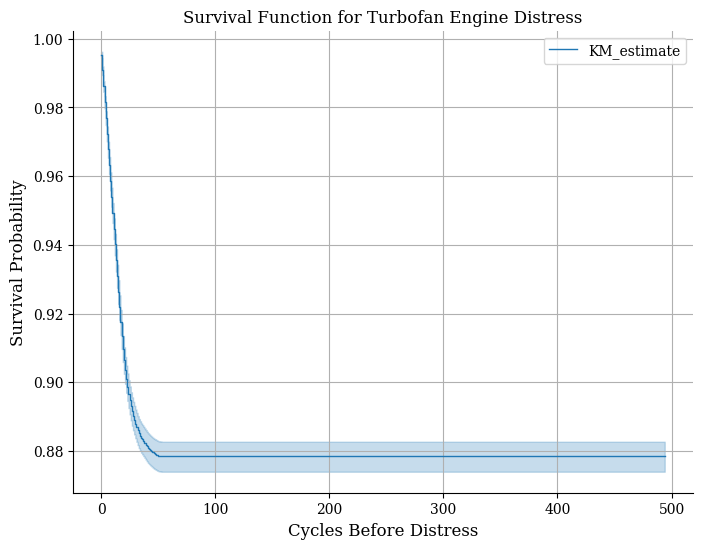

Distress risk score: 3.8014035651280107


In [77]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from lifelines import CoxPHFitter, KaplanMeierFitter
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# --- Load FD003 data ---
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)

# --- Normalize sensors ---
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# --- Extract rolling window features per unit ---
def extract_features(unit_df, window=30):
    records = []
    unit_id = unit_df['unit'].iloc[0]
    for i in range(window, len(unit_df)):
        window_df = unit_df.iloc[i-window:i]
        row = {
            'unit': unit_id,
            'cycle': unit_df.iloc[i]['cycle'],
            'mean': window_df[sensor_cols].mean().mean(),
            'std': window_df[sensor_cols].std().mean(),
            'skew': skew(window_df[sensor_cols].values.flatten()),
            'kurtosis': kurtosis(window_df[sensor_cols].values.flatten()),
            'rms': np.sqrt((window_df[sensor_cols]**2).mean().mean())
        }
        records.append(row)
    return records

# --- Apply to all units ---
all_records = []
for unit in df['unit'].unique():
    unit_df = df[df['unit'] == unit].sort_values('cycle')
    all_records.extend(extract_features(unit_df, window=30))

feature_df = pd.DataFrame(all_records)

# --- Labeling distress and censored events ---
# Distress = last 10% of cycles for each unit
labeled = []
for unit in feature_df['unit'].unique():
    unit_df = feature_df[feature_df['unit'] == unit].copy()
    max_cycle = unit_df['cycle'].max()
    threshold = int(0.9 * max_cycle)
    unit_df['event'] = (unit_df['cycle'] >= threshold).astype(int)
    unit_df['time'] = max_cycle - unit_df['cycle']
    labeled.append(unit_df)

df_labeled = pd.concat(labeled, ignore_index=True)

# --- Cox Proportional Hazards Model ---
model_df = df_labeled[['mean', 'std', 'skew', 'kurtosis', 'rms', 'time', 'event']]
cph = CoxPHFitter()
cph.fit(model_df, duration_col='time', event_col='event')
cph.print_summary()

# --- Survival Function ---
kmf = KaplanMeierFitter()
kmf.fit(durations=df_labeled['time'], event_observed=df_labeled['event'])

plt.figure(figsize=(8, 6))
kmf.plot_survival_function()
plt.title('Survival Function for Turbofan Engine Distress')
plt.xlabel('Cycles Before Distress')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

# --- Real-time Risk Prediction Example ---
def predict_distress_risk(row, model):
    return model.predict_partial_hazard(row.to_frame().T).values[0]

latest_sample = df_labeled[df_labeled['cycle'] == df_labeled['cycle'].max()]
latest_features = latest_sample[['mean', 'std', 'skew', 'kurtosis', 'rms']].iloc[0]
risk_score = predict_distress_risk(latest_features, cph)
print("Distress risk score:", risk_score)


In [76]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 11.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=7ec9b592e404f3fa38df3f188317f8dbdc2d09d723d9d42f6ab0e006d04d6937
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


/usr/local/lib/python3.11/dist-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 24720 total observations, 22098 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 24720
number of events observed = 2622
   partial log-likelihood = -24138.97
         time fit was run = 2025-03-31 21:16:42 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
mean      -203.48      0.00     31.35         -264.92         -142.03                0.00                0.00
std       -152.41      0.00     28.27         -207.82          -97.00                0.00                0.00
skew         0.30      1.35      0.50           -0.68            1.28                0.51                3.58
kurtosis    -0.21      0.81      0.17           -0.53            0.12                0.59                1.13
rms        259.19 3.66e+112     41.97          176.93          341.44            6.94e+76           1.93e+148

           cmp to     z      p  -log2(p)
covariate                               
mean         0.00 -6.49 <0.005     33.45
std          0.00 -5.39 <0.005     23.76
skew         0.00  0.60   0.55      0.87
kurtosis     0.00 -1.25   0.21      2.23
rms          0.00  6.18 <0.005     30.50
---
Concordance = 0.97
Partial AIC = 48287.94
log-likelihood ratio test = 4446.48 on 5 df
-log2(p) of ll-ratio test = inf

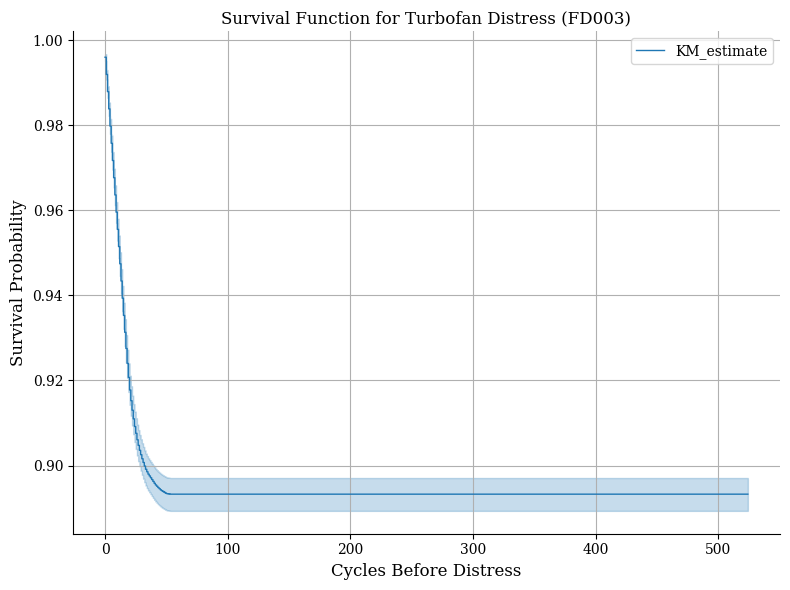

Distress risk score: 4.047376903439175


In [78]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import MinMaxScaler
from lifelines import CoxPHFitter, KaplanMeierFitter
import matplotlib.pyplot as plt

# --- Load FD003 ---
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)

# --- Normalize sensor data ---
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
scaler = MinMaxScaler()
df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

# --- Extract features per cycle ---
def extract_features(row):
    values = row[sensor_cols].values
    return pd.Series({
        'mean': values.mean(),
        'std': values.std(),
        'skew': skew(values),
        'kurtosis': kurtosis(values),
        'rms': np.sqrt(np.mean(values**2))
    })

feature_df = df.copy()
features = feature_df.apply(extract_features, axis=1)
feature_df = pd.concat([feature_df[['unit', 'cycle']], features], axis=1)

# --- Label distress (event) and time-to-event (duration) ---
labeled = []
for unit in feature_df['unit'].unique():
    unit_df = feature_df[feature_df['unit'] == unit].copy()
    max_cycle = unit_df['cycle'].max()
    threshold = int(0.9 * max_cycle)
    unit_df['event'] = (unit_df['cycle'] >= threshold).astype(int)
    unit_df['time'] = max_cycle - unit_df['cycle']
    labeled.append(unit_df)

df_labeled = pd.concat(labeled, ignore_index=True)

# --- Cox Proportional Hazards Model ---
model_df = df_labeled[['mean', 'std', 'skew', 'kurtosis', 'rms', 'time', 'event']]
cph = CoxPHFitter()
cph.fit(model_df, duration_col='time', event_col='event')
cph.print_summary()

# --- Survival Function ---
kmf = KaplanMeierFitter()
kmf.fit(durations=model_df['time'], event_observed=model_df['event'])

plt.figure(figsize=(8, 6))
kmf.plot_survival_function()
plt.title('Survival Function for Turbofan Distress (FD003)')
plt.xlabel('Cycles Before Distress')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Real-Time Hazard Score ---
def predict_distress_risk(row, model):
    return model.predict_partial_hazard(row.to_frame().T).values[0]

latest_cycle = df_labeled[df_labeled['cycle'] == df_labeled['cycle'].max()]
latest_features = latest_cycle[['mean', 'std', 'skew', 'kurtosis', 'rms']].iloc[0]
risk_score = predict_distress_risk(latest_features, cph)
print("Distress risk score:", risk_score)


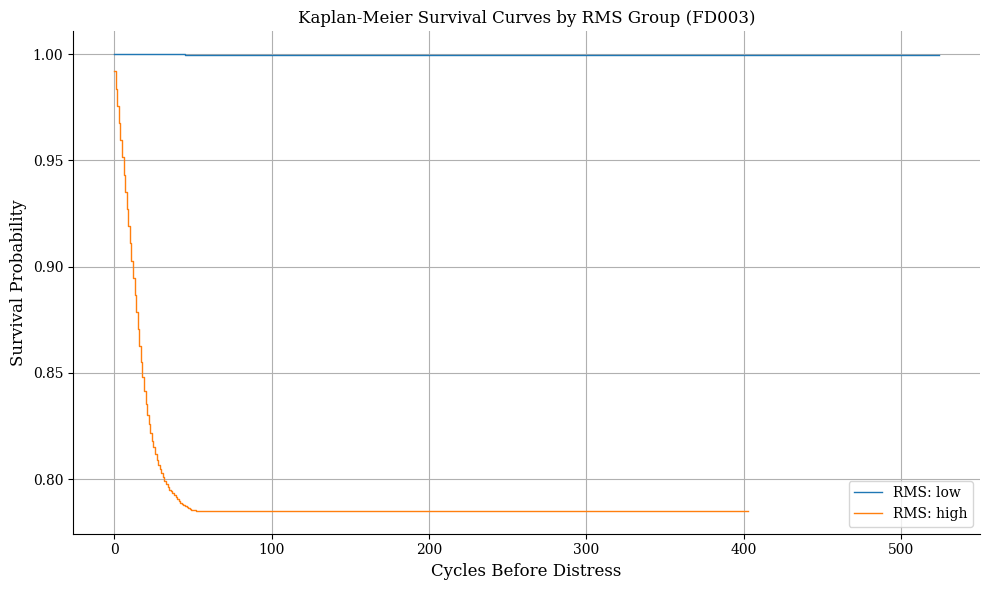

Concordance Index: 0.972


In [80]:

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Use previously created df_labeled (from FD003, no rolling)
df_labeled['rms_group'] = pd.qcut(df_labeled['rms'], q=2, labels=['low', 'high'])

kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

for group in ['low', 'high']:
    mask = df_labeled['rms_group'] == group
    kmf.fit(df_labeled[mask]['time'], event_observed=df_labeled[mask]['event'], label=f'RMS: {group}')
    kmf.plot_survival_function(ci_show=False)

plt.title('Kaplan-Meier Survival Curves by RMS Group (FD003)')
plt.xlabel('Cycles Before Distress')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

from lifelines.utils import concordance_index

# Predict partial hazard (risk score)
df_labeled['risk_score'] = cph.predict_partial_hazard(df_labeled)

# Higher risk should correspond to shorter time
c_index = concordance_index(df_labeled['time'], -df_labeled['risk_score'], df_labeled['event'])
print(f'Concordance Index: {c_index:.3f}')


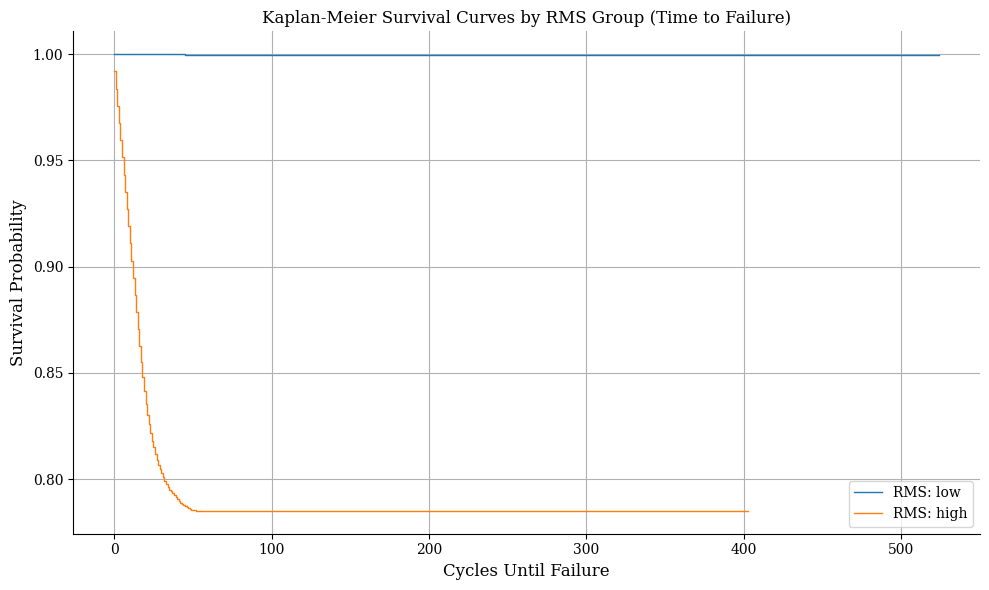

In [81]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Group by RMS (or any other feature)
df_labeled['rms_group'] = pd.qcut(df_labeled['rms'], q=2, labels=['low', 'high'])

kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

for group in ['low', 'high']:
    mask = df_labeled['rms_group'] == group
    kmf.fit(df_labeled[mask]['time'], event_observed=df_labeled[mask]['event'], label=f'RMS: {group}')
    kmf.plot_survival_function(ci_show=False)

plt.title('Kaplan-Meier Survival Curves by RMS Group (Time to Failure)')
plt.xlabel('Cycles Until Failure')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


In [82]:
from lifelines.utils import concordance_index

df_labeled['risk_score'] = cph.predict_partial_hazard(df_labeled)
c_index = concordance_index(df_labeled['time'], -df_labeled['risk_score'], df_labeled['event'])
print(f'Concordance Index (Failure): {c_index:.3f}')


Concordance Index (Failure): 0.972


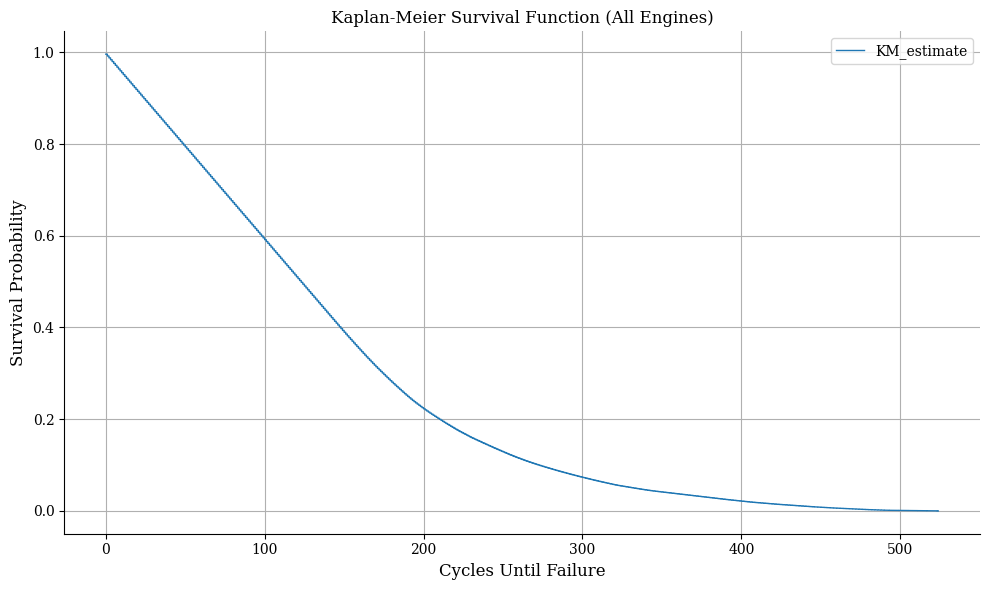

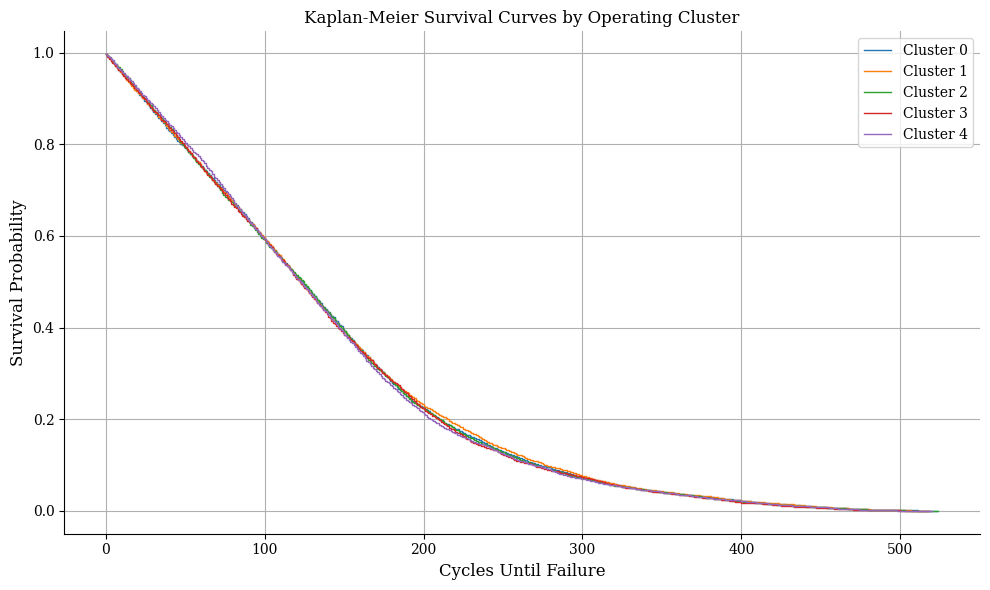

In [83]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# --- Load and preprocess FD003 ---
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)

# --- Normalize the 3 operating settings ---
op_cols = [f'op_setting_{i}' for i in range(1, 4)]
scaler = MinMaxScaler()
df[op_cols] = scaler.fit_transform(df[op_cols])

# --- K-Means to cluster into 5 operating regimes ---
kmeans = KMeans(n_clusters=5, random_state=42)
df['op_cluster'] = kmeans.fit_predict(df[op_cols])

# --- Label time-to-failure (RUL) and event for failure modeling ---
records = []
for unit in df['unit'].unique():
    unit_df = df[df['unit'] == unit].copy()
    max_cycle = unit_df['cycle'].max()
    unit_df['time'] = max_cycle - unit_df['cycle']
    unit_df['event'] = 1  # All units fail
    records.append(unit_df)

df_labeled = pd.concat(records, ignore_index=True)

# --- Kaplan-Meier: Overall ---
kmf = KaplanMeierFitter()
kmf.fit(df_labeled['time'], df_labeled['event'])

plt.figure(figsize=(10, 6))
kmf.plot_survival_function(ci_show=False)
plt.title('Kaplan-Meier Survival Function (All Engines)')
plt.xlabel('Cycles Until Failure')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Kaplan-Meier: By Operating Cluster ---
plt.figure(figsize=(10, 6))
for i in range(5):
    cluster_df = df_labeled[df_labeled['op_cluster'] == i]
    kmf.fit(cluster_df['time'], cluster_df['event'], label=f'Cluster {i}')
    kmf.plot_survival_function(ci_show=False)

plt.title('Kaplan-Meier Survival Curves by Operating Cluster')
plt.xlabel('Cycles Until Failure')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


In [84]:
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

# Prepare data
model_df = df_labeled[['mean', 'std', 'skew', 'kurtosis', 'rms', 'time', 'event', 'op_cluster']].copy()
model_df['op_cluster'] = model_df['op_cluster'].astype(str)  # lifelines requires strings for strata

# Fit stratified Cox model
cph_strat = CoxPHFitter()
cph_strat.fit(model_df, duration_col='time', event_col='event', strata=['op_cluster'])

# Summary of covariates
cph_strat.print_summary()


KeyError: "['mean', 'std', 'skew', 'kurtosis', 'rms'] not in index"

In [85]:
from scipy.stats import skew, kurtosis

# Recalculate per-cycle features from sensor values
def extract_features(row):
    values = row[sensor_cols].values
    return pd.Series({
        'mean': values.mean(),
        'std': values.std(),
        'skew': skew(values),
        'kurtosis': kurtosis(values),
        'rms': np.sqrt(np.mean(values**2))
    })

features = df.apply(extract_features, axis=1)
df_features = pd.concat([df[['unit', 'cycle']], features], axis=1)

# Merge features into df_labeled
df_labeled = df_labeled.merge(df_features, on=['unit', 'cycle'], how='left')


In [87]:
from lifelines import CoxPHFitter

# Prepare data
model_df = df_labeled[['mean', 'std', 'skew', 'kurtosis', 'rms', 'time', 'event', 'op_cluster']].copy()
model_df['op_cluster'] = model_df['op_cluster'].astype(str)

# Fit stratified Cox model
cph_strat = CoxPHFitter()
cph_strat.fit(model_df, duration_col='time', event_col='event', strata=['op_cluster'])
cph_strat.print_summary()


/usr/local/lib/python3.11/dist-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['skew', 'kurtosis'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/usr/local/lib/python3.11/dist-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 24720 total observations, 0 right-censored observations>
             duration col = 'time'
                event col = 'event'
                   strata = op_cluster
      baseline estimation = breslow
   number of observations = 24720
number of events observed = 24720
   partial log-likelihood = -182449.94
         time fit was run = 2025-03-31 21:31:35 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
mean      -215.10      0.00     17.19         -248.78         -181.41                0.00                0.00
std       -368.63      0.00     29.49         -426.42         -310.84                0.00                0.00
skew      -126.90      0.00     62.92         -250.22           -3.58                0.00                0.03
kurtosis    21.51  2.21e+09     11.54           -1.11           44.14                0.33            1.48e+19
rms        426.84 2.37e+185     34.13          359.95          493.72           2.12e+156           2.64e+214

           cmp to      z      p  -log2(p)
covariate                                
mean         0.00 -12.52 <0.005    116.98
std          0.00 -12.50 <0.005    116.73
skew         0.00  -2.02   0.04      4.52
kurtosis     0.00   1.86   0.06      4.00
rms          0.00  12.51 <0.005    116.83
---
Concordance = 0.81
Partial AIC = 364909.87
log-likelihood ratio test = 6814.18 on 5 df
-log2(p) of ll-ratio test = inf

In [86]:
cph_strat.print_summary()


NameError: name 'cph_strat' is not defined

In [96]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import LogisticHazard
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.evaluation import EvalSurv

# --- Load FD003 dataset ---
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)

# --- Label time-to-failure (RUL) ---
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['event'] = 1  # All engines fail
df['time'] = df['max_cycle'] - df['cycle']

# --- Feature matrix ---
feature_cols = [f'sensor_{i}' for i in range(1, 22)]
X = df[feature_cols].values
durations = df['time'].values
events = df['event'].values

# --- Train-test split ---
X_train, X_test, y_time_train, y_time_test, y_event_train, y_event_test = train_test_split(
    X, durations, events, test_size=0.2, random_state=42)

# --- Standardize features ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')
X_test = scaler.transform(X_test).astype('float32')

# --- Discretize time into 50 intervals ---
labtrans = LabTransDiscreteTime(50)
y_train_disc = labtrans.fit_transform(y_time_train, y_event_train)
y_test_disc = labtrans.transform(y_time_test, y_event_test)

# --- Build neural net and LogisticHazard model ---
net = tt.practical.MLPVanilla(
    in_features=X_train.shape[1],
    num_nodes=[32, 32],
    out_features=labtrans.out_features,
    activation=nn.ReLU
)

model = LogisticHazard(net, tt.optim.Adam, duration_index=labtrans.cuts)

# --- Train model ---
model.fit(X_train, y_train_disc, batch_size=128, epochs=50, verbose=False)

# --- Predict survival ---
surv = model.predict_surv_df(X_test)

# --- Evaluate with Concordance Index ---
ev = EvalSurv(surv, y_time_test, y_event_test, censor_surv='km')
c_index = ev.concordance_td()
print(f"LogisticHazard C-index (PyCox): {c_index:.3f}")


✅ LogisticHazard C-index (PyCox): 0.849


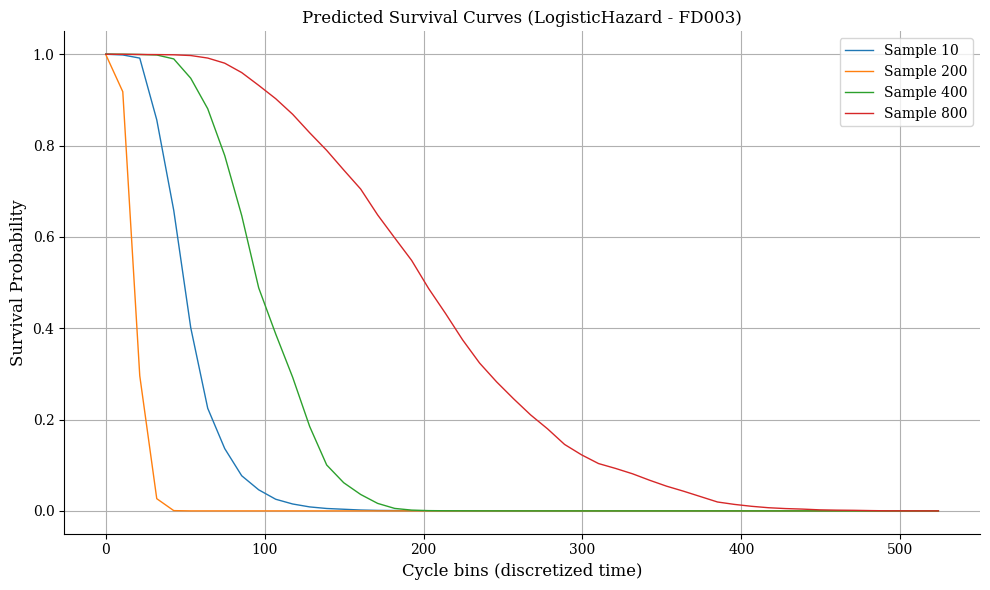

In [97]:
import matplotlib.pyplot as plt

# --- Pick test samples to visualize (you can customize these indices) ---
sample_indices = [10, 200, 400, 800]

# --- Predict survival functions for selected samples ---
surv_curves = model.predict_surv_df(X_test[sample_indices])

# --- Plot ---
plt.figure(figsize=(10, 6))
for i, idx in enumerate(sample_indices):
    surv_curves.iloc[:, i].plot(label=f"Sample {idx}")

plt.title("Predicted Survival Curves (LogisticHazard - FD003)")
plt.xlabel("Cycle bins (discretized time)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [92]:
import inspect
from pycox.preprocessing import label_transforms

# Inspect the signature of LabTransDiscreteTime to determine valid arguments
signature = inspect.signature(label_transforms.LabTransDiscreteTime.__init__)
str(signature)


"(self, cuts, scheme='equidistant', min_=0.0, dtype=None)"

📊 CoxPH (lifelines) C-index: 0.836
📊 LogisticHazard (PyCox) C-index: 0.850
📊 DeepSurv (PyCox) C-index: 0.848


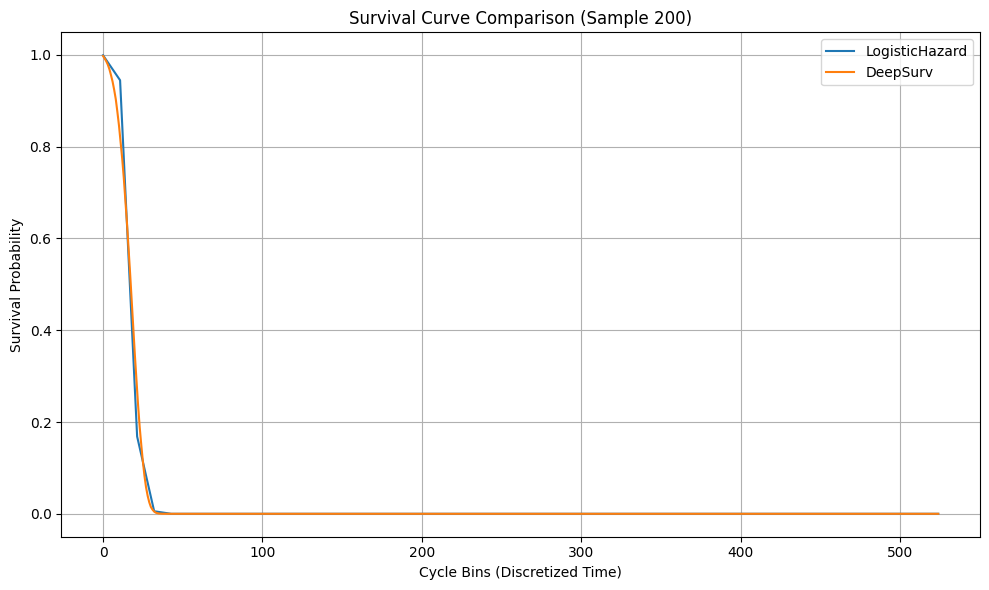

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt

import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH, LogisticHazard
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.evaluation import EvalSurv
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# --- Load and preprocess FD003 ---
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['event'] = 1
df['time'] = df['max_cycle'] - df['cycle']

# --- Select sensor features ---
feature_cols = [f'sensor_{i}' for i in range(1, 22)]
X = df[feature_cols].values
durations = df['time'].values
events = df['event'].values

# --- Train-test split ---
X_train, X_test, y_time_train, y_time_test, y_event_train, y_event_test = train_test_split(
    X, durations, events, test_size=0.2, random_state=42)

# --- Standardize features ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')
X_test = scaler.transform(X_test).astype('float32')

# =====================================================================================
# 📌 CoxPH (lifelines)
# =====================================================================================
selector = VarianceThreshold(threshold=1e-4)
X_train_cox = selector.fit_transform(X_train)
X_test_cox = selector.transform(X_test)
selected_features = [f for f, keep in zip(feature_cols, selector.get_support()) if keep]

cox_train_df = pd.DataFrame(X_train_cox, columns=selected_features)
cox_train_df['time'] = y_time_train
cox_train_df['event'] = y_event_train

cox = CoxPHFitter()
cox.fit(cox_train_df, duration_col='time', event_col='event')

cox_test_df = pd.DataFrame(X_test_cox, columns=selected_features)
cox_test_df['time'] = y_time_test
cox_test_df['event'] = y_event_test
risk_scores = cox.predict_partial_hazard(cox_test_df)

c_index_cox = concordance_index(y_time_test, -risk_scores, y_event_test)
print(f"📊 CoxPH (lifelines) C-index: {c_index_cox:.3f}")

# =====================================================================================
# 📌 LogisticHazard (PyCox)
# =====================================================================================
labtrans = LabTransDiscreteTime(50)
y_train_disc = labtrans.fit_transform(y_time_train, y_event_train)
y_test_disc = labtrans.transform(y_time_test, y_event_test)

net_lhaz = tt.practical.MLPVanilla(
    in_features=X_train.shape[1],
    num_nodes=[32, 32],
    out_features=labtrans.out_features,
    activation=nn.ReLU
)
loghaz = LogisticHazard(net_lhaz, tt.optim.Adam, duration_index=labtrans.cuts)
loghaz.fit(X_train, y_train_disc, batch_size=128, epochs=50, verbose=False)

surv_lhaz = loghaz.predict_surv_df(X_test)
ev_lhaz = EvalSurv(surv_lhaz, y_time_test, y_event_test, censor_surv='km')
c_index_lhaz = ev_lhaz.concordance_td()
print(f"📊 LogisticHazard (PyCox) C-index: {c_index_lhaz:.3f}")

# =====================================================================================
# 📌 DeepSurv (PyCox via CoxPH with NN)
# =====================================================================================
net_deepsurv = tt.practical.MLPVanilla(
    in_features=X_train.shape[1],
    num_nodes=[32, 32],
    out_features=1,
    activation=nn.ReLU
)
deepsurv = CoxPH(net_deepsurv, tt.optim.Adam)
deepsurv.fit(X_train, (y_time_train, y_event_train), batch_size=128, epochs=50, verbose=False)
deepsurv.compute_baseline_hazards()

surv_ds = deepsurv.predict_surv_df(X_test)
ev_ds = EvalSurv(surv_ds, y_time_test, y_event_test, censor_surv='km')
c_index_ds = ev_ds.concordance_td()
print(f"📊 DeepSurv (PyCox) C-index: {c_index_ds:.3f}")

# =====================================================================================
# 📊 Plot Survival Curve for a Sample
# =====================================================================================
sample_idx = 200
plt.figure(figsize=(10, 6))
surv_lhaz.iloc[:, sample_idx].plot(label='LogisticHazard')
surv_ds.iloc[:, sample_idx].plot(label='DeepSurv')
plt.title(f"Survival Curve Comparison (Sample {sample_idx})")
plt.xlabel("Cycle Bins (Discretized Time)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
!pip install --upgrade pycox


In [4]:
from pycox.models import CoxPH

# Create deep net
net = tt.practical.MLPVanilla(
    in_features=X_train.shape[1],
    num_nodes=[32, 32],
    out_features=1,
    activation=nn.ReLU,
    dropout=0.1
)

# Wrap in CoxPH (DeepSurv)
model = CoxPH(net, tt.optim.Adam)

# Fit the model
model.fit(X_train, (y_time_train, y_event_train), batch_size=128, epochs=50, verbose=True)

# Must compute baseline hazards first
model.compute_baseline_hazards()

# Predict survival curves
surv_ds = model.predict_surv_df(X_test)
ev_ds = EvalSurv(surv_ds, y_time_test, y_event_test, censor_surv='km')
c_index_ds = ev_ds.concordance_td()
print(f"📊 DeepSurv (CoxPH + NN) C-index: {c_index_ds:.3f}")


NameError: name 'X_train' is not defined

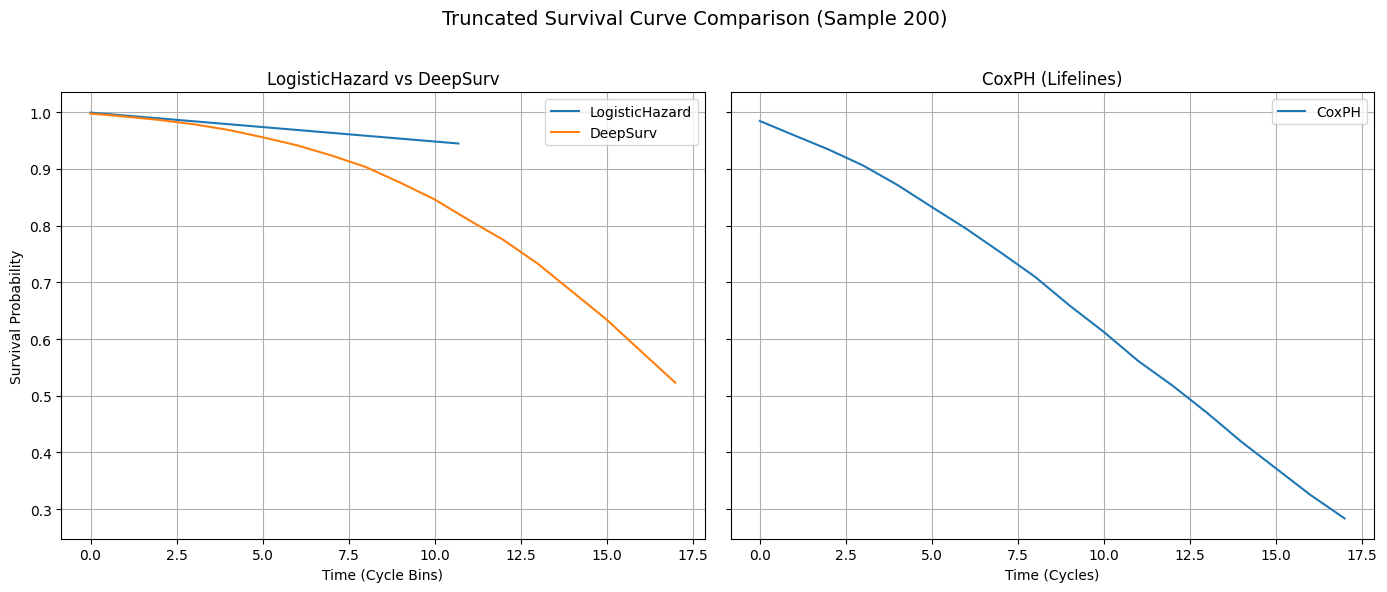

In [8]:
import matplotlib.pyplot as plt

# Set sample index
sample_idx = 200
true_failure_time = y_time_test[sample_idx]

# Truncate survival curves for the selected sample
surv_lhaz_trunc = surv_lhaz.iloc[surv_lhaz.index <= true_failure_time, sample_idx]
surv_ds_trunc = surv_ds.iloc[surv_ds.index <= true_failure_time, sample_idx]

# CoxPH approximation
baseline_surv = cox.baseline_survival_.squeeze()
partial_hazard = float(risk_scores.iloc[sample_idx])
surv_cox = baseline_surv ** partial_hazard
surv_cox_trunc = surv_cox[surv_cox.index <= true_failure_time]

# Plot side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot LogisticHazard and DeepSurv
surv_lhaz_trunc.plot(ax=ax[0], label="LogisticHazard")
surv_ds_trunc.plot(ax=ax[0], label="DeepSurv")
ax[0].set_title("LogisticHazard vs DeepSurv")
ax[0].set_xlabel("Time (Cycle Bins)")
ax[0].set_ylabel("Survival Probability")
ax[0].legend()
ax[0].grid(True)

# Plot CoxPH
surv_cox_trunc.plot(ax=ax[1], label="CoxPH")
ax[1].set_title("CoxPH (Lifelines)")
ax[1].set_xlabel("Time (Cycles)")
ax[1].legend()
ax[1].grid(True)

plt.suptitle("Truncated Survival Curve Comparison (Sample 200)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("truncated_survival_curve_comparison.png")
plt.show()


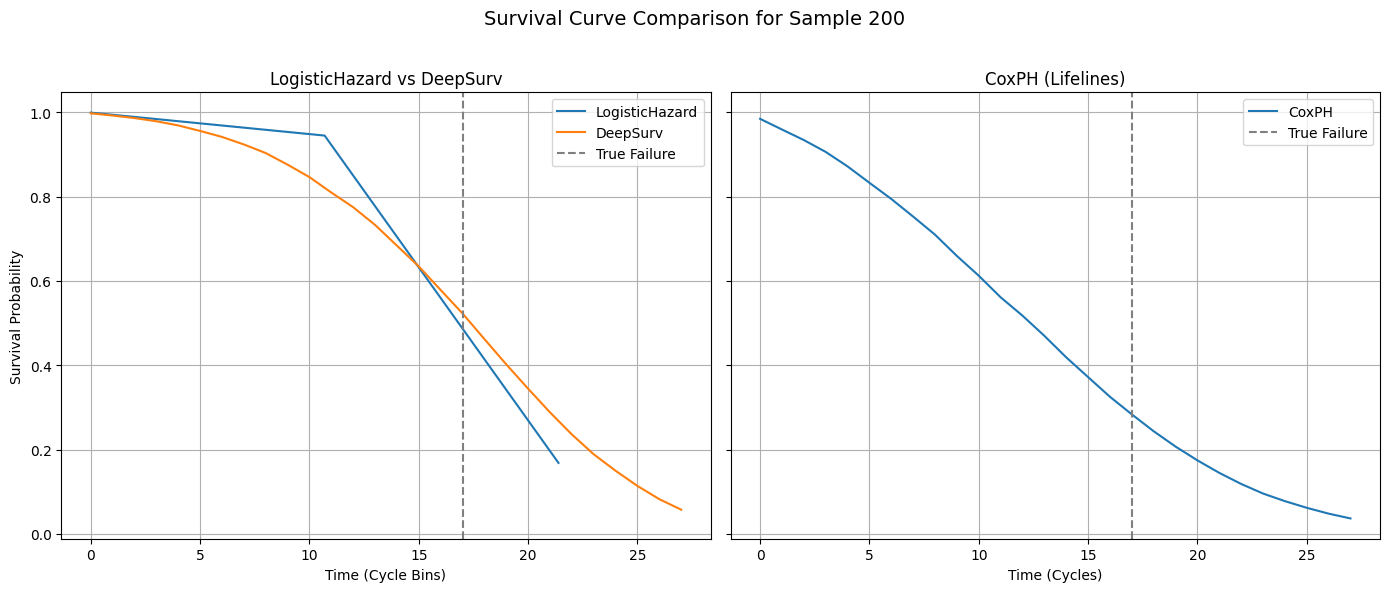

In [9]:
import matplotlib.pyplot as plt

# Sample index
sample_idx = 200
true_failure_time = y_time_test[sample_idx]
display_limit = 100  # Reasonable upper display limit
plot_until = min(true_failure_time + 10, display_limit)

# Truncate survival curves up to display limit
surv_lhaz_trunc = surv_lhaz[surv_lhaz.index <= plot_until].iloc[:, sample_idx]
surv_ds_trunc = surv_ds[surv_ds.index <= plot_until].iloc[:, sample_idx]

# CoxPH survival approximation
baseline_surv = cox.baseline_survival_.squeeze()
partial_hazard = float(risk_scores.iloc[sample_idx])
surv_cox = baseline_surv ** partial_hazard
surv_cox_trunc = surv_cox[surv_cox.index <= plot_until]

# Plot side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot LogisticHazard and DeepSurv
surv_lhaz_trunc.plot(ax=ax[0], label="LogisticHazard")
surv_ds_trunc.plot(ax=ax[0], label="DeepSurv")
ax[0].axvline(true_failure_time, color='gray', linestyle='--', label="True Failure")
ax[0].set_title("LogisticHazard vs DeepSurv")
ax[0].set_xlabel("Time (Cycle Bins)")
ax[0].set_ylabel("Survival Probability")
ax[0].legend()
ax[0].grid(False)

# Plot CoxPH
surv_cox_trunc.plot(ax=ax[1], label="CoxPH")
ax[1].axvline(true_failure_time, color='gray', linestyle='--', label="True Failure")
ax[1].set_title("CoxPH (Lifelines)")
ax[1].set_xlabel("Time (Cycles)")
ax[1].legend()
ax[1].grid(False)

plt.suptitle("Survival Curve Comparison for Sample 200", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("survival_curve_comparison_trimmed.png")
plt.show()


CoxPH (lifelines) C-index: 0.836
LogisticHazard (PyCox) C-index: 0.848
DeepSurv (PyCox) C-index: 0.849


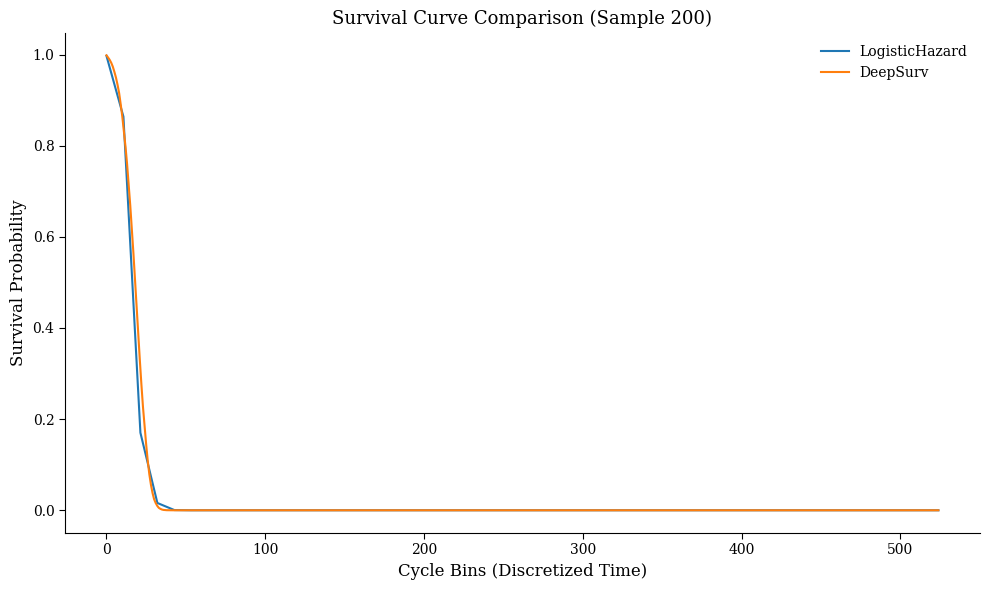

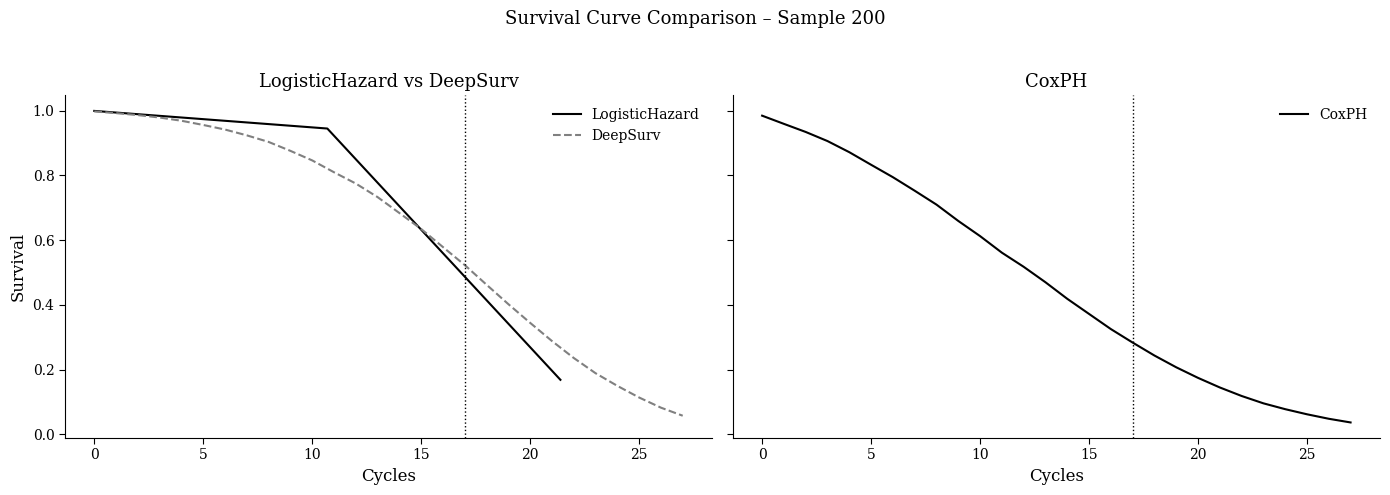

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt

# Set up Tufte-inspired minimalist style
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.frameon": False
})

import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH, LogisticHazard
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.evaluation import EvalSurv
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# --- Load and preprocess FD003 ---
cols = ['unit', 'cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
df = pd.read_csv("train_FD003.txt", sep='\s+', header=None, names=cols)
rul = df.groupby('unit')['cycle'].max().reset_index()
rul.columns = ['unit', 'max_cycle']
df = df.merge(rul, on='unit')
df['event'] = 1
df['time'] = df['max_cycle'] - df['cycle']

# --- Select sensor features ---
feature_cols = [f'sensor_{i}' for i in range(1, 22)]
X = df[feature_cols].values
durations = df['time'].values
events = df['event'].values

# --- Train-test split ---
X_train, X_test, y_time_train, y_time_test, y_event_train, y_event_test = train_test_split(
    X, durations, events, test_size=0.2, random_state=42)

# --- Standardize features ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')
X_test = scaler.transform(X_test).astype('float32')

# =====================================================================================
# CoxPH (lifelines)
# =====================================================================================
selector = VarianceThreshold(threshold=1e-4)
X_train_cox = selector.fit_transform(X_train)
X_test_cox = selector.transform(X_test)
selected_features = [f for f, keep in zip(feature_cols, selector.get_support()) if keep]

cox_train_df = pd.DataFrame(X_train_cox, columns=selected_features)
cox_train_df['time'] = y_time_train
cox_train_df['event'] = y_event_train

cox = CoxPHFitter()
cox.fit(cox_train_df, duration_col='time', event_col='event')

cox_test_df = pd.DataFrame(X_test_cox, columns=selected_features)
cox_test_df['time'] = y_time_test
cox_test_df['event'] = y_event_test
risk_scores = cox.predict_partial_hazard(cox_test_df)

c_index_cox = concordance_index(y_time_test, -risk_scores, y_event_test)
print(f"CoxPH (lifelines) C-index: {c_index_cox:.3f}")

# =====================================================================================
# LogisticHazard (PyCox)
# =====================================================================================
labtrans = LabTransDiscreteTime(50)
y_train_disc = labtrans.fit_transform(y_time_train, y_event_train)
y_test_disc = labtrans.transform(y_time_test, y_event_test)

net_lhaz = tt.practical.MLPVanilla(
    in_features=X_train.shape[1],
    num_nodes=[32, 32],
    out_features=labtrans.out_features,
    activation=nn.ReLU
)
loghaz = LogisticHazard(net_lhaz, tt.optim.Adam, duration_index=labtrans.cuts)
loghaz.fit(X_train, y_train_disc, batch_size=128, epochs=50, verbose=False)

surv_lhaz = loghaz.predict_surv_df(X_test)
ev_lhaz = EvalSurv(surv_lhaz, y_time_test, y_event_test, censor_surv='km')
c_index_lhaz = ev_lhaz.concordance_td()
print(f"LogisticHazard (PyCox) C-index: {c_index_lhaz:.3f}")

# =====================================================================================
# DeepSurv (PyCox via CoxPH with NN)
# =====================================================================================
net_deepsurv = tt.practical.MLPVanilla(
    in_features=X_train.shape[1],
    num_nodes=[32, 32],
    out_features=1,
    activation=nn.ReLU
)
deepsurv = CoxPH(net_deepsurv, tt.optim.Adam)
deepsurv.fit(X_train, (y_time_train, y_event_train), batch_size=128, epochs=50, verbose=False)
deepsurv.compute_baseline_hazards()

surv_ds = deepsurv.predict_surv_df(X_test)
ev_ds = EvalSurv(surv_ds, y_time_test, y_event_test, censor_surv='km')
c_index_ds = ev_ds.concordance_td()
print(f"DeepSurv (PyCox) C-index: {c_index_ds:.3f}")

# =====================================================================================
# Plot Survival Curve for a Sample
# =====================================================================================
sample_idx = 200
plt.figure(figsize=(10, 6))
surv_lhaz.iloc[:, sample_idx].plot(label='LogisticHazard')
surv_ds.iloc[:, sample_idx].plot(label='DeepSurv')
plt.title(f"Survival Curve Comparison (Sample {sample_idx})")
plt.xlabel("Cycle Bins (Discretized Time)")
plt.ylabel("Survival Probability")
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()





fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: LogisticHazard vs DeepSurv
surv_lhaz_trunc.plot(ax=ax[0], label="LogisticHazard", color="black", linestyle='-')
surv_ds_trunc.plot(ax=ax[0], label="DeepSurv", color="gray", linestyle='--')
ax[0].axvline(true_failure_time, color='black', linestyle=':', lw=1)
ax[0].set_title("LogisticHazard vs DeepSurv")
ax[0].set_xlabel("Cycles")
ax[0].set_ylabel("Survival")
ax[0].legend()

# Right: CoxPH
surv_cox_trunc.plot(ax=ax[1], label="CoxPH", color="black", linestyle='-')
ax[1].axvline(true_failure_time, color='black', linestyle=':', lw=1)
ax[1].set_title("CoxPH")
ax[1].set_xlabel("Cycles")
ax[1].legend()

plt.suptitle("Survival Curve Comparison – Sample 200", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("minimalist_survival_comparison.png")
plt.show()
